# pip install and imports


In [1]:
# ==========================
# Install packages
# ==========================
!pip install git+https://github.com/networkgeometry/mercator.git@master
!pip install mercator torchdiffeq sdeint scienceplots omegaconf requests


# ==========================
# Core
# ==========================
import os
import random
import warnings
import pickle
import urllib.request
import zipfile
import re
import json
import csv
import math
import requests


# ==========================
# Math / Arrays
# ==========================
import numpy as np
import pandas as pd


# ==========================
# PyTorch
# ==========================
import torch
import torch.nn as nn
import torch.nn.init as init
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import StepLR


# ==========================
# ML / Stats
# ==========================
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_score, recall_score
import sklearn.cluster as cluster


# ==========================
# Graphs
# ==========================
import networkx as nx
import mercator


# ==========================
# Differential equations
# ==========================
import torchdiffeq as ode
from sdeint import itoEuler


# ==========================
# Plotting
# ==========================
import matplotlib.pyplot as plt
import scienceplots


# ==========================
# Config
# ==========================
from omegaconf import OmegaConf


# ==========================
# Type hinting
# ==========================
from typing import Any, Dict, List, Set


# ==========================
# Suppress warnings
# ==========================
warnings.filterwarnings('ignore')


  Cloning https://github.com/networkgeometry/mercator.git (to revision master) to /tmp/pip-req-build-qgisaepa
  Running command git clone --filter=blob:none --quiet https://github.com/networkgeometry/mercator.git /tmp/pip-req-build-qgisaepa
  Resolved https://github.com/networkgeometry/mercator.git to commit 3e1368c56aa3c7a0d45bfc35bec3198302478970
  Preparing metadata (setup.py) ... done
  Using cached pybind11-3.0.1-py3-none-any.whl.metadata (10.0 kB)
Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Created wheel for mercator: filename=mercator-1.0.0-cp312-cp312-linux_x86_64.whl size=4911322 sha256=4a9e56a5388f6cc64297015c18ef0a93b76f0d549e398ccbe793808813eae15f
  Stored in directory: /tmp/pip-ephem-wheel-cache-3bopxc82/wheels/bf/e9/e0/1b926a0a79f57e36886bba43ea71f5fc1fd5d9ea142168d072
Successfully built mercator
  Preparing metadata (setup.py) ... done
  Created wheel for sdeint: filename=sdeint-0.3.0-py3-none-any.whl size=25905 sha256=9cb97bb39c551c5ba00bb4515e68d32697031955

# anomaly_detection

In [2]:
class CitationAnomalyDetector:
    def __init__(self, contamination=0.1):
        self.contamination = contamination
        self.isolation_forest = IsolationForest(
            contamination=contamination,
            random_state=42,
            n_estimators=100
        )

    def detect_anomalies(self, predicted_dynamics, actual_dynamics):
        """
        Detect anomalies by comparing predicted vs actual citation dynamics

        Args:
            predicted_dynamics: Model predictions (batch_size, horizon, node_num, feature_dim)
            actual_dynamics: Ground truth (batch_size, horizon, node_num, feature_dim)

        Returns:
            anomaly_scores: Deviation scores for each node
            anomaly_labels: Binary labels (-1 = anomaly, 1 = normal)
        """
        # Calculate deviation scores for each node
        deviation_scores = self._calculate_deviation_scores(predicted_dynamics, actual_dynamics)

        # Fit isolation forest and predict anomalies
        anomaly_labels = self.isolation_forest.fit_predict(deviation_scores.reshape(-1, 1))

        return deviation_scores, anomaly_labels

    def _calculate_deviation_scores(self, predicted, actual):
        """Calculate deviation scores between predicted and actual dynamics"""
        # Mean Absolute Error for each node across time and features
        mae_per_node = np.mean(np.abs(predicted - actual), axis=(0, 1, 3))  # Average across batch, time, features
        return mae_per_node

    def evaluate_detection(self, predicted_labels, true_labels):
        """Evaluate anomaly detection performance"""
        # Convert isolation forest labels (-1, 1) to (0, 1)
        predicted_binary = (predicted_labels == 1).astype(int)
        true_binary = true_labels.astype(int)

        precision = precision_score(true_binary, predicted_binary)
        recall = recall_score(true_binary, predicted_binary)

        return precision, recall

    def inject_synthetic_anomalies(self, graph, ratio=0.1):
        """
        Inject synthetic anomalies for testing

        Args:
            graph: NetworkX graph
            ratio: Proportion of nodes to make anomalous

        Returns:
            anomalous_nodes: List of node IDs that are anomalous
            ground_truth: Binary array (1 = anomaly, 0 = normal)
        """
        node_list = list(graph.nodes())
        n_anomalies = int(len(node_list) * ratio)

        # Randomly select nodes to be anomalous
        anomalous_nodes = np.random.choice(node_list, n_anomalies, replace=False)

        # Create ground truth labels
        ground_truth = np.zeros(len(node_list))
        for i, node in enumerate(node_list):
            if node in anomalous_nodes:
                ground_truth[i] = 1

        return anomalous_nodes, ground_truth

# citation_data

In [3]:
class CitationDataset(Dataset):

    def __init__(self, args, mode='train'):
        super().__init__()
        self.args = args
        self.mode = mode
        self.lookback = args.lookback
        self.horizon = args.horizon

        dataset_path = os.path.join(args.data_dir, 'dataset', f'{mode}_{self.lookback}_{self.horizon}.npz')
        try:
            processed_data = np.load(dataset_path)
            self.X = torch.from_numpy(processed_data['X']).float().to(self.args.device)
            self.Y = torch.from_numpy(processed_data['Y']).float().to(self.args.device)
            self.mean_y, self.std_y = processed_data['mean_y'], processed_data['std_y']
        except FileNotFoundError:
            self.process()

    def __getitem__(self, index):
        return self.X[index], self.Y[index]

    def __len__(self):
        return len(self.X)

    def process(self):
        simulation_path = os.path.join(self.args.data_dir, 'dynamics.npz')
        simulation = np.load(simulation_path)['X']

        lookback = self.args.lookback
        horizon = self.args.horizon

        # Sliding window
        idx = np.arange(0, simulation.shape[0]-lookback-horizon+1)
        X = np.stack([simulation[i:i+lookback] for i in idx], axis=0)
        Y = np.stack([simulation[i+lookback:i+lookback+horizon] for i in idx], axis=0)

        # Normalize
        self.mean_x, self.mean_y = X.mean(axis=(0, 1, 2), keepdims=True), Y.mean(axis=(0, 1, 2), keepdims=True)
        self.std_x, self.std_y = X.std(axis=(0, 1, 2), keepdims=True), Y.std(axis=(0, 1, 2), keepdims=True)
        X = (X - self.mean_x) / self.std_x
        Y = (Y - self.mean_y) / self.std_y

        # Split train, val, test
        train_ratio, val_ratio = self.args.train_ratio, self.args.val_ratio
        train_size, val_size = int(X.shape[0] * train_ratio), int(X.shape[0] * val_ratio)
        train_idx = np.random.choice(np.arange(X.shape[0]), train_size, replace=False)
        val_idx = np.random.choice(np.setdiff1d(np.arange(X.shape[0]), train_idx), val_size, replace=False)
        test_idx = np.setdiff1d(np.arange(X.shape[0]), np.concatenate([train_idx, val_idx]))
        X_train, Y_train = X[train_idx], Y[train_idx]
        X_val, Y_val = X[val_idx], Y[val_idx]
        X_test, Y_test = X[test_idx], Y[test_idx]

        # Save
        os.makedirs(os.path.join(self.args.data_dir, 'dataset'), exist_ok=True)
        np.savez(os.path.join(self.args.data_dir, 'dataset', f'train_{lookback}_{horizon}.npz'), X=X_train, Y=Y_train, mean_y=self.mean_y, std_y=self.std_y)
        np.savez(os.path.join(self.args.data_dir, 'dataset', f'val_{lookback}_{horizon}.npz'), X=X_val, Y=Y_val, mean_y=self.mean_y, std_y=self.std_y)
        np.savez(os.path.join(self.args.data_dir, 'dataset', f'test_{lookback}_{horizon}.npz'), X=X_test, Y=Y_test, mean_y=self.mean_y, std_y=self.std_y)

        # Assign tensors
        if self.mode=='train':
            self.X, self.Y = X_train, Y_train
        elif self.mode=='val':
            self.X, self.Y = X_val, Y_val
        elif self.mode=='test':
            self.X, self.Y = X_test, Y_test

        self.X = torch.from_numpy(self.X).float().to(self.args.device)
        self.Y = torch.from_numpy(self.Y).float().to(self.args.device)

    def getLoader(self):
        return DataLoader(self, batch_size=self.args.batch_size, shuffle=True, drop_last=True)


In [4]:
"""
import os
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader


class CitationDataset(Dataset):

    def __init__(self, args, mode='train'):
        super().__init__()
        self.args = args
        self.mode = mode
        self.lookback = args.lookback
        self.horizon = args.horizon

        dataset_path = os.path.join(args.data_dir, 'dataset', f'{mode}_{self.lookback}_{self.horizon}.npz')
        try:
            processed_data = np.load(dataset_path)
            self.X = torch.from_numpy(processed_data['X']).float().to(self.args.device)
            self.Y = torch.from_numpy(processed_data['Y']).float().to(self.args.device)
            self.mean_y, self.std_y = processed_data['mean_y'], processed_data['std_y']
        except FileNotFoundError:
            self.process()
            # Reload after processing to ensure tensors are on the correct device
            processed_data = np.load(dataset_path)
            self.X = torch.from_numpy(processed_data['X']).float().to(self.args.device)
            self.Y = torch.from_numpy(processed_data['Y']).float().to(self.args.device)
            self.mean_y, self.std_y = processed_data['mean_y'], processed_data['std_y']


    def __getitem__(self, index):
        return self.X[index], self.Y[index]

    def __len__(self):
        return len(self.X)

    def process(self):
        simulation_path = os.path.join(self.args.data_dir, 'dynamics.npz')
        simulation = np.load(simulation_path)['X']

        lookback = self.args.lookback
        horizon = self.args.horizon

        # Sliding window
        idx = np.arange(0, simulation.shape[0]-lookback-horizon+1)
        X = np.stack([simulation[i:i+lookback] for i in idx], axis=0)
        Y = np.stack([simulation[i+lookback:i+lookback+horizon] for i in idx], axis=0)

        # Normalize
        self.mean_x, self.mean_y = X.mean(axis=(0, 1, 2), keepdims=True), Y.mean(axis=(0, 1, 2), keepdims=True)
        self.std_x, self.std_y = X.std(axis=(0, 1, 2), keepdims=True), Y.std(axis=(0, 1, 2), keepdims=True)
        X = (X - self.mean_x) / self.std_x
        Y = (Y - self.mean_y) / self.std_y

        # Split train, val, test
        train_ratio, val_ratio = self.args.train_ratio, self.args.val_ratio
        total_samples = X.shape[0]
        train_size = int(total_samples * train_ratio)
        val_size = int(total_samples * val_ratio)
        test_size = total_samples - train_size - val_size

        # Ensure validation set has at least one sample if possible
        if total_samples > 1 and val_size == 0 and test_size < total_samples:
             if train_size > 1:
                 val_size = 1
                 train_size -= 1
             elif test_size > 1:
                 val_size = 1
                 test_size -= 1
             # Re-calculate test_size if train_size was reduced
             test_size = total_samples - train_size - val_size


        # Ensure test set has at least one sample if possible
        if total_samples > 1 and test_size == 0 and train_size < total_samples:
            if train_size > 1:
                test_size = 1
                train_size -= 1
            elif val_size > 1:
                test_size = 1
                val_size -= 1
            # Re-calculate train_size and val_size if test_size was added
            train_size = total_samples - val_size - test_size


        # Ensure train set has at least one sample if possible
        if total_samples > 1 and train_size == 0 and (val_size > 0 or test_size > 0):
            if val_size > 1:
                train_size = 1
                val_size -= 1
            elif test_size > 1:
                train_size = 1
                test_size -= 1


        # Ensure total samples are distributed
        if (train_size + val_size + test_size) != total_samples:
             # Adjust one of the sizes to make the total match, prioritize train size
             diff = total_samples - (train_size + val_size + test_size)
             if diff > 0:
                 train_size += diff
             elif diff < 0:
                 if train_size > 0: train_size += diff
                 elif val_size > 0: val_size += diff
                 elif test_size > 0: test_size += diff


        print(f"Splitting data: Total={total_samples}, Train={train_size}, Val={val_size}, Test={test_size}")

        # Check if sizes are valid before creating indices
        if train_size <= 0 and total_samples > 0:
             warnings.warn("Train size is 0, but total samples > 0. Cannot create train dataset.")
        if val_size <= 0 and total_samples > 0:
             warnings.warn("Validation size is 0, but total samples > 0. Validation dataset will be empty.")
        if test_size <= 0 and total_samples > 0:
             warnings.warn("Test size is 0, but total samples > 0. Test dataset will be empty.")


        all_indices = np.arange(total_samples)
        np.random.shuffle(all_indices)

        train_idx = all_indices[:train_size]
        val_idx = all_indices[train_size : train_size + val_size]
        test_idx = all_indices[train_size + val_size :]


        X_train, Y_train = X[train_idx], Y[train_idx]
        X_val, Y_val = X[val_idx], Y[val_idx]
        X_test, Y_test = X[test_idx], Y[test_idx]


        # Save
        os.makedirs(os.path.join(self.args.data_dir, 'dataset'), exist_ok=True)
        np.savez(os.path.join(self.args.data_dir, 'dataset', f'train_{lookback}_{horizon}.npz'), X=X_train, Y=Y_train, mean_y=self.mean_y, std_y=self.std_y)
        np.savez(os.path.join(self.args.data_dir, 'dataset', f'val_{lookback}_{horizon}.npz'), X=X_val, Y=Y_val, mean_y=self.mean_y, std_y=self.std_y)
        np.savez(os.path.join(self.args.data_dir, 'dataset', f'test_{lookback}_{horizon}.npz'), X=X_test, Y=Y_test, mean_y=self.mean_y, std_y=self.std_y)

        # Assign tensors (this part will be handled by the reload after process)
        # if self.mode=='train':
        #     self.X, self.Y = X_train, Y_train
        # elif self.mode=='val':
        #     self.X, self.Y = X_val, Y_val
        # elif self.mode=='test':
        #     self.X, self.Y = X_test, Y_test

        # self.X = torch.from_numpy(self.X).float().to(self.args.device)
        # self.Y = torch.from_numpy(self.Y).float().to(self.args.device)


    def getLoader(self):
        # Check if the dataset is empty before creating the DataLoader
        if len(self) == 0:
            warnings.warn(f"Dataset for mode '{self.mode}' is empty. Cannot create DataLoader.")
            return None # Or return an empty DataLoader if the library supports it without errors
        return DataLoader(self, batch_size=self.args.batch_size, shuffle=True, drop_last=True)
"""

'\nimport os\nimport torch\nimport numpy as np\nfrom torch.utils.data import Dataset, DataLoader\n\n\nclass CitationDataset(Dataset):\n\n    def __init__(self, args, mode=\'train\'):\n        super().__init__()\n        self.args = args\n        self.mode = mode\n        self.lookback = args.lookback\n        self.horizon = args.horizon\n\n        dataset_path = os.path.join(args.data_dir, \'dataset\', f\'{mode}_{self.lookback}_{self.horizon}.npz\')\n        try:\n            processed_data = np.load(dataset_path)\n            self.X = torch.from_numpy(processed_data[\'X\']).float().to(self.args.device)\n            self.Y = torch.from_numpy(processed_data[\'Y\']).float().to(self.args.device)\n            self.mean_y, self.std_y = processed_data[\'mean_y\'], processed_data[\'std_y\']\n        except FileNotFoundError:\n            self.process()\n            # Reload after processing to ensure tensors are on the correct device\n            processed_data = np.load(dataset_path)\n      

# dynamics

In [5]:
class FitzHughNagumo:
    def __init__(self, args, A):
        self.L = A - np.diag(np.sum(A, axis=1)) # Difussion matrix: x_j - x_i

        param = args[args.dynamics]
        self.a = param.a
        self.b = param.b
        self.c = param.c
        self.epsilon = param.epsilon
        self.k_in = np.sum(A, axis=1) # in-degree

    def f(self, x, t):

        node_num = x.shape[0] // 2
        x1, x2 = x[:node_num], x[node_num:]

        # x1
        f_x1 = x1 - (x1 ** 3)/3 - x2
        outer_x1 = self.epsilon * np.dot(self.L, 1/self.k_in) # epsilon * sum_j Aij * ((x1_j - x1_i) / k_in_i)
        dx1dt = f_x1 + outer_x1

        # x2
        f_x2 = self.a + self.b * x1 + self.c * x2
        outer_x2 = 0.0
        dx2dt = f_x2 + outer_x2

        if np.isnan(dx1dt).any():
            print('nan during simulation!')
            exit()

        dxdt = np.concatenate([dx1dt, dx2dt], axis=0)
        return dxdt

    def g(self, x, t):
        """inherent noise"""
        return np.diag([0.0] * x.shape[0])


class HindmarshRose:
    def __init__(self, args, A):
        self.A = A   # Adjacency matrix

        param = args[args.dynamics]
        self.a = param.a
        self.b = param.b
        self.c = param.c
        self.u = param.u
        self.s = param.s
        self.r = param.r
        self.epsilon = param.epsilon
        self.v = param.v
        self.lam = param.lam
        self.I = param.I
        self.omega = param.omega
        self.x0 = param.x0

    def f(self, x, t):

        node_num = x.shape[0] // 3
        x1, x2, x3 = x[:node_num], x[node_num:2*node_num], x[2*node_num:]
        mu_xj = 1 / (1 + np.exp(-self.lam * (x1 - self.omega)))

        # x1
        f_x1 = x2 - self.a * x1 ** 3 + self.b * x1 ** 2 - x3 + self.I
        outer_x1 = self.epsilon * (self.v - x1) * np.dot(self.A, mu_xj)
        dx1dt = f_x1 + outer_x1

        # x2
        f_x2 = self.c - self.u * x1 ** 2 - x2
        outer_x2 = 0.0
        dx2dt = f_x2 + outer_x2

        # x3
        f_x3 = self.r * (self.s * (x1 - self.x0) - x3)
        outer_x3 = 0.0
        dx3dt = f_x3 + outer_x3

        if np.isnan(dx1dt).any():
            print('nan during simulation!')
            exit()

        dxdt = np.concatenate([dx1dt, dx2dt, dx3dt], axis=0)
        return dxdt

    def g(self, x, t):
        """inherent noise"""
        return np.diag([0.0] * x.shape[0])


class CoupledRossler:
    def __init__(self, args, A):
        self.L = A - np.diag(np.sum(A, axis=1)) # Difussion matrix: x_j - x_i

        param = args[args.dynamics]
        self.a = param.a
        self.b = param.b
        self.c = param.c
        self.epsilon = param.epsilon
        self.delta = param.delta

    def f(self, x, t):

        node_num = x.shape[0] // 3
        x1, x2, x3 = x[:node_num], x[node_num:2*node_num], x[2*node_num:]
        omega = np.random.normal(1, self.delta, size=node_num)

        # x1
        f_x1 = - omega * x2 - x3
        outer_x1 = self.epsilon * np.dot(self.L, x1)
        dx1dt = f_x1 + outer_x1

        # x2
        f_x2 = omega * x1 + self.a * x2
        outer_x2 = 0.0
        dx2dt = f_x2 + outer_x2

        # x3
        f_x3 = self.b + x3 * (x1 + self.c)
        outer_x3 = 0.0
        dx3dt = f_x3 + outer_x3

        if np.isnan(dx1dt).any():
            print('nan during simulation!')
            exit()

        dxdt = np.concatenate([dx1dt, dx2dt, dx3dt], axis=0)
        return dxdt

    def g(self, x, t):
        """inherent noise"""
        return np.diag([0.0] * x.shape[0])

# metrics

In [6]:
def MAE(y_true, y_pred, keep_step=False, keep_node=False):
    if not keep_step and not keep_node:
        return np.mean(np.abs(y_true - y_pred))
    elif keep_step and not keep_node:
        return np.mean(np.abs(y_true - y_pred), axis=(0,2,3))
    elif not keep_step and keep_node:
        return np.mean(np.abs(y_true - y_pred), axis=(0,1,3))

def MSE(y_true, y_pred, keep_step=False, keep_node=False):
    if not keep_step and not keep_node:
        return np.mean(np.square(y_true - y_pred))
    elif keep_step and not keep_node:
        return np.mean(np.square(y_true - y_pred), axis=(0,2,3))
    elif not keep_step and keep_node:
        return np.mean(np.abs(y_true - y_pred), axis=(0,1,3))

def RMSE(y_true, y_pred, keep_step=False):
    if not keep_step:
        return np.sqrt(np.mean(np.square(y_true - y_pred)))
    else:
        return np.sqrt(np.mean(np.square(y_true - y_pred), axis=(0,2,3)))

def NMSE(y_true, y_pred, keep_step=False):
    if not keep_step:
        return np.mean(np.square(y_true - y_pred)) / (np.mean(np.square(y_true)) + 1e-7)
    else:
        return np.mean(np.square(y_true - y_pred), axis=(0,2,3)) / (np.mean(np.square(y_true), axis=(0,2,3)) + 1e-7)

# simluator

In [7]:
sites = {
    'Drosophila': 'https://nrvis.com/download/data/bn/bn-fly-drosophila_medulla_1.zip',
    'PowerGrid': 'https://nrvis.com/download/data/power/power-bcspwr10.zip',
    'Social': 'https://nrvis.com/download/data/soc/fb-pages-tvshow.zip',
    'Web': 'https://nrvis.com/download/data/web/web-EPA.zip',
    'Airport': 'https://nrvis.com/download/data/inf/inf-openflights.zip',
}


class NetworkSimulator(object):

    def __init__(self, args: dict):
        self.args = args
        self.G = None
        self.HyperbolicG = None

    def buildNetwork(self):
      # --- 1. Handle Citation network first ---
      if self.args.graph_type == 'citation':
          import os
          import pandas as pd
          import networkx as nx
          import numpy as np

          os.makedirs(self.args.data_dir, exist_ok=True)

          edge_path = f'{self.args.data_dir}/validation_edges.csv'

          if not os.path.exists(edge_path):
              raise FileNotFoundError(f"Citation network file not found: {edge_path}")

          # Load the citation graph
          try:
              df_edges = pd.read_csv(edge_path)
              if 'cited' not in df_edges.columns or 'cites' not in df_edges.columns:
                  raise ValueError("CSV does not have required 'cited' and 'cites' columns.")
          except Exception:
              # Try space-separated
              df_edges = pd.read_csv(edge_path, delimiter=' ')
              if 'cited' not in df_edges.columns or 'cites' not in df_edges.columns:
                  raise ValueError("CSV does not have required 'cited' and 'cites' columns.")

          # Create directed graph
          self.G = nx.from_pandas_edgelist(df_edges, source='cited', target='cites', create_using=nx.DiGraph())
          print(f"Loaded citation graph with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges")

          # --- POST-PROCESSING ---
          # Remove isolated nodes
          self.G.remove_nodes_from(list(nx.isolates(self.G)))
          # Remove self-loops
          self.G.remove_edges_from(nx.selfloop_edges(self.G))
          # Keep only largest weakly connected component
          self.G = self.G.subgraph(max(nx.weakly_connected_components(self.G), key=len)).copy()
          # Relabel nodes
          self.G = nx.convert_node_labels_to_integers(self.G, first_label=0)

          # Keep even number of nodes
          if self.G.number_of_nodes() % 2 == 1:
              self.G.remove_node(np.random.choice(list(self.G.nodes)))
              self.G = nx.convert_node_labels_to_integers(self.G, first_label=0)

          # Save edge list
          nx.write_edgelist(self.G, f'{self.args.data_dir}/graph.txt', data=False)
          print(f'Save citation graph with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges')

          # Return graph and adjacency matrix
          return self.G, nx.to_numpy_array(self.G)



      else:
          try:
              with open(f'{self.args.data_dir}/graph.pkl', 'rb') as file:
                  graph = pickle.load(file)
                  self.G = graph.G
                  print(f'Load {self.args.graph_type} graph with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges')

          except:
              os.makedirs(self.args.data_dir, exist_ok=True)

              # Create graph
              if self.args.graph_type == 'BA':
                  self.G = nx.barabasi_albert_graph(self.args.node_num, self.args.edge_num, seed=self.args.seed)
              elif self.args.graph_type == 'WS':
                  self.G = nx.watts_strogatz_graph(self.args.node_num, self.args.ring_lattice_k, self.args.rewiring_prob, seed=self.args.seed)
              elif self.args.graph_type == 'Drosophila':
                  self._downloadNetwork()
                  self.G = nx.read_edgelist(f'{self.args.data_dir}/bn/bn-fly-drosophila_medulla_1.edges', create_using=nx.DiGraph)
                  self.G = self.G.to_undirected()
              elif self.args.graph_type == 'PowerGrid':
                  self._downloadNetwork()
                  self.G = nx.read_edgelist(f'{self.args.data_dir}/power-bcspwr10.mtx', create_using=nx.DiGraph)
                  self.G = self.G.to_undirected()
              elif self.args.graph_type == 'Social':
                  self._downloadNetwork()
                  self.G = nx.read_edgelist(f'{self.args.data_dir}/fb-pages-tvshow.edges', create_using=nx.DiGraph)
                  self.G = self.G.to_undirected()
              elif self.args.graph_type == 'Web':
                  self._downloadNetwork()
                  self.G = nx.read_edgelist(f'{self.args.data_dir}/web-EPA.edges', create_using=nx.DiGraph)
                  self.G = self.G.to_undirected()
              elif self.args.graph_type == 'Airport':
                  self._downloadNetwork()
                  self.G = nx.read_edgelist(f'{self.args.data_dir}/inf-openflights.edges', create_using=nx.DiGraph)
                  self.G = self.G.to_undirected()
              else:
                  raise Exception(f'Invalid graph type: {self.args.graph_type}')

          # delete isolated nodes
          self.G.remove_nodes_from(list(nx.isolates(self.G)))
          # delete self-loop edges
          self.G.remove_edges_from(nx.selfloop_edges(self.G))
          # only keep the largest connected component
          self.G = self.G.subgraph(max(nx.connected_components(self.G), key=len))
          # relabel nodes
          self.G = nx.convert_node_labels_to_integers(self.G, first_label=0)
          # keep even number of nodes for static RG model
          if self.G.number_of_nodes() % 2 == 1:
              print(self.G.number_of_nodes())
              self.G.remove_node(np.random.choice(list(self.G.nodes)))
              print(self.G.number_of_nodes())
          # relabel nodes
          self.G = nx.convert_node_labels_to_integers(self.G, first_label=0)

          with open(f'{self.args.data_dir}/graph.pkl', 'wb') as file:
              pickle.dump(self, file)

          nx.write_edgelist(self.G, f'{self.args.data_dir}/graph.txt', data=False)

          print(f'Save {self.args.graph_type} graph with {self.G.number_of_nodes()} nodes and {self.G.number_of_edges()} edges')

          return self.G, nx.to_numpy_array(self.G)

    def getHyperbolicEmbedding(self):
        he = HyperbolicEmbedding(args=self.args)
        s1_kappa, s1_angular, h1_radius, mu, beta, radius_s1 = he.fit_transform()

        exp_degree, he_degree = np.mean([d for n, d in nx.degree(self.G)]), 0.1
        # while abs(exp_degree - he_degree) > 0.1:
        p_matrix = self._connectivity_probability_matrix(s1_kappa, s1_angular, mu, beta, radius_s1)
        sampled_A = np.random.binomial(1, p_matrix)
        self.HyperbolicG = nx.from_numpy_array(sampled_A)
        he_degree = np.mean([d for n, d in nx.degree(self.HyperbolicG)])
        mu = mu * (exp_degree / he_degree)

        nx.write_edgelist(self.HyperbolicG, f'{self.args.log_dir}/HE/hyperbolic_graph.txt', data=False)

        print(f'clustering coeficient: {nx.average_clustering(self.G):.3f}-->{nx.average_clustering(self.HyperbolicG):.3f}')
        print(f'degree: {np.mean([d for n, d in nx.degree(self.G)]):.3f}-->{np.mean([d for n, d in nx.degree(self.HyperbolicG)]):.3f}')

        return s1_kappa, s1_angular, h1_radius, mu, beta, radius_s1

    def getSimTraj(self):

        dynamics_path = f'{self.args.data_dir}/dynamics.npz'

        try:
            with np.load(dynamics_path) as data:
                X = data['X']
            print("Loaded existing dynamics")
            print(f'Load {self.args.dynamics} dynamics with {self.args.node_num} nodes')

        except FileNotFoundError:
            print("No dynamics found. Generating dynamics from processed graph...")

            if not hasattr(self, 'G'):
                raise RuntimeError("Graph not found. Please run buildNetwork first.")

            meta_csv = f'{self.args.data_dir}/updated_clean_meta.csv'
            idmap_json = f'{self.args.data_dir}/updated_id2idx_clean.json'
            out_dir = self.args.data_dir

            try:
                build_dynamics_from_graph(self.G, meta_csv, idmap_json, out_dir)
            except RuntimeError as e:
                raise RuntimeError(
                    f"Failed to generate dynamics: {e}\n"
                    "Check your metadata CSV for valid 'year' column."
                )

            # reload newly created dynamics
            with np.load(dynamics_path) as data:
                X = data['X']
        """ orignal disknet except
        except:
            dim = self.args[self.args.dynamics].dim

            if self.args.dynamics == 'HindmarshRose':
                sde = HindmarshRose(args=self.args, A=nx.to_numpy_array(self.G))
                x0_1 = np.random.uniform(-1, 0, size=self.args.node_num)
                x0_2 = np.random.uniform(-5, 0, size=self.args.node_num)
                x0_3 = np.random.uniform(3, 3.5, size=self.args.node_num)
                x0 = np.concatenate((x0_1, x0_2, x0_3))
            elif self.args.dynamics == 'FitzHughNagumo':
                sde = FitzHughNagumo(args=self.args, A=nx.to_numpy_array(self.G))
                x0 = np.random.uniform(-1, 1, size=self.args.node_num*dim)
            elif self.args.dynamics == 'CoupledRossler':
                sde = CoupledRossler(args=self.args, A=nx.to_numpy_array(self.G))
                x0 = np.random.uniform(-0.05, 0.05, size=self.args.node_num*dim)

            tspan = np.arange(0, self.args[self.args.dynamics].total_t, self.args[self.args.dynamics].sim_dt)
            sol = itoEuler(sde.f, sde.g, x0, tspan) # (total_t, node_num*feature_dim)

            # downsample
            ratio = int(self.args[self.args.dynamics].dt / self.args[self.args.dynamics].sim_dt)
            sol = sol[::ratio]

            X = np.zeros((sol.shape[0], self.args.node_num, dim))
            for i in range(dim):
                X[:, :, i] = sol[:, i*self.args.node_num:(i+1)*self.args.node_num]

            if self.args.dynamics == 'CoupledKuramoto':
                X = np.sin(X)

            os.makedirs(f'{self.args.data_dir}/{self.args.dynamics}', exist_ok=True)
            np.savez(f'{self.args.data_dir}/{self.args.dynamics}/dynamics.npz', X=X)
            print(f'Save {self.args.dynamics} dynamics with {self.args.node_num} nodes and {self.args[self.args.dynamics].total_t} time steps')
        """
        return X

    def _downloadNetwork(self):
        url = sites[self.args.graph_type]
        file_name = f"{self.args.data_dir}/download.zip"
        urllib.request.urlretrieve(url, file_name)

        with zipfile.ZipFile(file_name, "r") as zip_ref:
            zip_ref.extractall(self.args.data_dir)

        os.remove(file_name)

        if self.args.graph_type == 'PowerGrid':
            # delete header
            with open(f'{self.args.data_dir}/power-bcspwr10.mtx', 'r') as f:
                lines = f.readlines()
            with open(f'{self.args.data_dir}/power-bcspwr10.mtx', 'w') as f:
                f.writelines(lines[14:])
        elif self.args.graph_type == 'Social':
            # replace ',' with ' '
            with open(f'{self.args.data_dir}/fb-pages-tvshow.edges', 'r') as f:
                lines = f.readlines()
            with open(f'{self.args.data_dir}/fb-pages-tvshow.edges', 'w') as f:
                for line in lines:
                    f.write(line.replace(',', ' '))
        elif self.args.graph_type == 'Airport':
            # delete header
            with open(f'{self.args.data_dir}/inf-openflights.edges', 'r') as f:
                lines = f.readlines()
            with open(f'{self.args.data_dir}/inf-openflights.edges', 'w') as f:
                f.writelines(lines[2:])

    def _connectivity_probability_matrix(self, kappa, angular, mu, beta, radius):
        """p_ij = 1 / (1 + (radius*(delta_angular) / (mu*kappa_i*kappa_j))**beta)"""

        abs_delta_angular = np.abs(angular.reshape(-1, 1) - angular.reshape(1, -1))
        delta_angular = np.minimum(abs_delta_angular, 2 * np.pi - abs_delta_angular)
        kappa_mul = kappa.reshape(-1, 1) * kappa.reshape(1, -1)
        rescaled_dist = radius * delta_angular / (mu * kappa_mul)
        p_matrix = 1 / (1 + rescaled_dist ** beta) - np.eye(self.args.node_num)

        return p_matrix


# utils

In [8]:
plt.style.use(['ieee', 'science', 'no-latex'])
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams["font.family"] = 'DejaVu Sans'


def set_cpu_num(cpu_num: int = 1):
    if cpu_num <= 0: return

    os.environ ['OMP_NUM_THREADS'] = str(cpu_num)
    os.environ ['OPENBLAS_NUM_THREADS'] = str(cpu_num)
    os.environ ['MKL_NUM_THREADS'] = str(cpu_num)
    os.environ ['VECLIB_MAXIMUM_THREADS'] = str(cpu_num)
    os.environ ['NUMEXPR_NUM_THREADS'] = str(cpu_num)
    torch.set_num_threads(cpu_num)


def seed_everything(seed: int = 42):
    # Set the random seed for Python's built-in random module
    random.seed(seed)

    # Set the random seed for NumPy
    np.random.seed(seed)

    # Set the random seed for torch operations
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def print_model_summary(model):
    print(model)
    print("Number of parameters: {:,}".format(count_parameters(model)))

    print("\nParameter details:")
    for name, parameter in model.named_parameters():
        if parameter.requires_grad:
            print(name, parameter.shape, parameter.device, parameter.dtype, parameter.numel())


class HyperbolicEmbedding:
    def __init__(self, args: dict):
        self.args = args

    def fit_transform(self):
        # Assuming mercator.embed is the correct function based on original repo usage
        if not os.path.exists(f'{self.args.log_dir}/HE/he.inf_coord'):
            os.makedirs(f'{self.args.log_dir}/HE', exist_ok=True)
            mercator.embed(
                edgelist_filename=f'{self.args.data_dir}/graph.txt',
                quiet_mode=self.args.quiet_mode,
                fast_mode=self.args.fast_mode,
                output_name=f'{self.args.log_dir}/HE/he',
                validation_mode=self.args.validation_mode,
                post_kappa=self.args.post_kappa,
                beta = 0.5
            )

        if self.args.refine:
             mercator.embed(
                edgelist_filename=f'{self.args.data_dir}/graph.txt',
                quiet_mode=self.args.quiet_mode,
                fast_mode=self.args.fast_mode,
                output_name=f'{self.args.log_dir}/HE/he',
                validation_mode=self.args.validation_mode,
                post_kappa=self.args.post_kappa,
                inf_coord=f'{self.args.log_dir}/HE/he.inf_coord',
                beta = 0.5

            )

        return self._parse_mercator_output()

    def _parse_mercator_output(self):
        with open(f'{self.args.log_dir}/HE/he.inf_coord', 'r') as f:
            lines = f.readlines()

        # parse node_num, dim, coords
        node_num = int(lines[7].split()[-1])
        beta = float(lines[8].split()[-1])
        mu = float(lines[9].split()[-1])
        radius_s1 = float(lines[10].split()[-1])
        radius_h2 = float(lines[11].split()[-1])

        s1_kappa = np.zeros(node_num)
        s1_angular = np.zeros(node_num)
        h2_radius = np.zeros(node_num)
        for i in range(15, 15+node_num):
            s1_kappa[i-15] = float(lines[i].split()[1])
            s1_angular[i-15] = float(lines[i].split()[2])
            h2_radius[i-15] = float(lines[i].split()[3])

        return s1_kappa, s1_angular, h2_radius, mu, beta, radius_s1


def drawGraph(G: nx.Graph, layout: str = 'random', filter: str = 'none', threshold = 0.3, out_path: str = 'graph.png'):
    """
    param G: networkX graph
    param layout: layout type, options: random, circular, spring, spectral, shell, kamada_kawai (default: random)
    param filter: disparity filter, options: none, degree, betweenness, random (default: none)
    param threshold: disparity filter threshold (default: 0.3)
    """

    # disparity filter
    if filter == 'degree':
        degree_centrality = nx.degree_centrality(G)
        core_nodes = [node for node, centrality in degree_centrality.items() if centrality >= threshold]
        G = G.subgraph(core_nodes)
    elif filter == 'betweenness':
        betweenness_centrality = nx.betweenness_centrality(G)
        core_nodes = [node for node, centrality in betweenness_centrality.items() if centrality >= threshold]
        G = G.subgraph(core_nodes)
    elif filter == 'random':
        core_nodes = [node for node in G.nodes() if np.random.rand() >= threshold]
        G = G.subgraph(core_nodes)
    else:
        pass

    # layout
    if layout == 'random':
        pos = nx.random_layout(G)
    elif layout == 'circular':
        pos = nx.circular_layout(G)
    elif layout == 'spring':
        pos = nx.spring_layout(G)
    elif layout == 'spectral':
        pos = nx.spectral_layout(G)
    elif layout == 'shell':
        pos = nx.shell_layout(G)
    elif layout == 'kamada_kawai':
        pos = nx.kamada_kawai_layout(G)
    else:
        pos = nx.random_layout(G)

    # node color and size
    node_color = [G.degree(v) for v in G]
    node_size = [v * 10 for v in node_color]

    plt.figure(figsize=(8, 8))
    nx.draw(G, pos, with_labels=False, node_color=node_color, node_size=node_size, edge_color=(0, 0, 0, 0.25))
    plt.savefig(out_path, dpi=300)


def drawTraj(X1, X2, title1, title2, yticks1=None, yticks2=None, dim=0, out_path='traj.png', num=2):
    # X1, X2: (Batch, Node Num, Horizon)
    if isinstance(X1, torch.Tensor):
        data1 = X1[0,:,:,dim].detach().cpu().numpy().T
        data2 = X2[0,:,:,dim].detach().cpu().numpy().T
    else:
        data1 = X1[0,:,:,dim].T
        data2 = X2[0,:,:,dim].T
    if yticks1 is not None:
        yticks1 = yticks1.detach().cpu().numpy()[:,0]
        yticks2 = yticks2.detach().cpu().numpy()[:,0]

    zmax = max(np.max(data1), np.max(data2))
    zmin = min(np.min(data1), np.min(data2))

    # Heatmap
    plt.figure(figsize=(num*4, 4))
    plt.subplot(1, num, 1)
    plt.imshow(data1, cmap='hot', interpolation='nearest', vmin=zmin, vmax=zmax)
    plt.ylabel('Node')
    plt.xlabel('Time Step')
    if yticks1 is not None:
        plt.yticks(np.arange(0, len(yticks1), 1), yticks1)
    plt.title(title1)
    plt.subplot(1, num, 2)
    plt.imshow(data2, cmap='hot', interpolation='nearest', vmin=zmin, vmax=zmax)
    plt.ylabel('Node')
    plt.xlabel('Time Step')
    if yticks1 is not None:
        plt.yticks(np.arange(0, len(yticks2), 1), yticks2)
    plt.title(title2)
    if num == 3:
        plt.subplot(1, num, 3)
        plt.imshow(np.abs(data2-data1), cmap='hot', interpolation='nearest', vmin=zmin, vmax=zmax)
        plt.ylabel('Node')
        plt.xlabel('Time Step')
        if yticks1 is not None:
            plt.yticks(np.arange(0, len(yticks2), 1), yticks2)
        plt.title('MAE')
    # plt.colorbar()
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path)
    plt.close()


def draw_embedding(adj, embedding, out_path, label=None, mask=None):
    """
    Draw the embedding.
    """
    if os.path.exists(out_path):
        return

    embedding = embedding.cpu().detach().numpy()
    size = adj.diagonal().cpu().detach().numpy() + 1

    plt.figure(figsize=(4, 4))

    # edge
    tmp = adj >= 1
    idx = np.where(tmp.cpu().detach().numpy())
    for i in range(len(idx[0])):
        plt.plot([embedding[idx[0][i], 0], embedding[idx[1][i], 0]], [embedding[idx[0][i], 1], embedding[idx[1][i], 1]], color="#555555", alpha=0.03, linewidth=0.5)

    # node
    if label is None:
        plt.scatter(embedding[:, 0], embedding[:, 1], s=8, alpha=1.0)
    else:
        if mask is None:
            mask = np.ones_like(label, dtype=bool)
        else:
            mask = mask.cpu().detach().numpy()

        for i in np.unique(label):
            mask_ = (label == i) & mask
            plt.scatter(embedding[mask_, 0], embedding[mask_, 1], s=size[mask_]*1.2, alpha=1.0, label=f'Supernode {i}')

    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.xticks([])
    plt.yticks([])
    # plt.legend(loc='upper right', fontsize=8, frameon=False)
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=300)
    plt.close()


def StatisticGraph():

    import pickle
    import networkx as nx
    for graph_type in ['PowerGrid', 'Drosophila', 'Social', 'Web', 'Airport', 'BA_n5000_612', 'WS_n5000_612']:
        with open(f'data/{graph_type}/graph.pkl', 'rb') as file:
            graph = pickle.load(file).G # nx.Graph

        node_num = graph.number_of_nodes()
        edge_num = graph.number_of_edges()
        avg_degree = sum(dict(graph.degree()).values()) / node_num
        avg_clustering = nx.average_clustering(graph)
        density = nx.density(graph)
        print(f'{graph_type.rjust(12)}: Node Num={node_num}, Edge Num={edge_num}, Avg Degree={avg_degree:.4f}, Avg Clustering={avg_clustering:.4f}, Density={density:.4f}')


# if __name__ == '__main__':
#     StatisticGraph()

#Add files from git

In [9]:
# Create necessary directories
os.makedirs("data", exist_ok=True)
os.makedirs("data/citation", exist_ok=True)

# Base URL for raw files from your GitHub repository
base_url = "https://raw.githubusercontent.com/IdoSakal/SkAD-CN/main/phase%20b/dataset/"

# Dictionary mapping files to their destination paths
files_to_download = {
    "config.yaml": "config.yaml",
    "citation_edges.csv": "data/citation_edges.csv",
    "papers_metadata.csv": "data/papers_metadata.csv",
    "Topics and conceptes.JSON": "data/Topics and conceptes.JSON",
}

# Download each file
for filename, local_path in files_to_download.items():
    try:
        url = base_url + filename
        print(f"Downloading {filename}...")

        response = requests.get(url)
        response.raise_for_status()  # Raises an exception for bad status codes

        # Write the file to the local path
        with open(local_path, 'wb') as f:
            f.write(response.content)

        print(f"✓ Successfully downloaded {filename} to {local_path}")

    except requests.exceptions.RequestException as e:
        print(f"✗ Error downloading {filename}: {e}")
    except Exception as e:
        print(f"✗ Unexpected error with {filename}: {e}")

print("\nDownload process completed!")

✓ Successfully downloaded config.yaml to config.yaml
✓ Successfully downloaded citation_edges.csv to data/citation_edges.csv
✓ Successfully downloaded papers_metadata.csv to data/papers_metadata.csv
✓ Successfully downloaded Topics and conceptes.JSON to data/Topics and conceptes.JSON

Download process completed!


#cleanCitationRaw

In [10]:
# ----------------- config -----------------
edges_csv = "data/citation_edges.csv"
meta_csv  = "data/papers_metadata.csv"
out_dir   = "data/citation"
os.makedirs(out_dir, exist_ok=True)
clean_edges_path = os.path.join(out_dir, "clean_edges.csv")
clean_meta_path  = os.path.join(out_dir, "clean_meta.csv")
# ------------------------------------------

def detect_sep_and_read(path):
    """Detect separator and read CSV robustly, drop all-empty cols and Unnamed.*."""
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        sample = f.read(4096)
    # guess separator
    if sample.count(';') > sample.count(',') and sample.count(';') > sample.count('\t'):
        sep = ';'
    elif sample.count('\t') > sample.count(','):
        sep = '\t'
    else:
        sep = ','
    # Use 'on_bad_lines='skip' to skip malformed rows and specify quotechar
    df = pd.read_csv(path, sep=sep, dtype=str, keep_default_na=False, na_values=[''], on_bad_lines='skip', quotechar='"', engine='python')
    # strip column names
    df.columns = [str(c).strip() for c in df.columns]
    # drop columns that are completely empty or Unnamed...
    def col_all_empty(col):
        vals = col.astype(str).map(lambda x: x.strip())
        return vals.replace('', pd.NA).isna().all()
    drop_cols = [c for c in df.columns if (c.lower().startswith('unnamed') or col_all_empty(df[c]))]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    # trim whitespace in string cells
    df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
    return df

def find_column(df, candidates):
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    # try contains
    for cand in candidates:
        for k in cols:
            if cand.lower() in k:
                return cols[k]
    return None

def parse_concepts(s):
    if s is None or (isinstance(s, float) and np.isnan(s)):
        return set()
    parts = re.split(r'[;,|/]', str(s))
    cleaned = {p.strip().lower() for p in parts if p is not None and str(p).strip() != ''}
    return cleaned

print("Reading raw edges from:", edges_csv)
edges_df = detect_sep_and_read(edges_csv)
print("edges cols:", edges_df.columns.tolist())

print("Reading raw meta from:", meta_csv)
meta_df = detect_sep_and_read(meta_csv)
print("meta cols:", meta_df.columns.tolist())

# detect source/target columns in edges
edge_src_col = find_column(edges_df, ['cited', 'source', 'from', 'paper_cited'])
edge_dst_col = find_column(edges_df, ['cites', 'target', 'to', 'paper_citing'])
if edge_src_col is None or edge_dst_col is None:
    raise RuntimeError(f"Could not find source/target columns in edges CSV. cols: {edges_df.columns.tolist()}")

# detect id/year/concepts/topic columns in meta
meta_id_col = find_column(meta_df, ['id', 'paper_id', 'paper', 'pid'])
meta_year_col = find_column(meta_df, ['year', 'pubyear', 'publication_year', 'date'])
meta_concepts_col = find_column(meta_df, ['concepts', 'keywords', 'topics', 'tags'])
meta_topic_col = find_column(meta_df, ['primary_topic', 'topic', 'primarytopic', 'main_topic'])

if meta_id_col is None:
    raise RuntimeError(f"Could not find id column in meta CSV. cols: {meta_df.columns.tolist()}")

# Normalize ids to strings trimmed
edges_df[edge_src_col] = edges_df[edge_src_col].astype(str).map(lambda x: x.strip())
edges_df[edge_dst_col] = edges_df[edge_dst_col].astype(str).map(lambda x: x.strip())
meta_df[meta_id_col] = meta_df[meta_id_col].astype(str).map(lambda x: x.strip())

# 1) Remove self-citations
before = len(edges_df)
edges_df = edges_df[edges_df[edge_src_col] != edges_df[edge_dst_col]].copy()
after = len(edges_df)
print(f"Removed self-citations: {before - after} rows dropped")

# 2) Remove exact duplicate edge rows (same src,dst[,maybe year,...]) -> keep first
# keep only src,dst and any other columns for informational purposes
# But remove duplicates based on src,dst (ignore other columns)
edges_df = edges_df.drop_duplicates(subset=[edge_src_col, edge_dst_col])
print("After dropping duplicate edges (by src,dst):", len(edges_df))

# 3) Build set of ids that appear in edges (either as src or dst)
edge_ids = set(edges_df[edge_src_col].dropna().unique()) | set(edges_df[edge_dst_col].dropna().unique())
print("Unique ids appearing in edges:", len(edge_ids))

# 4) Clean/merge meta: if several rows for same id, aggregate primary_topic into a list (unique)
#    and keep other columns from first occurrence (title, year, concepts merged)
# First, ensure meta has required columns; if not, create empty
if meta_year_col is None:
    meta_df['__year__tmp__'] = ''
    meta_year_col = '__year__tmp__'
if meta_concepts_col is None:
    meta_df['__concepts__tmp__'] = ''
    meta_concepts_col = '__concepts__tmp__'
if meta_topic_col is None:
    meta_df['__topic__tmp__'] = ''
    meta_topic_col = '__topic__tmp__'

# group by id and aggregate
grouped = {}
for _, row in meta_df.iterrows():
    mid = str(row[meta_id_col]).strip()
    if mid == '' or mid.lower() in ['nan','none','na']:
        continue
    if mid not in grouped:
        grouped[mid] = {
            'rows': [],
            'primary_topics': [],
            'concepts_sets': [],
            'year_vals': []
        }
    grouped[mid]['rows'].append(row)
    tp = row.get(meta_topic_col, None)
    if isinstance(tp, str) and tp.strip() != '':
        grouped[mid]['primary_topics'].append(tp.strip())
    # parse concepts
    cs = parse_concepts(row.get(meta_concepts_col, ''))
    if cs:
        grouped[mid]['concepts_sets'].append(cs)
    # year
    yraw = row.get(meta_year_col, '')
    try:
        y = int(float(str(yraw))) if str(yraw).strip() != '' else None
    except Exception:
        y = None
    if y is not None:
        grouped[mid]['year_vals'].append(y)

# build consolidated meta rows
clean_meta_rows = []
for mid, info in grouped.items():
    # primary topics: unique list preserving order
    pts = []
    for p in info['primary_topics']:
        if p not in pts:
            pts.append(p)
    # combine concepts: union of all
    combined_concepts = set()
    for s in info['concepts_sets']:
        combined_concepts |= s
    # choose year: prefer min year found (earliest pub) if exists, else ''
    year_val = ''
    if len(info['year_vals']) > 0:
        year_val = int(min(info['year_vals']))
    # other fields: take from first row (but ensure string types)
    first = info['rows'][0]
    # build cleaned row as dict
    rowdict = {}
    rowdict['id'] = mid
    # try to keep title if exists
    if 'title' in first.index:
        rowdict['title'] = first['title']
    else:
        rowdict['title'] = ''
    rowdict['year'] = year_val if year_val != '' else ''
    # concepts: join sorted
    rowdict['concepts'] = ';'.join(sorted(list(combined_concepts))) if combined_concepts else ''
    # primary_topic(s): join by '|' to indicate multiple primary topics
    rowdict['primary_topic'] = '|'.join(pts) if pts else ''
    clean_meta_rows.append(rowdict)

clean_meta_df = pd.DataFrame(clean_meta_rows, columns=['id','title','year','concepts','primary_topic'])
print("Consolidated meta rows:", len(clean_meta_df))

# 5) Remove articles that never appear in edges (no in and no out) according to the raw edges file
# keep only meta rows whose id in edge_ids
meta_before = len(clean_meta_df)
clean_meta_df = clean_meta_df[clean_meta_df['id'].isin(edge_ids)].reset_index(drop=True)
meta_after = len(clean_meta_df)
print(f"Removed isolated articles (no in/out in edges): {meta_before - meta_after} rows dropped")

# 6) After removing isolated meta items, also filter edges (if any refs point to removed ids)
valid_ids = set(clean_meta_df['id'].astype(str).tolist())
edges_before = len(edges_df)
edges_df = edges_df[edges_df[edge_src_col].isin(valid_ids) & edges_df[edge_dst_col].isin(valid_ids)].copy()
edges_after = len(edges_df)
print(f"Filtered edges to valid meta ids: {edges_before - edges_after} rows dropped")

# 7) Final housekeeping: ensure no self-loops (again) and drop duplicate edges
edges_df = edges_df[edges_df[edge_src_col] != edges_df[edge_dst_col]]
edges_df = edges_df.drop_duplicates(subset=[edge_src_col, edge_dst_col]).reset_index(drop=True)
print("Final edges count:", len(edges_df))

# 8) Save cleaned files
edges_df.to_csv(clean_edges_path, index=False)
clean_meta_df.to_csv(clean_meta_path, index=False)
print("Saved cleaned edges to:", clean_edges_path)
print("Saved cleaned meta to: ", clean_meta_path)

# 9) Save id2idx mapping for downstream scripts (sorted)
all_ids = sorted(clean_meta_df['id'].astype(str).tolist())
id2idx = {idv: i for i, idv in enumerate(all_ids)}
with open(os.path.join(out_dir, "id2idx_clean.json"), "w", encoding="utf-8") as f:
    json.dump(id2idx, f, ensure_ascii=False, indent=2)
print("Saved id2idx_clean.json (N={} )".format(len(all_ids)))

Reading raw edges from: data/citation_edges.csv
edges cols: ['cited', 'cites']
Reading raw meta from: data/papers_metadata.csv
meta cols: ['id', 'title', 'year', 'concepts', 'referenced_works', 'primary_topic']
Removed self-citations: 224 rows dropped
After dropping duplicate edges (by src,dst): 24814
Unique ids appearing in edges: 6503
Consolidated meta rows: 7216
Removed isolated articles (no in/out in edges): 713 rows dropped
Filtered edges to valid meta ids: 0 rows dropped
Final edges count: 24814
Saved cleaned edges to: data/citation/clean_edges.csv
Saved cleaned meta to:  data/citation/clean_meta.csv
Saved id2idx_clean.json (N=6503 )


#updated cleanCitation

In [11]:
def build_updated_clean_files(data_dir):
    """
    Create updated_clean_edges.csv, updated_clean_meta.csv, and updated_id2idx_clean.json
    based ONLY on:
        - graph.txt (final pruned graph)
        - id2idx_clean.json (mapping original_id -> index)
        - clean_meta.csv

    clean_edges.csv is NOT used.
    """
    graph_path = f"{data_dir}/graph.txt"
    # NOTE: Assuming the original prompt intended to use the *clean* id2idx file,
    # but the path given was 'validation_id2idx.json'. We'll stick to the path
    # provided in the original function for consistency.
    idmap_path = f"{data_dir}/validation_id2idx.json"
    clean_meta_path = f"{data_dir}/validation_nodes.csv"

    # --- Load graph ---
    G = nx.read_edgelist(graph_path, nodetype=int, create_using=nx.DiGraph())
    print(f"[GRAPH] Loaded pruned graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    # --- Load id2idx mapping ---
    with open(idmap_path, "r", encoding="utf-8") as f:
        id2idx = json.load(f)

    # reverse mapping: idx -> original ID
    # NOTE: Graph nodes are ints, so keys in idx2id are ints.
    idx2id = {int(v): str(k) for k, v in id2idx.items()}

    # --- Build updated edges FROM GRAPH ONLY ---
    rows = []
    for u, v in G.edges():
        if u in idx2id and v in idx2id:
            src = idx2id[u]
            dst = idx2id[v]
            rows.append((src, dst))

    updated_edges_df = pd.DataFrame(rows, columns=["cited", "cites"])
    updated_edges_path = f"{data_dir}/updated_clean_edges.csv"
    updated_edges_df.to_csv(updated_edges_path, index=False)
    print(f"[EDGES] Saved updated edges: {len(updated_edges_df)} rows → {updated_edges_path}")

    # --- Now update metadata ---
    meta_df = pd.read_csv(clean_meta_path, dtype=str)

    # keep only IDs that appear in the final graph
    # G.nodes() returns the indices (ints) used in the graph.
    remaining_ids = {idx2id[i] for i in G.nodes() if i in idx2id}
    updated_meta_df = meta_df[meta_df["id"].isin(remaining_ids)].reset_index(drop=True)

    updated_meta_path = f"{data_dir}/updated_clean_meta.csv"
    updated_meta_df.to_csv(updated_meta_path, index=False)
    print(f"[META] Saved updated metadata: {len(updated_meta_df)} rows → {updated_meta_path}")


    ## 📝 Create Updated ID to Index Mapping
    # Get all the 'id' values from the newly created updated_meta_df
    final_ids = updated_meta_df["id"].tolist()

    # Create the new id2idx mapping. The indices will be 0, 1, 2, ...
    # based on the order they appear in the updated metadata file.
    updated_id2idx = {doc_id: idx for idx, doc_id in enumerate(final_ids)}

    # Save the new mapping to a JSON file
    updated_id2idx_path = f"{data_dir}/updated_id2idx_clean.json"
    with open(updated_id2idx_path, "w", encoding="utf-8") as f:
        # Use indent=4 for a more readable JSON file
        json.dump(updated_id2idx, f, indent=4)

    print(f"[IDMAP] Saved updated ID map: {len(updated_id2idx)} entries → {updated_id2idx_path}")


    print("\n✔ DONE: updated_clean_edges.csv, updated_clean_meta.csv, and updated_id2idx_clean.json created.")

#buildFeaturesFromCitationCsv


In [12]:
""" old feature build
import os
import re
import json
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ----------------- config -----------------
edges_csv = "data/citation/clean_edges.csv"
meta_csv  = "data/citation/clean_meta.csv"
out_dir   = "data/citation"
os.makedirs(out_dir, exist_ok=True)
# ------------------------------------------

# helper to parse concepts string into a set of normalized tokens
def parse_concepts(s):
    if pd.isna(s):
        return set()
    parts = re.split(r'[;,|/]', str(s))
    cleaned = {p.strip().lower() for p in parts if p is not None and str(p).strip() != ''}
    return cleaned

# load cleaned CSVs
edges_df = pd.read_csv(edges_csv, dtype=str)
meta_df  = pd.read_csv(meta_csv, dtype=str)

edges_df.columns = [c.strip() for c in edges_df.columns]
meta_df.columns  = [c.strip() for c in meta_df.columns]

print("edges cols:", edges_df.columns.tolist())
print("meta cols:", meta_df.columns.tolist())

# build id set (all ids in metadata plus any ids appearing in edges)
meta_ids = set(meta_df['id'].unique())
edge_ids = set(edges_df['cited'].tolist()) | set(edges_df['cites'].tolist())
all_ids = sorted(list(meta_ids | edge_ids))
id2idx = {idv: i for i, idv in enumerate(all_ids)}
N = len(all_ids)
print("N nodes:", N)

# map meta_df to id index, and preprocess meta columns: year, primary_topic, concepts_set
meta_df_indexed = meta_df.set_index('id')
years = np.full(N, -1, dtype=int)
primary_topics = [None] * N
concepts_sets = [set() for _ in range(N)]
for idv, idx in id2idx.items():
    if idv in meta_df_indexed.index:
        row = meta_df_indexed.loc[idv]
        # year
        try:
            y = int(row['year'])
        except Exception:
            y = -1
        years[idx] = y
        # primary topic
        primary_topics[idx] = str(row['primary_topic']).strip() if 'primary_topic' in meta_df_indexed.columns else None
        # concepts parse
        concepts_sets[idx] = parse_concepts(row['concepts']) if 'concepts' in meta_df_indexed.columns else set()
    else:
        years[idx] = -1
        primary_topics[idx] = None
        concepts_sets[idx] = set()

# convert edges to indices and attach citing-year (we use 'cites' year as the year the citation occurred)
edges = []
for _, r in edges_df.iterrows():
    a = r['cited']
    b = r['cites']
    if a not in id2idx or b not in id2idx:
        continue
    ia, ib = id2idx[a], id2idx[b]
    # year of citation = publication year of citing paper (ib)
    year_b = years[ib]
    edges.append((ia, ib, year_b))
edges = [e for e in edges if e[2] != -1]  # keep only edges with known citing year
print("edges with year count:", len(edges))

# determine time steps
valid_years = sorted({y for y in years if y >= 0})
if len(valid_years) == 0:
    raise RuntimeError("No valid publication years found in metadata.")
min_year, max_year = valid_years[0], valid_years[-1]
time_steps = list(range(min_year, max_year + 1))
T = len(time_steps)
print("years:", min_year, "->", max_year, "T=", T)

# group edges by citation year (edges_by_year[y] = list of (src_idx,dst_idx))
edges_by_year = {y: [] for y in time_steps}
for ia, ib, yr in edges:
    if yr >= min_year and yr <= max_year:
        edges_by_year[yr].append((ia, ib))

# prepare X: dims = 4 as specified
dim = 4
X = np.zeros((T, N, dim), dtype=np.float32)

# cumulative citation counts up to previous year
cumulative_in = np.zeros(N, dtype=np.int32)

# For each year compute per-year in-degree, cumulative, and fractions for topic stats
for ti, yr in enumerate(time_steps):
    # edges that occurred exactly this year
    edges_this_year = edges_by_year.get(yr, [])
    in_deg_this = np.zeros(N, dtype=np.int32)
    citing_lists = [[] for _ in range(N)]
    for src, dst in edges_this_year:
        in_deg_this[dst] += 1
        citing_lists[dst].append(src)

    cumulative_in += in_deg_this

    for node in range(N):
        f1 = float(in_deg_this[node])
        f2 = float(cumulative_in[node])

        citing_nodes = citing_lists[node]
        m = len(citing_nodes)
        if m == 0:
            f3 = 0.0
            f4 = 0.0
        else:
            p_target = primary_topics[node]
            same_topic_count = 0
            other_and_no_concept_overlap_count = 0
            target_concepts = concepts_sets[node] if node < len(concepts_sets) else set()

            for cnode in citing_nodes:
                p_citer = primary_topics[cnode]
                if (p_target is not None) and (p_citer == p_target):
                    same_topic_count += 1
                else:
                    citer_concepts = concepts_sets[cnode] if cnode < len(concepts_sets) else set()
                    if len(target_concepts & citer_concepts) == 0:
                        other_and_no_concept_overlap_count += 1

            f3 = same_topic_count / m
            f4 = other_and_no_concept_overlap_count / m

        X[ti, node, 0] = f1
        X[ti, node, 1] = f2
        X[ti, node, 2] = f3
        X[ti, node, 3] = f4

    if (ti % 10) == 0:
        print(f"Processed year {yr} (step {ti+1}/{T})")

print("Raw X shape:", X.shape)

# optional normalization
X_flat = X.reshape(-1, dim)
scaler = StandardScaler()
X_flat_scaled = scaler.fit_transform(X_flat)
X_scaled = X_flat_scaled.reshape(T, N, dim).astype(np.float32)

# save
save_path = os.path.join(out_dir, "dynamics.npz")
np.savez(save_path, X=X_scaled)
print("Saved dynamics at:", save_path)

# save mappings
with open(os.path.join(out_dir, "id2idx.json"), "w", encoding="utf-8") as f:
    json.dump(id2idx, f, ensure_ascii=False, indent=2)
print("Saved id2idx.json")
"""

' old feature build\nimport os\nimport re\nimport json\nimport numpy as np\nimport pandas as pd\nfrom sklearn.preprocessing import StandardScaler\n\n# ----------------- config -----------------\nedges_csv = "data/citation/clean_edges.csv"\nmeta_csv  = "data/citation/clean_meta.csv"\nout_dir   = "data/citation"\nos.makedirs(out_dir, exist_ok=True)\n# ------------------------------------------\n\n# helper to parse concepts string into a set of normalized tokens\ndef parse_concepts(s):\n    if pd.isna(s):\n        return set()\n    parts = re.split(r\'[;,|/]\', str(s))\n    cleaned = {p.strip().lower() for p in parts if p is not None and str(p).strip() != \'\'}\n    return cleaned\n\n# load cleaned CSVs\nedges_df = pd.read_csv(edges_csv, dtype=str)\nmeta_df  = pd.read_csv(meta_csv, dtype=str)\n\nedges_df.columns = [c.strip() for c in edges_df.columns]\nmeta_df.columns  = [c.strip() for c in meta_df.columns]\n\nprint("edges cols:", edges_df.columns.tolist())\nprint("meta cols:", meta_df.co

In [13]:
def build_dynamics_from_graph(G, meta_csv, idmap_json, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    # ======================================================
    # 1. LOAD METADATA
    # ======================================================
    meta_df = pd.read_csv(meta_csv, dtype=str)
    meta_df.columns = [c.strip() for c in meta_df.columns]

    if "id" not in meta_df.columns:
        raise RuntimeError("metadata CSV must contain 'id' column")

    # Metadata IDs should stay EXACTLY as in CSV
    meta_df["id"] = meta_df["id"].astype(str)

    # ======================================================
    # 2. LOAD id2idx_clean.json (maps ID -> index)
    # ======================================================
    with open(idmap_json, "r") as f:
        id2idx_original = json.load(f)

    # Convert keys to str, values to int
    id2idx = {str(k): int(v) for k, v in id2idx_original.items()}

    # Graph nodes: integers (index numbers)
    graph_indices = set(G.nodes())

    # Reverse mapping (idx → paper_id)
    idx2id = {v: k for k, v in id2idx.items()}

    # ======================================================
    # 3. FILTER METADATA to nodes that remain in graph
    # ======================================================
    valid_ids = {idx2id[i] for i in graph_indices if i in idx2id}

    meta_df = meta_df[meta_df["id"].isin(valid_ids)]

    if meta_df.empty:
        raise RuntimeError(
            "No metadata left after filtering.\n"
            f"Graph nodes: {len(graph_indices)}\n"
            f"Metadata rows: {len(pd.read_csv(meta_csv))}"
        )

    # ======================================================
    # 4. BUILD CONSISTENT ORDERING (same as graph node order)
    # ======================================================
    all_ids = [idx2id[i] for i in sorted(graph_indices)]
    id2idx_final = {pid: i for i, pid in enumerate(all_ids)}
    N = len(all_ids)


    # ======================================================
    # 5. PREPROCESS METADATA
    # ======================================================
    meta_df_indexed = meta_df.set_index("id")

    years = np.full(N, -1, dtype=int)
    primary_topics = [None] * N
    concepts_sets = [set() for _ in range(N)]

    def normalize_concept(x):
        return str(x).strip().lower()

    def parse_concepts(s):
        if pd.isna(s):
            return set()
        parts = re.split(r'[;,|/]', str(s))
        return {normalize_concept(p) for p in parts if p.strip()}

    for pid, idx in id2idx_final.items():
        row = meta_df_indexed.loc[pid]

        # year
        try:
            years[idx] = int(row["year"])
        except:
            years[idx] = -1

        # primary topic
        primary_topics[idx] = row.get("primary_topic", None)

        # concepts
        concepts_sets[idx] = parse_concepts(row.get("concepts", ""))

    # ======================================================
    # 6. Convert graph edges → (src_idx, dst_idx, dst_year)
    # ======================================================
    edges = []
    for src_idx, dst_idx in G.edges():
        if src_idx not in idx2id or dst_idx not in idx2id:
            continue

        src_id = idx2id[src_idx]
        dst_id = idx2id[dst_idx]

        ia = id2idx_final[src_id]
        ib = id2idx_final[dst_id]

        yr = years[ib]
        if yr != -1:
            edges.append((ia, ib, yr))

    # ======================================================
    # 7. Time steps
    # ======================================================
    valid_years = sorted({y for y in years if y >= 0})

    if not valid_years:
        raise RuntimeError("No valid publication years found.")

    min_year, max_year = valid_years[0], valid_years[-1]
    time_steps = list(range(min_year, max_year + 1))
    T = len(time_steps)

    print(f"Years: {min_year} -> {max_year}, T={T}")

    # Group edges by year
    edges_by_year = {y: [] for y in time_steps}
    for ia, ib, yr in edges:
        edges_by_year[yr].append((ia, ib))

    # ======================================================
    # 8. Build feature tensor X[t, node, dim]
    # ======================================================
    dim = 4
    X = np.zeros((T, N, dim), dtype=np.float32)

    cumulative_in = np.zeros(N, dtype=int)

    for ti, yr in enumerate(time_steps):
        in_deg_this = np.zeros(N, dtype=int)
        citing_lists = [[] for _ in range(N)]

        for src, dst in edges_by_year.get(yr, []):
            in_deg_this[dst] += 1
            citing_lists[dst].append(src)

        cumulative_in += in_deg_this

        for node in range(N):
            f1 = float(in_deg_this[node])
            f2 = float(cumulative_in[node])

            citing_nodes = citing_lists[node]

            if len(citing_nodes) == 0:
                f3 = 0.0
                f4 = 0.0
            else:
                target_topic = primary_topics[node]
                target_concepts = concepts_sets[node]

                same_topic = 0
                no_concept_overlap = 0

                for cnode in citing_nodes:
                    citer_topic = primary_topics[cnode]
                    citer_concepts = concepts_sets[cnode]

                    if target_topic and citer_topic == target_topic:
                        same_topic += 1
                    else:
                        if target_concepts.isdisjoint(citer_concepts):
                            no_concept_overlap += 1

                f3 = same_topic
                f4 = no_concept_overlap

            X[ti, node, 0] = f1
            X[ti, node, 1] = f2
            X[ti, node, 2] = f3
            X[ti, node, 3] = f4

    # ======================================================
    # 9. Save
    # ======================================================
    np.savez(os.path.join(out_dir, "dynamics.npz"), X=X)

    with open(os.path.join(out_dir, "id2idx.json"), "w") as f:
        json.dump(id2idx_final, f, indent=2)

    print("Saved dynamics and id2idx.json")

# model

In [14]:
def normalized_laplacian(A: torch.Tensor):
    """Symmetrically Normalized Laplacian: I - D^-1/2 * ( A ) * D^-1/2"""
    eps = 1e-8
    out_degree = torch.sum(A, dim=1)
    int_degree = torch.sum(A, dim=0)

    out_degree_sqrt_inv = torch.pow(out_degree + eps, -0.5)
    int_degree_sqrt_inv = torch.pow(int_degree + eps, -0.5)
    mx_operator = torch.eye(A.shape[0], device=A.device) - torch.diag(out_degree_sqrt_inv) @ A @ torch.diag(int_degree_sqrt_inv)

    return mx_operator


class HyperbolicEmbedding:
    def __init__(self, args: dict):
        self.args = args

    def fit_transform(self):
        if not os.path.exists(f'{self.args.log_dir}/HE/he.inf_coord'):
            os.makedirs(f'{self.args.log_dir}/HE', exist_ok=True)
            mercator.embed(
                edgelist_filename=f'{self.args.data_dir}/graph.txt',
                quiet_mode=self.args.quiet_mode,
                fast_mode=self.args.fast_mode,
                output_name=f'{self.args.log_dir}/HE/he',
                validation_mode=self.args.validation_mode,
                post_kappa=self.args.post_kappa,
                beta = 0.5
            )

        if self.args.refine:
            mercator.embed(
                edgelist_filename=f'{self.args.data_dir}/graph.txt',
                quiet_mode=self.args.quiet_mode,
                fast_mode=self.args.fast_mode,
                output_name=f'{self.args.log_dir}/HE/he',
                validation_mode=self.args.validation_mode,
                post_kappa=self.args.post_kappa,
                inf_coord=f'{self.args.log_dir}/HE/he.inf_coord',
                beta = 0.5
            )

        return self._parse_mercator_output()

    def _parse_mercator_output(self):
        with open(f'{self.args.log_dir}/HE/he.inf_coord', 'r') as f:
            lines = f.readlines()

        # parse node_num, dim, coords
        node_num = int(lines[7].split()[-1])
        beta = float(lines[8].split()[-1])
        mu = float(lines[9].split()[-1])

        kappa = np.zeros(node_num)
        angular = np.zeros(node_num)
        radius = np.zeros(node_num)
        for i in range(15, 15+node_num):
            kappa[i-15] = float(lines[i].split()[1])
            angular[i-15] = float(lines[i].split()[2])
            radius[i-15] = float(lines[i].split()[3])

        return kappa, angular, radius


def atanh(x, eps=1e-5):
    x = torch.clamp(x, max=1. - eps)
    return .5 * (torch.log(1 + x) - torch.log(1 - x))

class PoincareManifold:

    @staticmethod
    def poincare_grad(euclidean_grad, x, c=-1, eps=1e-5):
        """
        Compute the gradient of the Poincare distance with respect to x.
        """
        sqnormx = torch.sum(x * x, dim=-1, keepdim=True)
        result = ((1 + c*sqnormx) / 2) ** 2 * euclidean_grad
        return result

    @staticmethod
    def log_map_zero(x, c=-1, eps=1e-5):
        """
        Log map from Poincare ball space to tangent space of zero.
        Ref:
        1. https://github.com/cll27/pvae/tree/7abbb4604a1acec2332b1b4dfe21267834b505cc
        2. https://github.com/facebookresearch/hgnn/blob/master/manifold/PoincareManifold.py
        """
        norm_diff = torch.norm(x, 2, dim=1, keepdim=True)
        atanh_x = atanh(np.sqrt(np.abs(c)) * norm_diff)
        lam_zero = 2. # lambda = 2 / (1 + ||zero||) = 2
        return 2. / (np.sqrt(np.abs(c)) * lam_zero) * atanh_x * (x + eps) / norm_diff


class GNN(nn.Module):
    def __init__(self, feature_dim, ode_hid_dim):
        super(GNN, self).__init__()
        self.f1 = nn.Sequential(
            nn.Linear(feature_dim, ode_hid_dim, bias=True),
            nn.ReLU(),
            nn.Linear(ode_hid_dim, ode_hid_dim, bias=True),
        )
        self.f2 = nn.Sequential(
            nn.Linear(ode_hid_dim, ode_hid_dim, bias=True),
            nn.ReLU(),
            nn.Linear(ode_hid_dim, feature_dim, bias=True),
        )

        self.adj = None

    def forward(self, x):
        x = self.f1(x)
        x = self.adj @ x
        x = self.f2(x)
        return x


class BackboneODE(nn.Module):
    """dXdt = f(X) + g(X, A)"""
    def __init__(self, lookback, feature_dim, ode_hid_dim, method):
        super(BackboneODE, self).__init__()

        self.method = method
        self.feature_dim = feature_dim
        self.init_enc = nn.Sequential(
            nn.Linear(lookback, ode_hid_dim, bias=True),
            nn.ReLU(),
            nn.Linear(ode_hid_dim, 1, bias=True)
        )
        self.f = nn.Sequential(
            nn.Linear(feature_dim, ode_hid_dim, bias=True),
            nn.ReLU(),
            nn.Linear(ode_hid_dim, feature_dim, bias=True),
        )
        self.g = GNN(feature_dim, ode_hid_dim)

    def dxdt(self, t, x):
        x_self = self.f(x)
        x_neigh = self.g(x)
        dxdt = x_self + x_neigh
        return dxdt

    def forward(self, tspan, x, adj_w):
        # batch_size, lookback, node_num, feature_dim
        self.g.adj = adj_w

        x = x.permute(0, 2, 3, 1) # batch_size, node_num, feature_dim, lookback
        x = self.init_enc(x) # batch_size, node_num, feature_dim, 1
        x = x.squeeze(-1) # batch_size, node_num, feature_dim
        out = ode.odeint(self.dxdt, x, tspan, method=self.method) # horizon, batch_size, node_num, feature_dim
        out = out.permute(1, 0, 2, 3) # batch_size, horizon, node_num, feature_dim
        return out


class Refiner(nn.Module):
    def __init__(self, lookback, horizon, feature_dim, hid_dim):
        super(Refiner, self).__init__()

        self.feature_dim = feature_dim
        self.mlp_X = nn.Sequential(
            nn.Linear(lookback*feature_dim, hid_dim),
            nn.Tanh(),
        )
        self.mlp_Y = nn.Sequential(
            nn.Linear(horizon*feature_dim, hid_dim),
            nn.Tanh(),
        )
        self.mlp_out = nn.Sequential(
            nn.Linear(hid_dim*2, hid_dim),
            nn.Tanh(),
            nn.Linear(hid_dim, horizon*feature_dim),
        )

    def forward(self, X, Y):
        X = X.permute(0, 2, 1, 3) # batch_size, node_num, lookback, feature_dim
        X = X.reshape(X.shape[0], X.shape[1], -1) # batch_size, node_num, lookback*feature_dim
        Y = Y.permute(0, 2, 1, 3) # batch_size, node_num, lookback, feature_dim
        Y = Y.reshape(Y.shape[0], Y.shape[1], -1) # batch_size, node_num, lookback*feature_dim

        X = self.mlp_X(X)
        Y = self.mlp_Y(Y)
        output = torch.cat([X, Y], dim=-1)
        refined_Y = self.mlp_out(output)

        refined_Y = refined_Y.reshape(refined_Y.shape[0], refined_Y.shape[1], -1, self.feature_dim) # batch_size, node_num, horizon, feature_dim
        refined_Y = refined_Y.permute(0, 2, 1, 3) # batch_size, horizon, node_num, feature_dim
        return refined_Y


class DiskNet(nn.Module):

    def __init__(self, args, adj):
        super(DiskNet, self).__init__()
        self.args = args
        self.model_args = args['DiskNet']

        self.adj = torch.from_numpy(adj).float().to(args.device)
        self.norm_lap = normalized_laplacian(self.adj)
        self.feature_dim = args[args.dynamics].dim

        # Identity Backbone
        self.repr_net1 = nn.Sequential(
            nn.Linear(self.model_args.n_dim, self.model_args.ag_hid_dim),
            nn.Tanh(),
            nn.Linear(self.model_args.ag_hid_dim, self.model_args.ag_hid_dim),
            nn.ReLU(),
            nn.LayerNorm(self.model_args.ag_hid_dim),
        )
        self.repr_net2 = nn.Sequential(
            nn.Linear(self.model_args.n_dim, self.model_args.ag_hid_dim),
            nn.Tanh(),
            nn.Linear(self.model_args.ag_hid_dim, self.model_args.ag_hid_dim),
            nn.ReLU(),
            nn.LayerNorm(self.model_args.ag_hid_dim),
        )
        self.softmax = nn.Softmax(dim=-1)

        # State aggregation
        self.agc_mlp = nn.Sequential(
            nn.Linear(self.feature_dim, self.model_args.ag_hid_dim),
            nn.ReLU(),
            nn.Linear(self.model_args.ag_hid_dim, self.feature_dim),
        )
        self.tanh = nn.Tanh()

        # Backbone Dynamics
        self.BackboneODE = BackboneODE(args.lookback, self.feature_dim, self.model_args.ode_hid_dim, self.model_args.method)

        # K-means
        self.cluster_idx, self.cluster_centers = self._kmeans(adj, self.model_args.k, self.model_args.log)

        # Refine
        self.refiners = nn.ModuleList([Refiner(args.lookback, args.horizon, self.feature_dim, self.model_args.sr_hid_dim) for _ in range(self.model_args.k)])

        # Device
        self.to(args.device)

        # Init
        for m in self.modules():
            if isinstance(m, nn.Linear):
                init.normal_(m.weight, mean=0, std=0.1)
                if m.bias is not None:
                    init.constant_(m.bias, 0)

        # Init hyperbolic embedding
        self.node_embedding, angular = self._init_poincare()
        self.supernode_embedding, backbone, assignment_matrix = self._init_super_node(angular)
        draw_embedding(self.adj, self.node_embedding, f'{self.args.log_dir}/HE/init_node_poincare.png')
        draw_embedding(backbone, self.supernode_embedding, f'{self.args.log_dir}/HE/init_supernode_poincare.png')

        if self.model_args.prior_init:
            # Pretrain for Identity Backbone
            self._pretrain_identity_backbone(assignment_matrix)
            draw_embedding(self.backbone, self.supernode_embedding, f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/pretrain_supernode_poincare.png')

    def _init_poincare(self):
        _, angular, radius = HyperbolicEmbedding(self.args).fit_transform()

        # Poincaré Disk to Euclidean
        radius /= radius.max() # enhance hierarchical structure
        r = np.tanh(radius / 2)
        x, y = r * np.cos(angular), r * np.sin(angular)
        poincare_embedding = torch.from_numpy(np.stack([x, y], axis=1)).float().to(self.args.device)

        return self._check_norm(poincare_embedding), angular

    def _init_super_node(self, angular):
        print('Initializing super node embedding...')
        num = int(self.model_args.ratio * self.args.node_num)

        # init super node embedding by angular
        idx = np.argsort(angular)
        assignment_matrix = torch.zeros(num, self.args.node_num).to(self.args.device)
        size = int(1/self.model_args.ratio)
        for i in range(num):
            assignment_matrix[i, idx[i*size:(i+1)*size]] = 1

        degree = self.adj.sum(axis=1, keepdims=True)
        super_node_embedding = assignment_matrix @ (self.node_embedding * degree) / (assignment_matrix @ degree).sum(dim=-1, keepdim=True)
        super_node_embedding = nn.Parameter(self._check_norm(super_node_embedding))
        backbone = assignment_matrix @ self.adj @ assignment_matrix.T

        return super_node_embedding, backbone, assignment_matrix

    def _pretrain_identity_backbone(self, prior_assignment_matrix):

        optimizer = torch.optim.Adam(
            [
                {'params': self.repr_net1.parameters(), 'lr': self.args.lr},
                {'params': self.repr_net2.parameters(), 'lr': self.args.lr},
                {'params': self.agc_mlp.parameters(), 'lr': self.args.lr},
            ],
            lr=self.args.lr)
        loss_fn = nn.L1Loss()

        for epoch in range(self.model_args.pretrain_epoch):
            # 1. map to euclidean space from poincare space
            node_euclidean_embedding = PoincareManifold.log_map_zero(self.node_embedding)
            supernode_euclidean_embedding = PoincareManifold.log_map_zero(self.supernode_embedding)
            # 2. topology-aware representation
            node_repr = self.repr_net1(node_euclidean_embedding)
            supernode_repr = self.repr_net2(supernode_euclidean_embedding)
            # 3. assignment matrix
            assignment_prob = self.softmax(supernode_repr @ node_repr.T)
            assignment_matrix = assignment_prob
            # 4. loss
            loss = loss_fn(assignment_matrix, prior_assignment_matrix)
            # 5. update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            print(f'\rPretrain identity backbone[{epoch}]: {loss.item():.4f}', end='')

        print()
        del optimizer, loss_fn

    @property
    def assignment_matrix(self):
        # 1. map to euclidean space from poincare space
        node_euclidean_embedding = PoincareManifold.log_map_zero(self.node_embedding)
        supernode_euclidean_embedding = PoincareManifold.log_map_zero(self.supernode_embedding)
        # 2. topology-aware representation
        node_repr = self.repr_net1(node_euclidean_embedding)
        supernode_repr = self.repr_net2(supernode_euclidean_embedding)
        # 3. assignment matrix
        assignment_prob = self.softmax(supernode_repr @ node_repr.T)
        assignment_matrix = assignment_prob
        return assignment_matrix

    @property
    def backbone(self):
        assignment_matrix = self.assignment_matrix
        idx = torch.argmax(assignment_matrix, dim=0)
        assignment_matrix = torch.zeros_like(assignment_matrix, device=self.args.device)
        assignment_matrix[idx, torch.arange(idx.shape[0])] = 1
        backbone = assignment_matrix @ self.adj @ assignment_matrix.T
        backbone[backbone > 0] = 1
        return backbone

    def _update_supernode_embedding(self, lr):
        # Update supernode embedding by backbone
        euclidean_grad = self.supernode_embedding.grad
        poincare_grad = PoincareManifold.poincare_grad(euclidean_grad, self.supernode_embedding)
        self.supernode_embedding.data -= lr * poincare_grad
        self.supernode_embedding.data = self._check_norm(self.supernode_embedding.data)
        self.supernode_embedding.grad.zero_()


    def _check_norm(self, embedding, eps=1e-5):
        norm = torch.norm(embedding, dim=-1)

        # Keep the norm of embedding less than 1
        idx = norm > 1
        if idx.sum() > 0:
            embedding[idx] = embedding[idx] / norm[idx].unsqueeze(-1) - eps
        return embedding

    def _kmeans(self, adj, k, log=True):
        assert k >= 1, "k must be greater than 1"

        degree = adj.sum(axis=1)
        if log:
            # Add a small epsilon to handle nodes with degree 0, preventing log(0) which results in -inf
            log_degree = np.log(degree + 1e-8)

        model = cluster.KMeans(n_clusters=k, n_init='auto', max_iter=1000, random_state=0)
        model.fit(np.array(log_degree).reshape(-1, 1))
        labels = model.labels_
        log_centers = model.cluster_centers_

        if log:
            centers = np.exp(log_centers)

        cluster_ids = [[] for _ in range(k)]
        for i, label in enumerate(labels):
            cluster_ids[label].append(i)

        return cluster_ids, centers

    def forward(self, tspan, X, isolate=False):
        # X: (batch_size, lookback, node_num, feature_dim)

        ###################
        # Identity Backbone
        ###################
        # 1. map to euclidean space from poincare space
        node_euclidean_embedding = PoincareManifold.log_map_zero(self.node_embedding)
        supernode_euclidean_embedding = PoincareManifold.log_map_zero(self.supernode_embedding)
        # 2. topology-aware representation
        node_repr = self.repr_net1(node_euclidean_embedding)
        supernode_repr = self.repr_net2(supernode_euclidean_embedding)
        # 3. assignment matrix
        assignment_prob = self.softmax(supernode_repr @ node_repr.T)
        assignment_matrix = assignment_prob
        # 4. backbone
        backbone = assignment_matrix @ self.adj @ assignment_matrix.T


        ###################
        # State aggregation
        ###################
        # 1. dynamics-aware representation
        agc_repr = self.tanh(self.agc_mlp(self.norm_lap @ X))
        # 2. state aggregation
        X_supernode = assignment_matrix @ agc_repr # batch_size, lookback, supernode_num, feature_dim


        ###################
        # Backbone Dynamics
        ###################
        # 1. predict supernode trajectory by graph neural ode
        Y_supernode = self.BackboneODE(tspan, X_supernode, backbone)  # batch_size, horizon, supernode_num, feature_dim
        # 2. copy supernode trajectory to original nodes
        Y_coarse = assignment_matrix.T @ Y_supernode # batch_size, horizon, node_num, feature_dim


        ###################
        # Refine
        ###################
        Y_refine = torch.zeros_like(Y_coarse)
        if isolate:
            Y_coarse = Y_coarse.detach()

        for k in range(len(self.refiners)):
            cluster_X = X[:, :, self.cluster_idx[k]]
            cluster_Y_coarse = Y_coarse[:, :, self.cluster_idx[k]]

            if len(self.cluster_idx[k]) == 0:
                continue
            else:
                Y_refine[:, :, self.cluster_idx[k]] = self.refiners[k](cluster_X, cluster_Y_coarse)

        return assignment_matrix, Y_refine, Y_supernode, (Y_coarse, X, X_supernode)

    def _agc_state(self, X, assignment_matrix):
        agc_repr = self.tanh(self.agc_mlp(self.norm_lap @ X))
        X_supernode = assignment_matrix @ agc_repr # batch_size, lookback, supernode_num, feature_dim
        return X_supernode

    def _rg_loss(self, y_rg, Y, assignment_matrix, dim=None):

        # Averaging Y by RG mapping M
        with torch.no_grad():
            Y_supernode = self._agc_state(Y, assignment_matrix)

        # MSE Loss
        if dim is None:
            rg_loss = torch.mean((y_rg - Y_supernode) ** 2)
        else:
            rg_loss = torch.mean((y_rg - Y_supernode) ** 2, dim=dim)

        return rg_loss, Y_supernode

    def _onehot_loss(self, assignment_matrix):
        entropy = -torch.sum(assignment_matrix * torch.log2(assignment_matrix + 1e-5), dim=0)
        onehot_loss = torch.mean(entropy)
        return onehot_loss

    def _uniform_loss(self, assignment_matrix):
        supernode_strength = torch.sum(assignment_matrix, dim=1)
        prob = supernode_strength / torch.sum(supernode_strength)
        entropy = -torch.sum(prob * torch.log2(prob + 1e-5), dim=0)
        uniform_loss = -torch.mean(entropy) # maximize entropy
        return uniform_loss

    def _recons_loss(self, assignment_matrix, adj):
        surrogate_adj = assignment_matrix.T @ assignment_matrix
        recons_loss = torch.norm(adj - surrogate_adj, p='fro')
        return recons_loss

    def _refine_loss(self, y_refine, Y, dim=None):

        # MSE Loss
        if dim is None:
            refine_loss = torch.mean((y_refine - Y) ** 2)
        else:
            refine_loss = torch.mean((y_refine - Y) ** 2, dim=dim)

        return refine_loss, Y

    def fit(self, train_dataloader, val_dataloader):

        # if os.path.exists(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model.pt'):
        #     print('Model exists, skip training')
        #     return
        # else:
        #     os.makedirs(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}', exist_ok=True)
        #     print(f'Training {self.args.model} model')

        optimizer = torch.optim.Adam(
            [
                {'params': self.repr_net1.parameters(), 'lr': self.args.lr},
                {'params': self.repr_net2.parameters(), 'lr': self.args.lr},
                {'params': self.agc_mlp.parameters(), 'lr': self.args.lr},
                {'params': self.BackboneODE.parameters(), 'lr': self.args.lr},
                {'params': self.refiners.parameters(), 'lr': self.args.lr},
                {'params': self.supernode_embedding, 'lr': self.args.lr},
            ]
            , lr=self.args.lr)
        scheduler = StepLR(optimizer, step_size=self.args.lr_step, gamma=self.args.lr_decay)

        dt = self.args[self.args.dynamics].dt
        start_t = (self.args.lookback) * dt
        end_t = (self.args.lookback + self.args.horizon - 1) * dt
        tspan = torch.linspace(start_t, end_t, self.args.horizon).to(self.args.device)

        train_loss_list, val_loss_list = [], []
        for epoch in range(1, self.args.max_epoch+1):
            train_loss = 0.0
            self.train()
            for i, (X, Y) in enumerate(train_dataloader):
                assignment_matrix, y_refine, y_rg, _ = self(tspan, X)
                rg_loss, _ = self._rg_loss(y_rg, Y, assignment_matrix)
                refine_loss, _ = self._refine_loss(y_refine, Y)
                onehot_loss = self._onehot_loss(assignment_matrix)
                uniform_loss = self._uniform_loss(assignment_matrix)
                recons_loss = self._recons_loss(assignment_matrix, self.adj)
                loss = refine_loss + rg_loss + onehot_loss + recons_loss + uniform_loss

                optimizer.zero_grad()
                loss.backward()
                self.supernode_embedding.grad = PoincareManifold.poincare_grad(self.supernode_embedding.grad, self.supernode_embedding) # rescale euclidean grad to poincare grad
                optimizer.step()

                with torch.no_grad():
                    self.supernode_embedding.data = self._check_norm(self.supernode_embedding.data)

                train_loss += loss.item()
            print(f'\rEpoch[{epoch}/{self.args.max_epoch}] train backbone: {rg_loss.item():.4f}, refine: {refine_loss.item():.4f}, onehot: {onehot_loss.item():.4f}, recons: {recons_loss.item():.4f}, uniform: {uniform_loss.item():.4f}', end='')
            train_loss_list.append([epoch, train_loss / len(train_dataloader)])

            scheduler.step()
            if epoch % self.args.val_interval == 0:
                self.eval()
                val_loss = 0
                for i, (X, Y) in enumerate(val_dataloader):
                    assignment_matrix, y_refine, y_rg, info = self(tspan, X) # info: (Y_coarse, X_reindex, Y_coarse, X_rg, kappa_reindex)
                    rg_loss, Y_coarse = self._rg_loss(y_rg, Y, assignment_matrix)
                    refine_loss, Y_reindex = self._refine_loss(y_refine, Y)
                    onehot_loss = self._onehot_loss(assignment_matrix)
                    uniform_loss = self._uniform_loss(assignment_matrix)
                    recons_loss = self._recons_loss(assignment_matrix, self.adj)
                    loss = refine_loss
                    val_loss += loss.item()

                    if i == 0:
                        os.makedirs(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}', exist_ok=True)
                        drawTraj(y_rg[:,:,:100], Y_coarse[:,:,:100], 'pred', 'true', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/rg_pred.png')
                        drawTraj(info[2][:,:,:10], Y_coarse[:,:12,:10], 'rg_x', 'rg_y', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/rg_traj.png')
                        drawTraj(info[1][:,:,:20], info[2][:,:,:10], 'x', 'x_rg', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/x_rg.png')
                        drawTraj(y_refine[:,:,:100], info[0][:,:,:100], 'refined', 'coarse', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/refine.png')
                        drawTraj(y_refine[:,:,:100], Y_reindex[:,:,:100], 'pred', 'true', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/result.png')
                        drawTraj(Y_reindex[:,:,:100], Y_coarse[:,:,:50], 'Y', 'Y_coarse', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/y_rg.png')

                        # Draw the backbone
                        idx = torch.argmax(assignment_matrix, dim=0)
                        assignment_matrix = torch.zeros_like(assignment_matrix, device=self.args.device)
                        assignment_matrix[idx, torch.arange(idx.shape[0])] = 1
                        backbone = assignment_matrix @ self.adj @ assignment_matrix.T
                        # backbone[backbone > 0] = 1
                        draw_embedding(backbone, self.supernode_embedding, f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/supernode_poincare.png')

                        # Assignment distribution
                        count = torch.sum(assignment_matrix, dim=1)
                        valid_num = len(count[count > 0])

                print(f'\nEpoch[{epoch}/{self.args.max_epoch}] val backbone: {rg_loss.item():.4f}, refine: {refine_loss.item():.4f}, onehot: {onehot_loss.item():.4f}, recons: {recons_loss.item():.4f}, uniform: {uniform_loss.item():.4f} | assignment: {valid_num}/{self.supernode_embedding.shape[0]}')
                val_loss_list.append([epoch, val_loss / len(val_dataloader)])

                # Save model
                torch.save(self.state_dict(), f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model_{epoch}.pt')


        # Save model
        torch.save(self.state_dict(), f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model.pt')

        # Fine-tune refiner
        self.refine(train_dataloader, val_dataloader)

        # Release memory
        del train_dataloader, val_dataloader, optimizer, scheduler

    def refine(self, train_dataloader, val_dataloader):

        dt = self.args[self.args.dynamics].dt
        start_t = (self.args.lookback) * dt
        end_t = (self.args.lookback + self.args.horizon - 1) * dt
        tspan = torch.linspace(start_t, end_t, self.args.horizon).to(self.args.device)

        optimizer = torch.optim.Adam(self.refiners.parameters(), lr=0.001)
        scheduler = StepLR(optimizer, step_size=self.args.lr_step, gamma=self.args.lr_decay)

        for epoch in range(1, 10+1):
            train_loss = 0.0
            self.train()
            for i, (X, Y) in enumerate(train_dataloader):
                optimizer.zero_grad()
                _, y_refine, y_rg, _ = self(tspan, X, isolate=True)
                refine_loss, _ = self._refine_loss(y_refine, Y)
                loss = refine_loss
                loss.backward()
                optimizer.step()
                train_loss += loss.item()
            print(f'\rEpoch[{epoch}] train refine loss: {refine_loss.item():.4f}', end='')

            scheduler.step()
            if epoch % self.args.val_interval == 0:
                self.eval()
                val_loss = 0
                for i, (X, Y) in enumerate(val_dataloader):
                    _, y_refine, y_rg, info = self(tspan, X, isolate=True) # info: (Y_coarse, X_reindex, Y_coarse, X_rg, kappa_reindex)
                    refine_loss, Y_reindex = self._refine_loss(y_refine, Y)
                    loss = refine_loss
                    val_loss += loss.item()
                    if i == 0:
                        os.makedirs(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/refine', exist_ok=True)
                        drawTraj(info[1][:,:,:20], info[2][:,:,:10], 'x', 'x_rg', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/refine/x_rg.png')
                        drawTraj(y_refine[:,:,:100], info[0][:,:,:100], 'refined', 'coarse', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/refine/refine.png')
                        drawTraj(y_refine[:,:,:100], Y_reindex[:,:,:100], 'pred', 'true', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/epoch_{epoch}/refine/result.png')
                print(f'\nEpoch[{epoch}/10] val refine loss: {refine_loss.item():.4f}')

        # Save model
        torch.save(self.state_dict(), f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model_refine.pt')

    def test(self, test_dataloader):

        # Load model
        try:
            self.load_state_dict(torch.load(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model_refine.pt'))
        except:
            self.load_state_dict(torch.load(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/model.pt'))
        self.to(self.args.device)

        dt = self.args[self.args.dynamics].dt
        start_t = (self.args.lookback) * dt
        end_t = (self.args.lookback + self.args.horizon - 1) * dt
        tspan = torch.linspace(start_t, end_t, self.args.horizon).to(self.args.device)

        # Test
        self.eval()
        print('Testing...')
        ground_truth = np.zeros((len(test_dataloader), self.args.batch_size, self.args.horizon, self.args.node_num, self.feature_dim))
        predict = np.zeros((len(test_dataloader), self.args.batch_size, self.args.horizon, self.args.node_num, self.feature_dim))
        for i, (X, Y) in enumerate(test_dataloader):
            assignment_matrix, y_refine, y_rg, info = self(tspan, X)

            if i == len(test_dataloader)-1:
                Y_coarse = self._agc_state(Y, assignment_matrix)
                os.makedirs(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test', exist_ok=True)
                drawTraj(y_rg[:,:,:100], Y_coarse[:,:,:100], 'pred', 'true', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/rg_pred.png', num=3)
                drawTraj(info[2][:,:,:10], Y_coarse[:,:12,:10], 'rg_x', 'rg_y', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/rg_traj.png')
                drawTraj(info[1][:,:,:20], info[2][:,:,:10], 'x', 'x_rg', dim=0, out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/x_rg.png')
                drawTraj(y_refine[:,:,:200], info[0][:,:,:200], 'refined', 'coarse', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/refine.png')
                drawTraj(y_refine[:,:,:200], Y[:,:,:200], 'pred', 'true', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/result.png', num=3)
                drawTraj(Y[:,:,:200], Y_coarse[:,:,:100], 'Y', 'Y_coarse', out_path=f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/y_rg.png')

            ground_truth[i, :, :, :, :] = Y.cpu().detach().numpy()
            predict[i, :, :, :, :] = y_refine.cpu().detach().numpy()

        backbone_pred = y_rg.cpu().detach().numpy()
        backbone_true = Y_coarse.cpu().detach().numpy()

        # Draw the backbone
        idx = torch.argmax(assignment_matrix, dim=-1)
        assignment_matrix = torch.zeros_like(assignment_matrix)
        assignment_matrix[torch.arange(idx.shape[0]), idx] = 1
        backbone = assignment_matrix @ self.adj @ assignment_matrix.T
        # backbone[backbone > 0] = 1
        draw_embedding(backbone, self.supernode_embedding, f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/test/supernode_poincare.png')

        # Save result
        time_cost = 0.0
        ground_truth = ground_truth.reshape(-1, self.args.horizon, self.args.node_num, self.feature_dim)
        predict = predict.reshape(-1, self.args.horizon, self.args.node_num, self.feature_dim)
        np.savez(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/backbone_result.npz', backbone_pred=backbone_pred, backbone_true=backbone_true)
        np.savez(f'{self.args.log_dir}/{self.args.dynamics}/{self.args.model}/result.npz', ground_truth=ground_truth, predict=predict, time_cost=time_cost)


# main

In [15]:
"""
def main():
    # Read config
    conf = OmegaConf.load('config.yaml')

    # Set random seed and cpu number
    set_cpu_num(conf.cpu_num)
    seed_everything(conf.seed)

    # Set data and log directory
    if conf.graph_type == 'Citation':
        conf.data_dir = f'data/{conf.graph_type}'
        conf.log_dir = f'logs/{conf.graph_type}/l{conf.lookback}_h{conf.horizon}'
    elif conf.graph_type in ['BA', 'WS']:
        conf.data_dir = f'data/{conf.graph_type}_n{conf.node_num}_{conf.seed}'
        conf.log_dir = f'logs/{conf.graph_type}_n{conf.node_num}_{conf.seed}/l{conf.lookback}_h{conf.horizon}'
    else:
        conf.data_dir = f'data/{conf.graph_type}'
        conf.log_dir = f'logs/{conf.graph_type}/l{conf.lookback}_h{conf.horizon}'

    print("="*50)
    print("STEP 1: Building Citation Network")
    print("="*50)

    # Create graph
    simulator = NetworkSimulator(args=conf)
    network, adj_matrix = simulator.buildNetwork()

    # Update node_num from actual graph size
    conf.node_num = network.number_of_nodes()
    print(f"Final network size: {conf.node_num} nodes, {network.number_of_edges()} edges")

    # Draw graph
    drawGraph(network, layout='spring', filter='random', threshold=0.5, out_path=f'{conf.data_dir}/graph.png')
    print(f"Graph visualization saved to: {conf.data_dir}/graph.png")

    if conf.graph_type == 'citation':
      print("="*50)
      print("STEP 1.5: Update csv files")
      print("="*50)
      build_updated_clean_files("data/citation")

    print("="*50)
    print("STEP 2: Creating Citation Dynamics")
    print("="*50)

    # Simulate network dynamics
    simulator.getSimTraj()

    print("="*50)
    print("STEP 3: Preparing Datasets")
    print("="*50)

    # Dataset
    train_dataset = CitationDataset(conf, mode='train')
    val_dataset = CitationDataset(conf, mode='val')
    test_dataset = CitationDataset(conf, mode='test')


    print(f"Train samples: {len(train_dataset)}")
    print(f"Val samples: {len(val_dataset)}")
    print(f"Test samples: {len(test_dataset)}")

    print("="*50)
    print("STEP 4: Training DiskNet Model")
    print("="*50)

    # Model
    model = DiskNet(conf, adj_matrix)
    print_model_summary(model)

    # Train
    try:
        print(train_dataset.getLoader())
        print(val_dataset.getLoader())
        model.fit(train_dataset.getLoader(), val_dataset.getLoader())
    except Exception as e:
        print(f"An error occurred during model training: {e}")
        import traceback
        traceback.print_exc()
        return # Stop execution if training fails


    print("="*50)
    print("STEP 5: Testing Model")
    print("="*50)

    # Test and get predictions
    model.test(test_dataset.getLoader())

    # Load test results
    results = np.load(f'{conf.log_dir}/{conf.dynamics}/{conf.model}/result.npz')
    predicted_dynamics = results['predict']  # Shape: (n_samples, horizon, node_num, feature_dim)
    actual_dynamics = results['ground_truth']

    print(f"Prediction shape: {predicted_dynamics.shape}")
    print(f"Ground truth shape: {actual_dynamics.shape}")

    print("="*50)
    print("STEP 6: Anomaly Detection")
    print("="*50)

    # Initialize anomaly detector
    detector = CitationAnomalyDetector(contamination=0.1)  # Expect 10% anomalies

    # Detect anomalies
    deviation_scores, anomaly_labels = detector.detect_anomalies(predicted_dynamics, actual_dynamics)

    # Count anomalies
    n_anomalies = np.sum(anomaly_labels == 1)
    n_normal = np.sum(anomaly_labels == -1)

    print(f"Total nodes analyzed: {len(anomaly_labels)}")
    print(f"Anomalous nodes detected: {n_anomalies}")
    print(f"Normal nodes: {n_normal}")
    print(f"Anomaly rate: {n_anomalies/len(anomaly_labels)*100:.2f}%")

    # Get top anomalous nodes
    anomalous_indices = np.where(anomaly_labels == 1)[0]
    top_anomalies = anomalous_indices[np.argsort(deviation_scores[anomalous_indices])[-10:]]  # Top 10

    print("\nTop 10 Most Anomalous Nodes:")
    print("Node ID | Deviation Score")
    print("-" * 25)
    for idx in reversed(top_anomalies):
        print(f"{idx:7d} | {deviation_scores[idx]:13.6f}")

    # Save anomaly detection results
    anomaly_results_path = f'{conf.log_dir}/{conf.dynamics}/{conf.model}/anomaly_results.npz'
    np.savez(anomaly_results_path,
             deviation_scores=deviation_scores,
             anomaly_labels=anomaly_labels,
             anomalous_nodes=anomalous_indices,
             top_anomalies=top_anomalies)

    print(f"\nAnomaly detection results saved to: {anomaly_results_path}")

    # Create anomaly report
    create_anomaly_report(conf, network, deviation_scores, anomaly_labels, anomalous_indices)

    print("="*50)
    print("PIPELINE COMPLETED!")
    print("="*50)
    print(f"Check results in: {conf.log_dir}/{conf.dynamics}/{conf.model}/")


def create_anomaly_report(conf, network, deviation_scores, anomaly_labels, anomalous_indices):
    #Create a detailed anomaly report
    import pandas as pd

    report_path = f'{conf.log_dir}/{conf.dynamics}/{conf.model}/anomaly_report.txt'

    with open(report_path, 'w') as f:
        f.write("CITATION NETWORK ANOMALY DETECTION REPORT\n")
        f.write("="*50 + "\n\n")

        f.write(f"Graph Type: {conf.graph_type}\n")
        f.write(f"Total Nodes: {network.number_of_nodes()}\n")
        f.write(f"Total Edges: {network.number_of_edges()}\n")
        f.write(f"Lookback Window: {conf.lookback}\n")
        f.write(f"Prediction Horizon: {conf.horizon}\n\n")

        f.write("ANOMALY DETECTION RESULTS:\n")
        f.write("-" * 30 + "\n")
        f.write(f"Total Anomalies Detected: {len(anomalous_indices)}\n")
        f.write(f"Anomaly Rate: {len(anomalous_indices)/len(anomaly_labels)*100:.2f}%\n")
        f.write(f"Mean Deviation Score: {np.mean(deviation_scores):.6f}\n")
        f.write(f"Std Deviation Score: {np.std(deviation_scores):.6f}\n\n")

        f.write("TOP 20 MOST ANOMALOUS NODES:\n")
        f.write("-" * 30 + "\n")
        f.write("Rank | Node ID | Deviation Score\n")
        f.write("-" * 35 + "\n")

        top_20 = anomalous_indices[np.argsort(deviation_scores[anomalous_indices])[-20:]]
        for rank, idx in enumerate(reversed(top_20), 1):
            f.write(f"{rank:4d} | {idx:7d} | {deviation_scores[idx]:13.6f}\n")

    print(f"Detailed report saved to: {report_path}")


if __name__ == '__main__':
    main()
"""

'\ndef main():\n    # Read config\n    conf = OmegaConf.load(\'config.yaml\')\n\n    # Set random seed and cpu number\n    set_cpu_num(conf.cpu_num)\n    seed_everything(conf.seed)\n\n    # Set data and log directory\n    if conf.graph_type == \'Citation\':\n        conf.data_dir = f\'data/{conf.graph_type}\'\n        conf.log_dir = f\'logs/{conf.graph_type}/l{conf.lookback}_h{conf.horizon}\'\n    elif conf.graph_type in [\'BA\', \'WS\']:\n        conf.data_dir = f\'data/{conf.graph_type}_n{conf.node_num}_{conf.seed}\'\n        conf.log_dir = f\'logs/{conf.graph_type}_n{conf.node_num}_{conf.seed}/l{conf.lookback}_h{conf.horizon}\'\n    else:\n        conf.data_dir = f\'data/{conf.graph_type}\'\n        conf.log_dir = f\'logs/{conf.graph_type}/l{conf.lookback}_h{conf.horizon}\'\n\n    print("="*50)\n    print("STEP 1: Building Citation Network")\n    print("="*50)\n\n    # Create graph\n    simulator = NetworkSimulator(args=conf)\n    network, adj_matrix = simulator.buildNetwork()\n\n  

#DiskNet cleaning

In [16]:
# --- NEW FUNCTION FOR CLEANING ---
def clean_citation_graph_data(clean_meta_df: pd.DataFrame, clean_edges_df: pd.DataFrame) -> (pd.DataFrame, List[str]):
    """
    Applies the graph cleaning logic from NetworkSimulator.buildNetwork()
    to the initial 'clean' data before synthetic nodes are added.
    """
    print("\nApplying pre-cleaning logic to original graph data...")

    # 1. Create initial directed graph from clean edges
    G_initial = nx.from_pandas_edgelist(
        clean_edges_df,
        source='cited',
        target='cites',
        create_using=nx.DiGraph()
    )
    print(f"Initial clean graph: {G_initial.number_of_nodes()} nodes, {G_initial.number_of_edges()} edges")

    # 2. Perform cleaning steps (copied from NetworkSimulator.buildNetwork())
    # Remove isolated nodes
    G_initial.remove_nodes_from(list(nx.isolates(G_initial)))
    print(f"After removing isolates: {G_initial.number_of_nodes()} nodes")

    # Remove self-loops
    G_initial.remove_edges_from(nx.selfloop_edges(G_initial))
    print(f"After removing self-loops: {G_initial.number_of_edges()} edges")

    # Keep only largest weakly connected component (LWCC)
    lwcc_nodes = max(nx.weakly_connected_components(G_initial), key=len)
    G_cleaned = G_initial.subgraph(lwcc_nodes).copy()
    print(f"After keeping LWCC: {G_cleaned.number_of_nodes()} nodes, {G_cleaned.number_of_edges()} edges")

    # 3. Handle odd number of nodes removal (Crucial for parity)
    # The original code removes one random node if the count is odd
    removed_odd_node = None
    if G_cleaned.number_of_nodes() % 2 == 1:
        # We need numpy for random choice, which should be imported in the script's header
        node_to_remove = np.random.choice(list(G_cleaned.nodes))
        G_cleaned.remove_node(node_to_remove)
        removed_odd_node = node_to_remove
        print(f"Removed one node ({removed_odd_node}) to ensure even node count: {G_cleaned.number_of_nodes()} nodes")

    # NOTE: The NetworkSimulator *re-labels* nodes, but we can skip that here.
    # We only need the list of final *original IDs* and the edges.

    # 4. Prepare output
    # Get the list of edges from the cleaned graph
    cleaned_edges = list(G_cleaned.edges(data=False))

    # Convert edges back to a DataFrame format expected by the rest of the script
    cleaned_edges_df = pd.DataFrame(cleaned_edges, columns=['cited', 'cites'])

    # Get the list of all *remaining* node IDs
    final_node_ids = list(G_cleaned.nodes)

    print(f"Pre-cleaning complete. Final original graph size: {len(final_node_ids)} nodes, {len(cleaned_edges_df)} edges")

    return cleaned_edges_df, final_node_ids

#step 0

In [17]:
# Configuration
DATA_DIR = "data"
CLEAN_META_PATH = os.path.join("data/citation", "clean_meta.csv")
CLEAN_EDGES_PATH = os.path.join("data/citation", "clean_edges.csv")
TOPICS_JSON_PATH = os.path.join(DATA_DIR, "Topics and conceptes.JSON")
VALIDATION_NODES_PATH = os.path.join("data/citation", "validation_nodes.csv")
VALIDATION_EDGES_PATH = os.path.join("data/citation", "validation_edges.csv")
VALIDATION_ID2IDX_PATH = os.path.join("data/citation", "validation_id2idx.json")

def load_data():
    """Load all required data files"""
    print("Loading data files...")

    # Load clean metadata
    clean_meta_df = pd.read_csv(CLEAN_META_PATH)
    print(f"Loaded clean_meta.csv: {len(clean_meta_df)} rows")

    # Load clean edges
    clean_edges_df = pd.read_csv(CLEAN_EDGES_PATH)
    print(f"Loaded clean_edges.csv: {len(clean_edges_df)} rows")

    # Load topics and concepts
    with open(TOPICS_JSON_PATH, 'r', encoding='utf-8') as f:
        topics_concepts = json.load(f)
    print(f"Loaded topics and concepts: {len(topics_concepts)} topics")

    return clean_meta_df, clean_edges_df, topics_concepts

def create_initial_validation_files(clean_meta_df: pd.DataFrame, clean_edges_df: pd.DataFrame):
    """Create initial validation files by copying clean files"""
    print("\nCreating initial validation files...")

    # Create validation_nodes_1 by copying clean_meta
    clean_meta_df.to_csv(VALIDATION_NODES_PATH, index=False)
    print(f"Created {VALIDATION_NODES_PATH}")

    # Create validation_edges_1 by copying clean_edges
    clean_edges_df.to_csv(VALIDATION_EDGES_PATH, index=False)
    print(f"Created {VALIDATION_EDGES_PATH}")

    return clean_meta_df.copy(), clean_edges_df.copy()

def calculate_network_parameters(clean_meta_df: pd.DataFrame, clean_edges_df: pd.DataFrame):
    """Calculate parameters for synthetic network"""
    print("\nCalculating network parameters...")

    # Calculate number of new nodes (10% of clean_meta, rounded down)
    original_nodes = len(clean_meta_df)
    new_nodes_total = math.floor(original_nodes * 0.1)
    print(f"Original nodes: {original_nodes}")
    print(f"New nodes to create (10%): {new_nodes_total}")

    # Calculate number of new edges (30% of clean_edges, rounded down)
    original_edges = len(clean_edges_df)
    new_edges_total = math.floor(original_edges * 0.3)
    print(f"Original edges: {original_edges}")
    print(f"New edges to create (30%): {new_edges_total}")

    return new_nodes_total, new_edges_total

def calculate_year_range(clean_meta_df: pd.DataFrame):
    """Calculate year range from clean_meta"""
    print("\nCalculating year range...")

    # Convert year column to numeric, handling any non-numeric values
    years = pd.to_numeric(clean_meta_df['year'], errors='coerce')
    valid_years = years.dropna()

    if len(valid_years) == 0:
        raise ValueError("No valid years found in clean_meta.csv")

    min_year = int(valid_years.min()) + 1  # +1 as specified
    max_year = int(valid_years.max()) - 1

    print(f"Year range: {min_year} - {max_year}")

    return min_year, max_year

# --- NEW FUNCTION ---
def calculate_max_concepts(clean_meta_df: pd.DataFrame) -> int:
    """Calculate the maximum number of concepts found in any single original node."""
    print("\nCalculating maximum number of concepts...")

    # Fill NaN concepts with an empty string list to ensure correct length calculation
    concept_lengths = clean_meta_df['concepts'].fillna('').apply(
        lambda x: len(x.split(';')) if x else 0
    )

    # Calculate the maximum length. Ensure it's at least 1.
    max_concepts = max(1, concept_lengths.max())

    print(f"Maximum concepts found in original data: {max_concepts}")
    return int(max_concepts)
# --- END NEW FUNCTION ---

def calculate_nodes_per_topic(new_nodes_total: int, num_topics: int):
    """Calculate how many nodes to create per topic"""
    nodes_per_topic = new_nodes_total // num_topics
    print(f"Nodes per topic: {nodes_per_topic}")
    return nodes_per_topic

def calculate_edges_per_node(new_edges_total: int, new_nodes_total: int):
    """Calculate average edges per new node"""
    # Check to prevent division by zero if new_nodes_total is 0
    if new_nodes_total == 0:
        edges_per_node = 0
    else:
        edges_per_node = math.floor(new_edges_total / new_nodes_total)

    print(f"Edges per node: {edges_per_node}")
    return edges_per_node

def select_random_concepts(topic_concepts: List[str], num_concepts: int) -> List[str]:
    """Select a specified number of random concepts from a topic's concept list"""
    if len(topic_concepts) <= num_concepts:
        return topic_concepts.copy()
    return random.sample(topic_concepts, num_concepts)

# --- MODIFIED create_synthetic_nodes FUNCTION ---
def create_synthetic_nodes(topics_concepts: Dict, nodes_per_topic: int, min_year: int, max_year: int, max_concepts: int, start_id: int = 1):
    """Create synthetic nodes for each topic"""
    print("\nCreating synthetic nodes...")

    synthetic_nodes = []
    current_id = start_id

    for topic, concepts_list in topics_concepts.items():
        print(f"Creating {nodes_per_topic} nodes for topic: {topic}")

        for _ in range(nodes_per_topic):
            # Generate ID: F + 10 digits
            node_id = f"F{current_id:010d}"

            # --- CHANGE: Select a random number of concepts between 1 and max_concepts ---
            num_concepts = random.randint(1, max_concepts)

            # Select random concepts (up to the chosen number)
            selected_concepts = select_random_concepts(concepts_list, num_concepts)
            concepts_str = ';'.join([f"'{concept}'" for concept in selected_concepts])

            # Generate random year within range
            year = random.randint(min_year, max_year)

            # Create node record
            node = {
                'id': node_id,
                'title': f"Synthetic Paper {current_id}",  # Basic title
                'year': year,
                'concepts': concepts_str,
                'primary_topic': topic
            }

            synthetic_nodes.append(node)
            current_id += 1

    print(f"Created {len(synthetic_nodes)} synthetic nodes")
    return synthetic_nodes
# --- END MODIFIED create_synthetic_nodes FUNCTION ---

def get_valid_citation_targets(clean_meta_df: pd.DataFrame, citing_year: int) -> List[str]:
    """Get list of original papers that can be cited (published before citing year)"""
    # Convert year column to numeric for comparison
    clean_meta_df_copy = clean_meta_df.copy()
    clean_meta_df_copy['year_numeric'] = pd.to_numeric(clean_meta_df_copy['year'], errors='coerce')

    # Filter papers published strictly before citing year
    valid_papers = clean_meta_df_copy[clean_meta_df_copy['year_numeric'] < citing_year]

    return valid_papers['id'].tolist()


# --- create_synthetic_edges FUNCTION (Unchanged from previous revision) ---
def create_synthetic_edges(synthetic_nodes: List[Dict], clean_meta_df: pd.DataFrame, edges_per_node: int):
    """
    Create synthetic edges where the synthetic node is either citing or being cited by an original (real) node.
    Edges are split 50/50 between the two types.
    """
    print("\nCreating synthetic edges...")

    synthetic_edges = []

    # Pre-filter original nodes for easier use in 'cited by' logic (only need ID and Year)
    # We use Int64 (nullable integer) to handle potential NaNs from 'coerce'
    original_nodes_for_lookup = clean_meta_df[['id', 'year']].copy()
    original_nodes_for_lookup['year'] = pd.to_numeric(original_nodes_for_lookup['year'], errors='coerce').astype('Int64')

    for node in synthetic_nodes:
        synthetic_id = node['id']
        synthetic_year = node['year']

        # Determine number of edges associated with this node
        num_edges_to_create = edges_per_node

        # Split the edges roughly 50/50 for citation and 'cited by'
        num_citations = math.ceil(num_edges_to_create / 2)
        num_cited_by = math.floor(num_edges_to_create / 2)

        # --- 1. Create Citation Edges (Synthetic Node CITES Older Original Node) ---
        if num_citations > 0:
            # Get valid citation targets: Original nodes published strictly before synthetic_year
            valid_targets = get_valid_citation_targets(clean_meta_df, synthetic_year)

            if len(valid_targets) > 0:
                citations_to_create = min(num_citations, len(valid_targets))
                # Randomly select original papers to cite (without replacement)
                cited_papers = random.sample(valid_targets, citations_to_create)

                for cited_id in cited_papers:
                    edge = {
                        'cited': cited_id,            # Original node is cited
                        'cites': synthetic_id         # Synthetic node does the citing
                    }
                    synthetic_edges.append(edge)

        # --- 2. Create 'Cited By' Edges (Newer Original Node CITES Synthetic Node) ---
        if num_cited_by > 0:
            # Find Original nodes where the 'year' is strictly GREATER THAN the synthetic_year.
            # These are the *newer* original papers that can cite the synthetic one.
            newer_original_citers = original_nodes_for_lookup[
                original_nodes_for_lookup['year'] > synthetic_year
            ]['id'].tolist()

            if len(newer_original_citers) > 0:
                citers_to_create = min(num_cited_by, len(newer_original_citers))
                # Randomly select original papers to be the citers
                citing_papers = random.sample(newer_original_citers, citers_to_create)

                for citing_id in citing_papers:
                    edge = {
                        'cited': synthetic_id,        # Synthetic node is cited
                        'cites': citing_id            # Newer Original node does the citing
                    }
                    synthetic_edges.append(edge)

    print(f"Created {len(synthetic_edges)} synthetic edges")
    return synthetic_edges
# --- END create_synthetic_edges FUNCTION ---


def append_to_validation_files(synthetic_nodes: List[Dict], synthetic_edges: List[Dict]):
    """Append synthetic data to validation files"""
    print("\nAppending synthetic data to validation files...")

    # Append nodes to validation_nodes_1
    nodes_df = pd.DataFrame(synthetic_nodes)
    # Use mode='a' (append) and header=False for subsequent writes
    nodes_df.to_csv(VALIDATION_NODES_PATH, mode='a', header=False, index=False)
    print(f"Appended {len(synthetic_nodes)} nodes to {VALIDATION_NODES_PATH}")

    # Append edges to validation_edges_1
    edges_df = pd.DataFrame(synthetic_edges)
    edges_df.to_csv(VALIDATION_EDGES_PATH, mode='a', header=False, index=False)
    print(f"Appended {len(synthetic_edges)} edges to {VALIDATION_EDGES_PATH}")

def create_validation_id2idx():
    """
    Creates an ID-to-Index mapping for all nodes in the combined validation file
    and saves it to validation_id2idx.json.
    """
    print("\nCreating validation_id2idx.json...")

    # Load all node IDs from the final validation file
    # Only read the 'id' column for efficiency
    try:
        validation_nodes_df = pd.read_csv(VALIDATION_NODES_PATH, usecols=['id'])
    except FileNotFoundError:
        print(f"Error: {VALIDATION_NODES_PATH} not found. Cannot create mapping.")
        return

    # Convert IDs to string and get a list of all IDs
    all_ids = validation_nodes_df['id'].astype(str).tolist()

    # For simplicity and to correctly match the 0-based indexing for GNNs,
    # we'll use the order they appear in the final CSV.
    id2idx = {idv: i for i, idv in enumerate(all_ids)}

    # Save the mapping to a JSON file
    with open(VALIDATION_ID2IDX_PATH, "w", encoding="utf-8") as f:
        # Using the ensure_ascii=False and indent=2 as in the requested template
        json.dump(id2idx, f, ensure_ascii=False, indent=2)

    print(f"Saved {VALIDATION_ID2IDX_PATH} (N={len(all_ids)})")
    return id2idx

# ===== EXECUTION =====
print("="*50)
print("STEP 0: Synthetic Citation Network Generator")
print("="*50)

# Set random seed for reproducibility
random.seed(42)

# Load data
clean_meta_df, clean_edges_df, topics_concepts = load_data()

# --- NEW SECTION: Pre-clean the original graph data ---
clean_edges_df, final_original_node_ids = clean_citation_graph_data(clean_meta_df, clean_edges_df)

# Filter the clean_meta_df to only include nodes that survived the cleaning
original_nodes_set = set(final_original_node_ids)
clean_meta_df = clean_meta_df[clean_meta_df['id'].isin(original_nodes_set)].copy()

# --- END NEW SECTION ---

# Create initial validation files
validation_nodes_df, validation_edges_df = create_initial_validation_files(clean_meta_df, clean_edges_df)

# Calculate network parameters
new_nodes_total, new_edges_total = calculate_network_parameters(clean_meta_df, clean_edges_df)

# Calculate year range
min_year, max_year = calculate_year_range(clean_meta_df)

# --- NEW STEP: Calculate Max Concepts ---
max_concepts = calculate_max_concepts(clean_meta_df)

# Calculate nodes per topic and edges per node
num_topics = len(topics_concepts)
nodes_per_topic = calculate_nodes_per_topic(new_nodes_total, num_topics)
edges_per_node = calculate_edges_per_node(new_edges_total, new_nodes_total)

print(f"\n=== Network Parameters ===")
print(f"Topics: {num_topics}")
print(f"Nodes per topic: {nodes_per_topic}")
print(f"Edges per node: {edges_per_node}")
print(f"Year range: {min_year} - {max_year}")
print(f"Max concepts: {max_concepts}") # Include max concepts in summary

# Create synthetic nodes (now passing max_concepts)
synthetic_nodes = create_synthetic_nodes(
    topics_concepts=topics_concepts,
    nodes_per_topic=nodes_per_topic,
    min_year=min_year,
    max_year=max_year,
    max_concepts=max_concepts # PASSING NEW PARAMETER
)

# Create synthetic edges
synthetic_edges = create_synthetic_edges(
    synthetic_nodes=synthetic_nodes,
    clean_meta_df=clean_meta_df,
    edges_per_node=edges_per_node
)

# Append to validation files
append_to_validation_files(synthetic_nodes, synthetic_edges)

# NEW STEP: Create the ID to Index mapping for the complete validation set
validation_id2idx = create_validation_id2idx()

print("\n=== Summary ===")
print(f"✓ Created {len(synthetic_nodes)} synthetic nodes")
print(f"✓ Created {len(synthetic_edges)} synthetic edges")
print(f"✓ Files created/updated:")
print(f"  - {VALIDATION_NODES_PATH}")
print(f"  - {VALIDATION_EDGES_PATH}")
print(f"  - {VALIDATION_ID2IDX_PATH}") # Included the new file path in the summary
print("="*50)
print("Synthetic Network Generation Complete")
print("="*50)

STEP 0: Synthetic Citation Network Generator
Loading data files...
Loaded clean_meta.csv: 6503 rows
Loaded clean_edges.csv: 24814 rows
Loaded topics and concepts: 7 topics

Applying pre-cleaning logic to original graph data...
Initial clean graph: 6503 nodes, 24814 edges
After removing isolates: 6503 nodes
After removing self-loops: 24814 edges
After keeping LWCC: 6250 nodes, 24634 edges
Pre-cleaning complete. Final original graph size: 6250 nodes, 24634 edges

Creating initial validation files...
Created data/citation/validation_nodes.csv
Created data/citation/validation_edges.csv

Calculating network parameters...
Original nodes: 6250
New nodes to create (10%): 625
Original edges: 24634
New edges to create (30%): 7390

Calculating year range...
Year range: 2001 - 2019

Calculating maximum number of concepts...
Maximum concepts found in original data: 40
Nodes per topic: 89
Edges per node: 11

=== Network Parameters ===
Topics: 7
Nodes per topic: 89
Edges per node: 11
Year range: 2001

#step 1

STEP 1: Building Citation Network
Loaded citation graph with 6873 nodes and 31487 edges
Save citation graph with 6872 nodes and 31484 edges
Final network size: 6872 nodes, 31484 edges
Graph visualization saved to: data/citation/graph.png


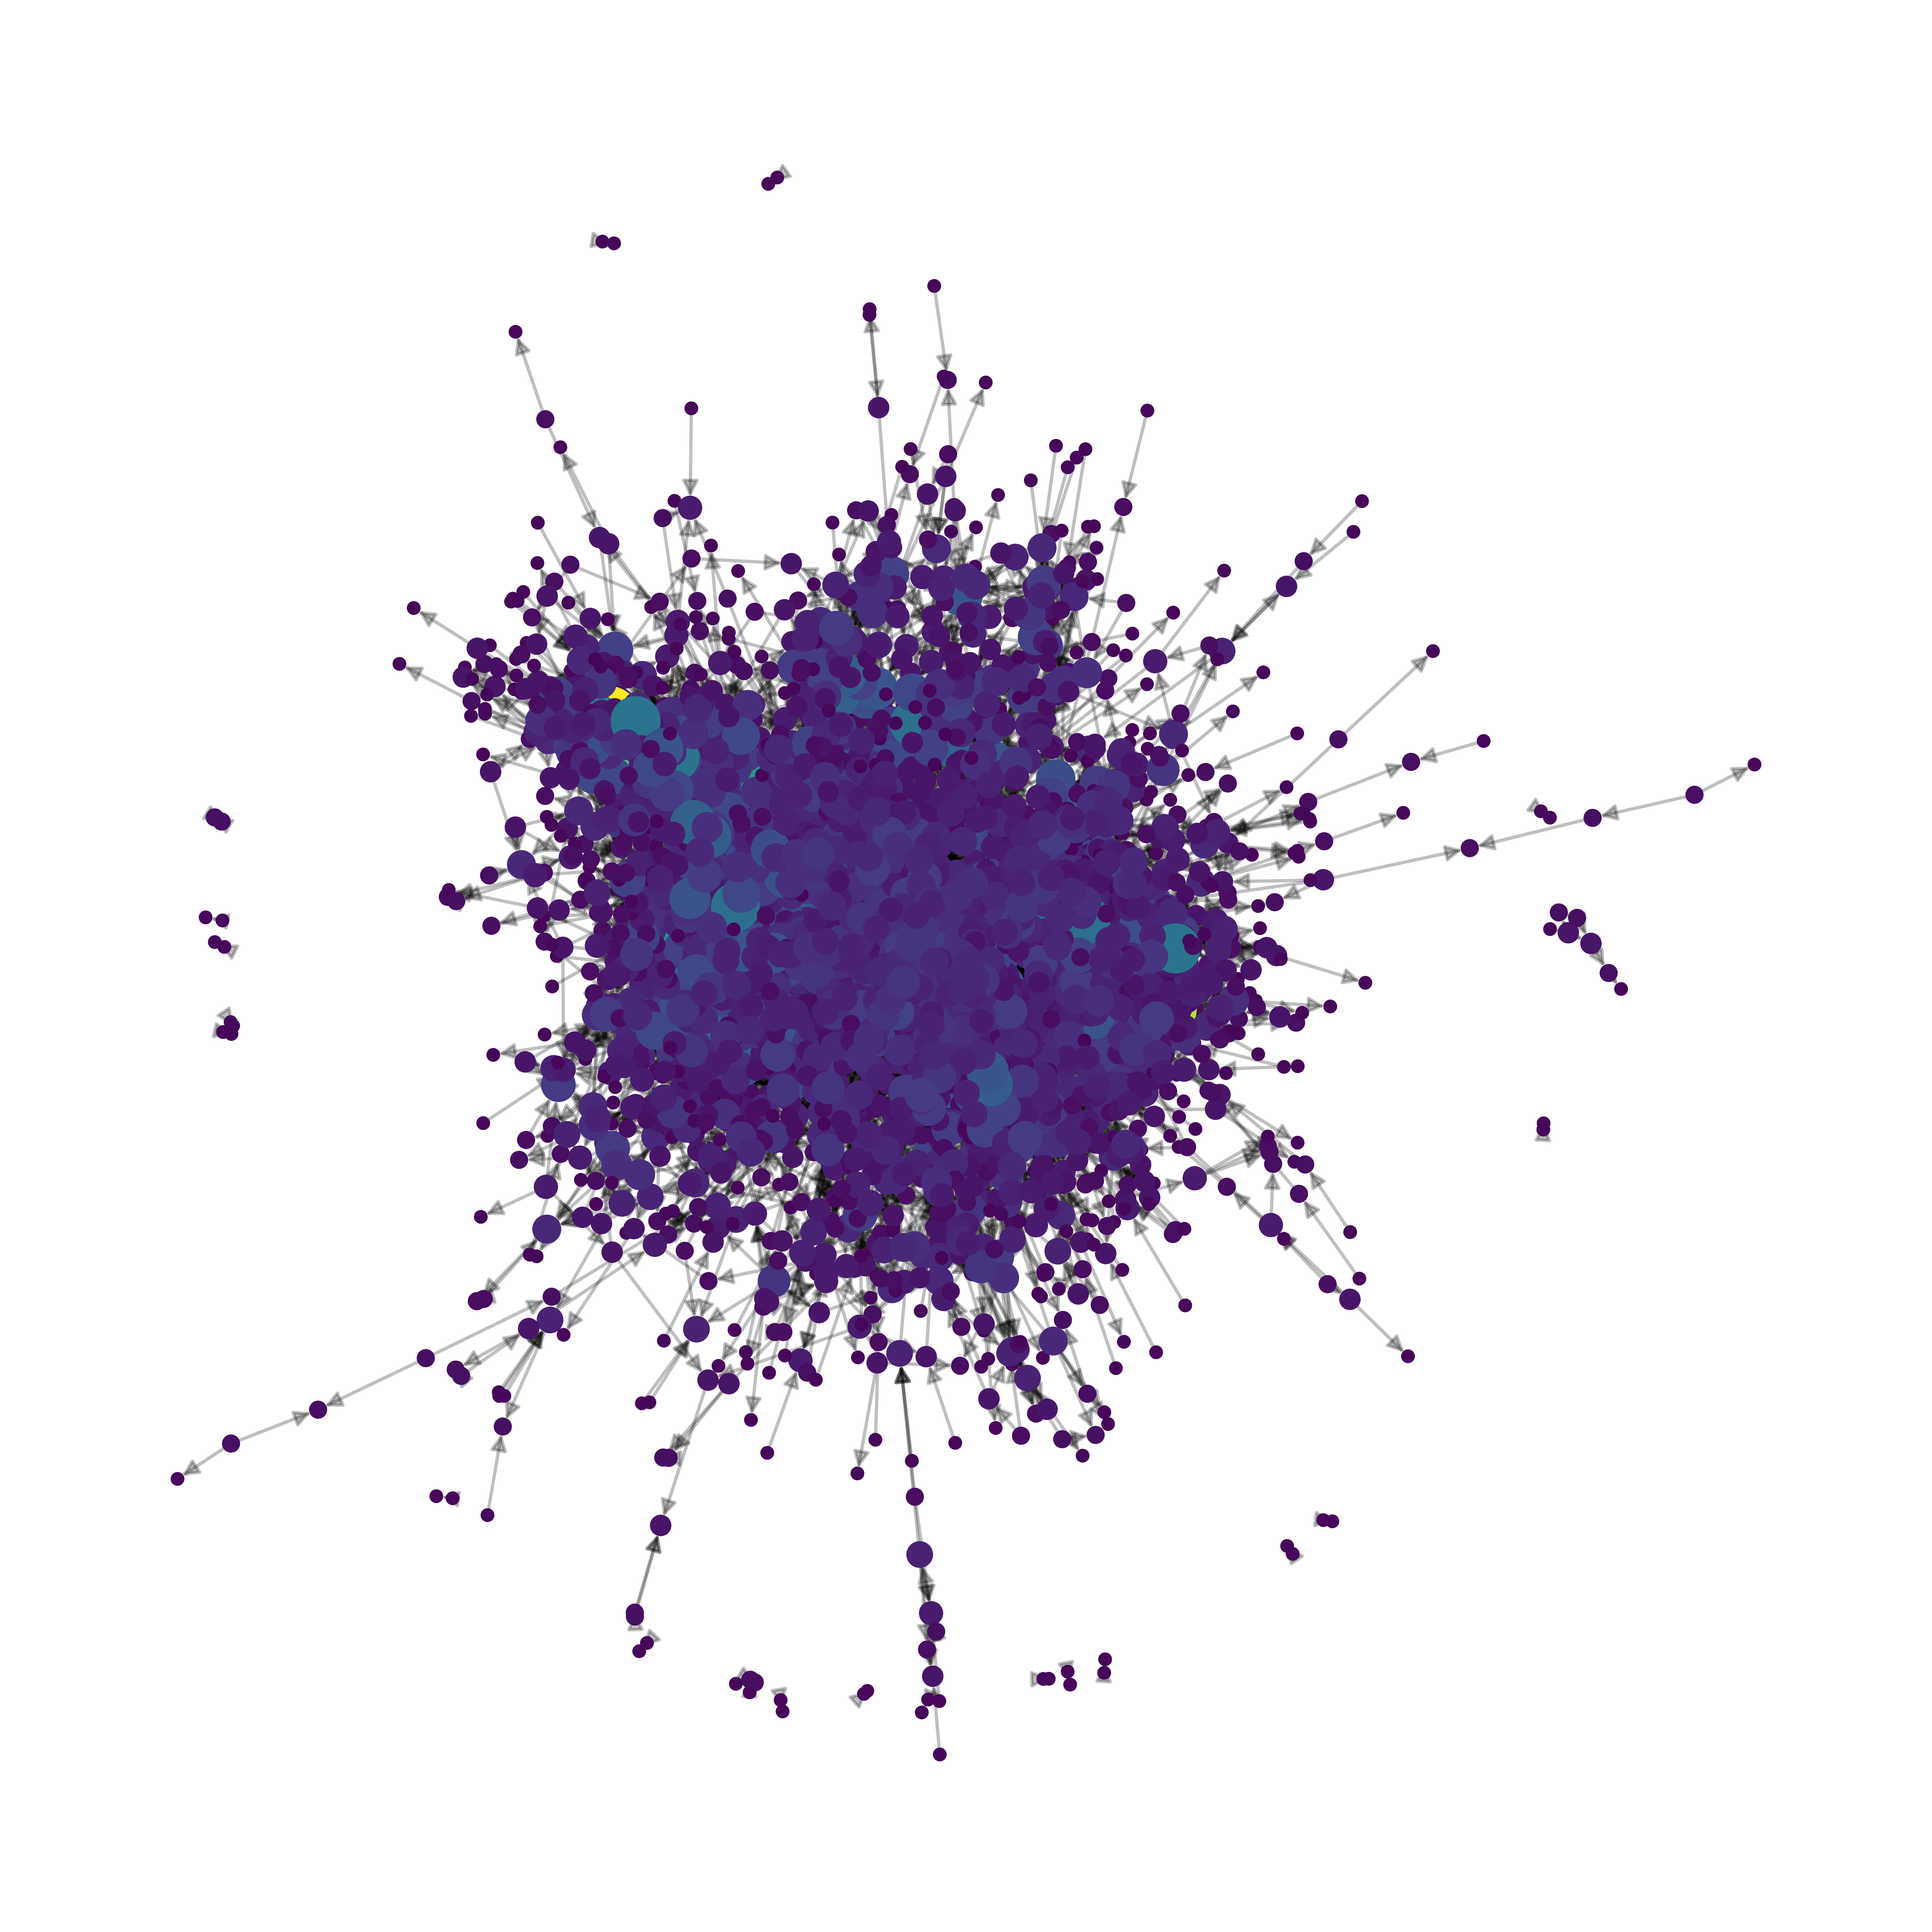

In [ ]:
# Read config
conf = OmegaConf.load('config.yaml')

# Set random seed and cpu number
set_cpu_num(conf.cpu_num)
seed_everything(conf.seed)

# Set data and log directory
if conf.graph_type == 'citation':
    conf.data_dir = f'data/{conf.graph_type}'
    conf.log_dir = f'logs/{conf.graph_type}/l{conf.lookback}_h{conf.horizon}'
elif conf.graph_type in ['BA', 'WS']:
    conf.data_dir = f'data/{conf.graph_type}_n{conf.node_num}_{conf.seed}'
    conf.log_dir = f'logs/{conf.graph_type}_n{conf.node_num}_{conf.seed}/l{conf.lookback}_h{conf.horizon}'
else:
    conf.data_dir = f'data/{conf.graph_type}'
    conf.log_dir = f'logs/{conf.graph_type}/l{conf.lookback}_h{conf.horizon}'

print("="*50)
print("STEP 1: Building Citation Network")
print("="*50)

# Create graph
simulator = NetworkSimulator(args=conf)
network, adj_matrix = simulator.buildNetwork()

# Update node_num from actual graph size
conf.node_num = network.number_of_nodes()
print(f"Final network size: {conf.node_num} nodes, {network.number_of_edges()} edges")

# Draw graph
drawGraph(network, layout='spring', filter='random', threshold=0.5, out_path=f'{conf.data_dir}/graph.png')
print(f"Graph visualization saved to: {conf.data_dir}/graph.png")

#skip steps 1.5-5 if you have ressult.npz

In [ ]:
results = np.load("result.npz")
predicted_dynamics = results['predict']  # Shape: (n_samples, horizon, node_num, feature_dim)
actual_dynamics = results['ground_truth']
os.makedirs("logs/citation/l3_h3/CitationNetwork/DiskNet/", exist_ok=True)

print(f"Prediction shape: {predicted_dynamics.shape}")
print(f"Ground truth shape: {actual_dynamics.shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'result.npz'

#step 1.5

In [ ]:
if conf.graph_type == 'citation':
  print("="*50)
  print("STEP 1.5: Update csv files")
  print("="*50)
  build_updated_clean_files("data/citation")

STEP 1.5: Update csv files
[GRAPH] Loaded pruned graph: 7098 nodes, 31864 edges
[EDGES] Saved updated edges: 31864 rows → data/citation/updated_clean_edges.csv
[META] Saved updated metadata: 7098 rows → data/citation/updated_clean_meta.csv
[IDMAP] Saved updated ID map: 7098 entries → data/citation/updated_id2idx_clean.json

✔ DONE: updated_clean_edges.csv, updated_clean_meta.csv, and updated_id2idx_clean.json created.


#step 2

In [ ]:
print("="*50)
print("STEP 2: Creating Citation Dynamics")
print("="*50)

# Simulate network dynamics
simulator.getSimTraj()

STEP 2: Creating Citation Dynamics
No dynamics found. Generating dynamics from processed graph...
Years: 2000 -> 2020, T=21
Saved dynamics and id2idx.json


array([[[71., 71.,  6., 10.],
        [13., 13.,  2.,  1.],
        [ 1.,  1.,  1.,  0.],
        ...,
        [ 0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.]],

       [[ 0., 71.,  0.,  0.],
        [ 0., 13.,  0.,  0.],
        [ 0.,  1.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.]],

       [[ 0., 71.,  0.,  0.],
        [ 0., 13.,  0.,  0.],
        [ 0.,  1.,  0.,  0.],
        ...,
        [ 0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.],
        [ 0.,  0.,  0.,  0.]],

       ...,

       [[ 0., 71.,  0.,  0.],
        [ 0., 13.,  0.,  0.],
        [ 0.,  1.,  0.,  0.],
        ...,
        [ 0., 11.,  0.,  0.],
        [ 0., 11.,  0.,  0.],
        [ 0., 11.,  0.,  0.]],

       [[ 0., 71.,  0.,  0.],
        [ 0., 13.,  0.,  0.],
        [ 0.,  1.,  0.,  0.],
        ...,
        [ 0., 11.,  0.,  0.],
        [ 0., 11.,  0.,  0.],
        [ 0., 11.,  0.,  0.]],

       [[ 0.

#step 3 with conf changes

In [ ]:
"""
conf.lookback = 3
conf.horizon = 3
conf.max_epoch = 10
conf.batch_size = 2
conf.train_ratio = 0.6
conf.val_ratio = 0.15
conf.test_ratio = 0.25


print("="*50)
print("STEP 3: Preparing Datasets")
print("="*50)

# Dataset
train_dataset = CitationDataset(conf, mode='train')
val_dataset = CitationDataset(conf, mode='val')
test_dataset = CitationDataset(conf, mode='test')


print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
"""

#step 3

In [ ]:
print("="*50)
print("STEP 3: Preparing Datasets")
print("="*50)

# Dataset
train_dataset = CitationDataset(conf, mode='train')
val_dataset = CitationDataset(conf, mode='val')
test_dataset = CitationDataset(conf, mode='test')


print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

STEP 3: Preparing Datasets
Train samples: 9
Val samples: 2
Test samples: 5


#step 4

In [ ]:
print("="*50)
print("STEP 4: Training DiskNet Model")
print("="*50)

# Model
model = DiskNet(conf, adj_matrix)
print_model_summary(model)

# Train
try:
    print(train_dataset.getLoader())
    print(val_dataset.getLoader())
    model.fit(train_dataset.getLoader(), val_dataset.getLoader())
except Exception as e:
    print(f"An error occurred during model training: {e}")
    import traceback
    traceback.print_exc()


STEP 4: Training DiskNet Model
Initializing super node embedding...
Pretrain identity backbone[499]: 0.0072
DiskNet(
  (repr_net1): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  )
  (repr_net2): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Tanh()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  )
  (softmax): Softmax(dim=-1)
  (agc_mlp): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
  (tanh): Tanh()
  (BackboneODE): BackboneODE(
    (init_enc): Sequential(
      (0): Linear(in_features=3, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=1, bias=True

#step 5

In [ ]:
print("="*50)
print("STEP 5: Testing Model")
print("="*50)

# Test and get predictions
model.test(test_dataset.getLoader())

# Load test results
results = np.load(f'{conf.log_dir}/{conf.dynamics}/{conf.model}/result.npz')
predicted_dynamics = results['predict']  # Shape: (n_samples, horizon, node_num, feature_dim)
actual_dynamics = results['ground_truth']

print(f"Prediction shape: {predicted_dynamics.shape}")
print(f"Ground truth shape: {actual_dynamics.shape}")

STEP 5: Testing Model
Testing...
Prediction shape: (5, 3, 7098, 4)
Ground truth shape: (5, 3, 7098, 4)


#fucntion for step 6

In [ ]:
def create_anomaly_report(conf, network, deviation_scores, anomaly_labels, anomalous_indices):

  report_path = f'{conf.log_dir}/{conf.dynamics}/{conf.model}/anomaly_report.txt'

  with open(report_path, 'w') as f:
      f.write("CITATION NETWORK ANOMALY DETECTION REPORT\n")
      f.write("="*50 + "\n\n")

      f.write(f"Graph Type: {conf.graph_type}\n")
      f.write(f"Total Nodes: {network.number_of_nodes()}\n")
      f.write(f"Total Edges: {network.number_of_edges()}\n")
      f.write(f"Lookback Window: {conf.lookback}\n")
      f.write(f"Prediction Horizon: {conf.horizon}\n\n")

      f.write("ANOMALY DETECTION RESULTS:\n")
      f.write("-" * 30 + "\n")
      f.write(f"Total Anomalies Detected: {len(anomalous_indices)}\n")
      f.write(f"Anomaly Rate: {len(anomalous_indices)/len(anomaly_labels)*100:.2f}%\n")
      f.write(f"Mean Deviation Score: {np.mean(deviation_scores):.6f}\n")
      f.write(f"Std Deviation Score: {np.std(deviation_scores):.6f}\n\n")

      f.write("TOP 20 MOST ANOMALOUS NODES:\n")
      f.write("-" * 30 + "\n")
      f.write("Rank | Node ID | Deviation Score\n")
      f.write("-" * 35 + "\n")

      top_20 = anomalous_indices[np.argsort(deviation_scores[anomalous_indices])[-20:]]
      for rank, idx in enumerate(reversed(top_20), 1):
          f.write(f"{rank:4d} | {idx:7d} | {deviation_scores[idx]:13.6f}\n")

  print(f"Detailed report saved to: {report_path}")

#step 6

In [ ]:
print("="*50)
print("STEP 6: Anomaly Detection")
print("="*50)

# Initialize anomaly detector
detector = CitationAnomalyDetector(contamination=0.1)  # Expect 10% anomalies

# Detect anomalies
# Assumes: anomaly_labels are -1 for anomaly, 1 for normal
deviation_scores, anomaly_labels = detector.detect_anomalies(predicted_dynamics, actual_dynamics)

# Count anomalies (Using standard convention: -1 is ANOMALOUS)
n_anomalies = np.sum(anomaly_labels == -1)
n_normal = np.sum(anomaly_labels == 1)

print(f"Total nodes analyzed: {len(anomaly_labels)}")
print(f"Anomalous nodes detected: {n_anomalies}")
print(f"Normal nodes: {n_normal}")
print(f"Anomaly rate: {n_anomalies/len(anomaly_labels)*100:.2f}%")


# 1. Get indices of all nodes classified as ANOMALOUS (labels == -1)
# NOTE: This index is used for saving all anomalies, not necessarily the top 10.
anomalous_indices = np.where(anomaly_labels == -1)[0]

# 2. Find the TOP 10 MOST EXTREME nodes based on the MAGNITUDE of the deviation score.
# This captures nodes with the highest positive OR highest negative scores.
# np.argsort returns indices sorted from smallest to largest absolute score.
# [-10:] takes the indices of the 10 largest absolute scores.
# [::-1] reverses that list so the most extreme is first.
abs_scores = np.abs(deviation_scores)
top_anomalies_indices = np.argsort(abs_scores)[-10:]
top_anomalies = top_anomalies_indices[::-1]

print("\nTop 10 Most EXTREME Anomalous Nodes (by score magnitude):")
print("Node ID | Deviation Score")
print("-" * 35)
for idx in top_anomalies:
    print(f"{idx:7d} | {deviation_scores[idx]:13.6f}")

# Save anomaly detection results
anomaly_results_path = f'{conf.log_dir}/{conf.dynamics}/{conf.model}/anomaly_results.npz'
np.savez(anomaly_results_path,
          deviation_scores=deviation_scores,
          anomaly_labels=anomaly_labels,
          anomalous_nodes=anomalous_indices,
          top_anomalies=top_anomalies)

print(f"\nAnomaly detection results saved to: {anomaly_results_path}")

# Create anomaly report
create_anomaly_report(conf, network, deviation_scores, anomaly_labels, anomalous_indices)

print("="*50)
print("PIPELINE COMPLETED!")
print("="*50)
print(f"Check results in: {conf.log_dir}/{conf.dynamics}/{conf.model}/")

STEP 6: Anomaly Detection
Total nodes analyzed: 7098
Anomalous nodes detected: 708
Normal nodes: 6390
Anomaly rate: 9.97%

Top 10 Most EXTREME Anomalous Nodes (by score magnitude):
Node ID | Deviation Score
-----------------------------------
   1427 |      4.340368
    866 |      3.993978
   1668 |      3.487214
    451 |      3.001365
    767 |      2.771424
    765 |      2.671763
    487 |      2.600348
      0 |      2.562423
    819 |      2.486671
    764 |      2.225417

Anomaly detection results saved to: logs/citation/l3_h3/CitationNetwork/DiskNet/anomaly_results.npz
Detailed report saved to: logs/citation/l3_h3/CitationNetwork/DiskNet/anomaly_report.txt
PIPELINE COMPLETED!
Check results in: logs/citation/l3_h3/CitationNetwork/DiskNet/


#step 7

In [ ]:
print("="*50)
print("STEP 7: Compiling Per-Year Anomaly Report")
print("="*50)

num_test_samples = predicted_dynamics.shape[0]
num_nodes = predicted_dynamics.shape[2]

print(f"Number of test samples (years): {num_test_samples}")
print(f"Number of nodes: {num_nodes}")

STEP 7: Compiling Per-Year Anomaly Report
Number of test samples (years): 5
Number of nodes: 7098


In [ ]:
df_report = pd.DataFrame({'Node ID': np.arange(num_nodes)})

# Process anomalies for each test sample (representing a distinct "year" or time window)
for i in range(num_test_samples):
    # Extract predicted and actual dynamics for the current test sample (year)
    pred_for_year_i = predicted_dynamics[i, :, :, :]
    actual_for_year_i = actual_dynamics[i, :, :, :]

    # Reshape for detector: add a batch dimension of 1
    pred_for_year_i_batched = pred_for_year_i[np.newaxis, :, :, :]
    actual_for_year_i_batched = actual_for_year_i[np.newaxis, :, :, :]

    # Detect anomalies for this specific "year"
    deviation_scores_i, anomaly_labels_i = detector.detect_anomalies(
        pred_for_year_i_batched, actual_for_year_i_batched
    )

    # Convert anomaly labels from {-1, 1} to {0, 1} for clarity (1 for anomaly, 0 for normal)
    is_anomaly_binary_i = (anomaly_labels_i == -1).astype(int)

    # Add results to the DataFrame
    df_report[f'Year {i} (Deviation Score)'] = deviation_scores_i
    df_report[f' Year {i} (Is Anomaly)'] = is_anomaly_binary_i


# Calculate the Mean Deviation Score for each node across all years
score_columns = [col for col in df_report.columns if '(Deviation Score)' in col]
df_report['Mean Deviation Score'] = df_report[score_columns].mean(axis=1)

# Calculate Anomaly Status Churn
# Identify all binary anomaly status columns
anomaly_status_columns = [col for col in df_report.columns if '(Is Anomaly)' in col]

# The churn calculation:
# If the max value (1) is greater than the min value (0) for a node across all years,
# it means the status must have changed from 0 to 1 or vice versa.
# df.max(axis=1) - df.min(axis=1) will be 1 if there was a change (1-0) and 0 if not (0-0 or 1-1).
df_report['Anomaly Status Churn'] = (
    df_report[anomaly_status_columns].max(axis=1) - df_report[anomaly_status_columns].min(axis=1)
)

# Define the path for the new CSV report
report_csv_path = os.path.join(conf.log_dir, conf.dynamics, conf.model, 'anomaly_report_per_year.csv')

# Save the compiled anomaly report to a CSV file
df_report.to_csv(report_csv_path, index=False)

print(f"Per-year anomaly report generated and saved to: {report_csv_path}")
print("Final Task: Per-year anomaly report successfully generated and saved to CSV.")

Per-year anomaly report generated and saved to: logs/citation/l3_h3/CitationNetwork/DiskNet/anomaly_report_per_year.csv
Final Task: Per-year anomaly report successfully generated and saved to CSV.


#step 8

STEP 8: Anomaly Detection Evaluation (Per-Year and Aggregate Visualization)

Generating plots for 5 time windows (Years 0 to 4)...


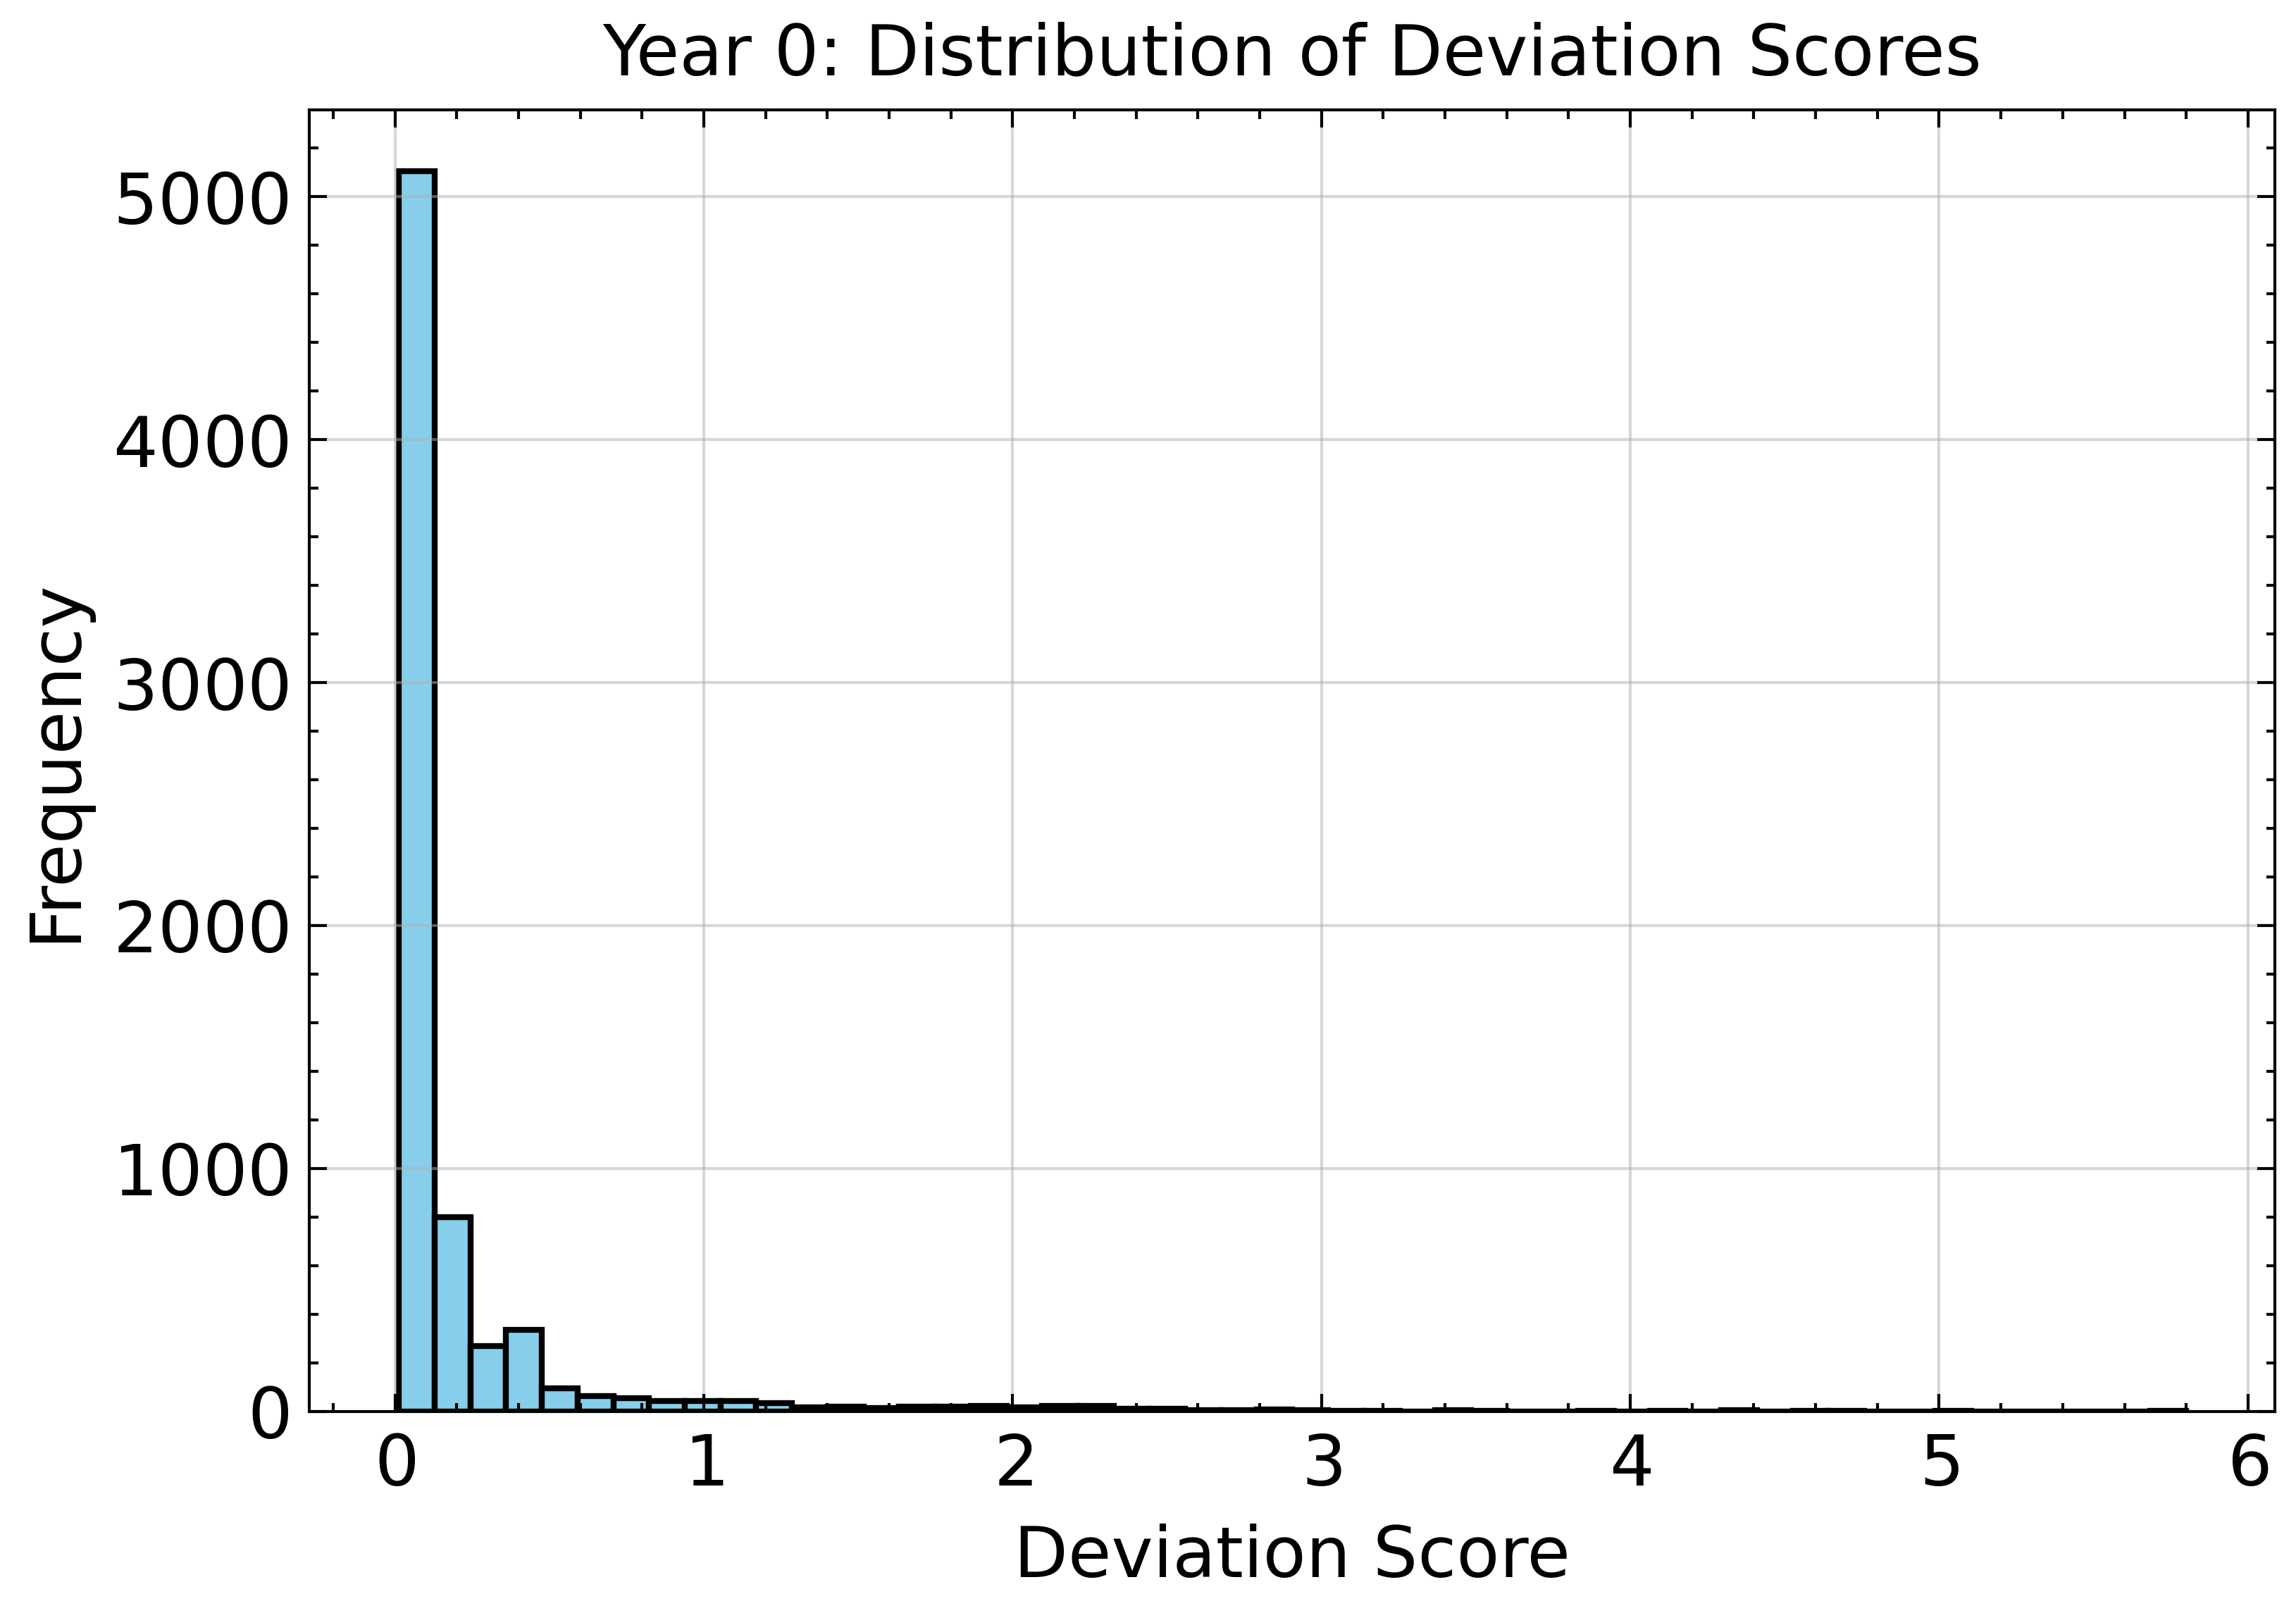

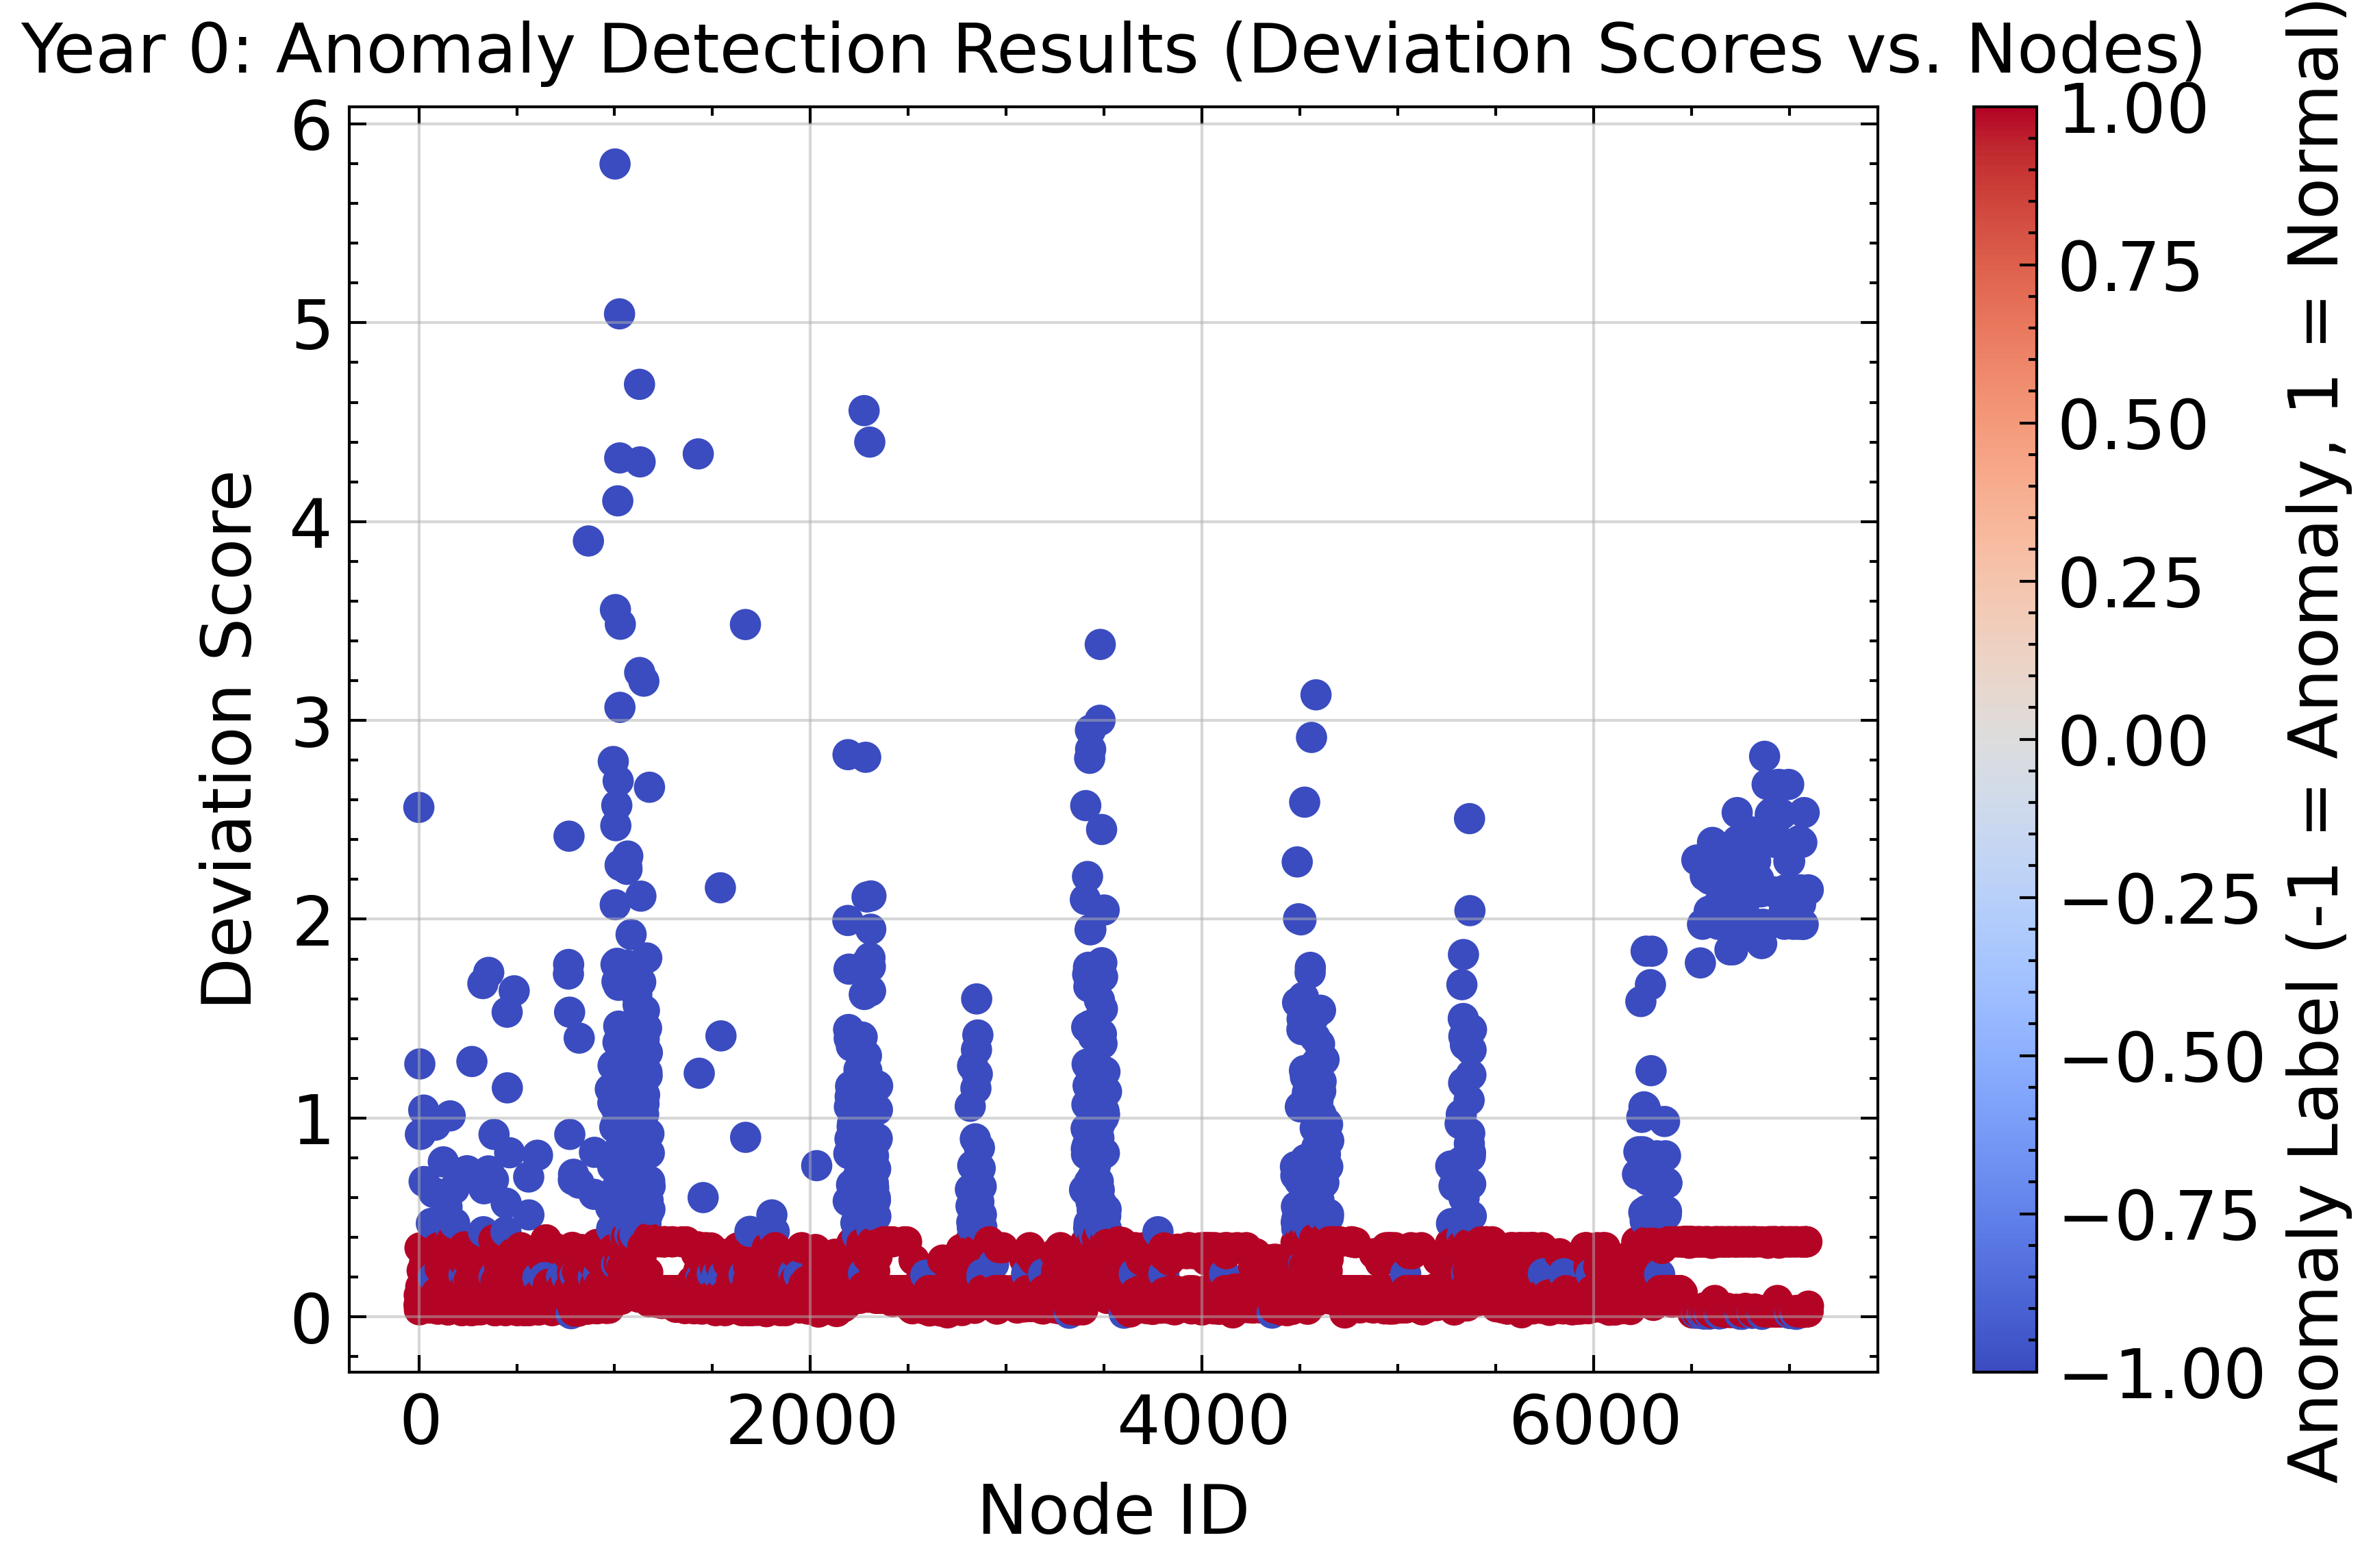

-> Plots generated for Year 0.


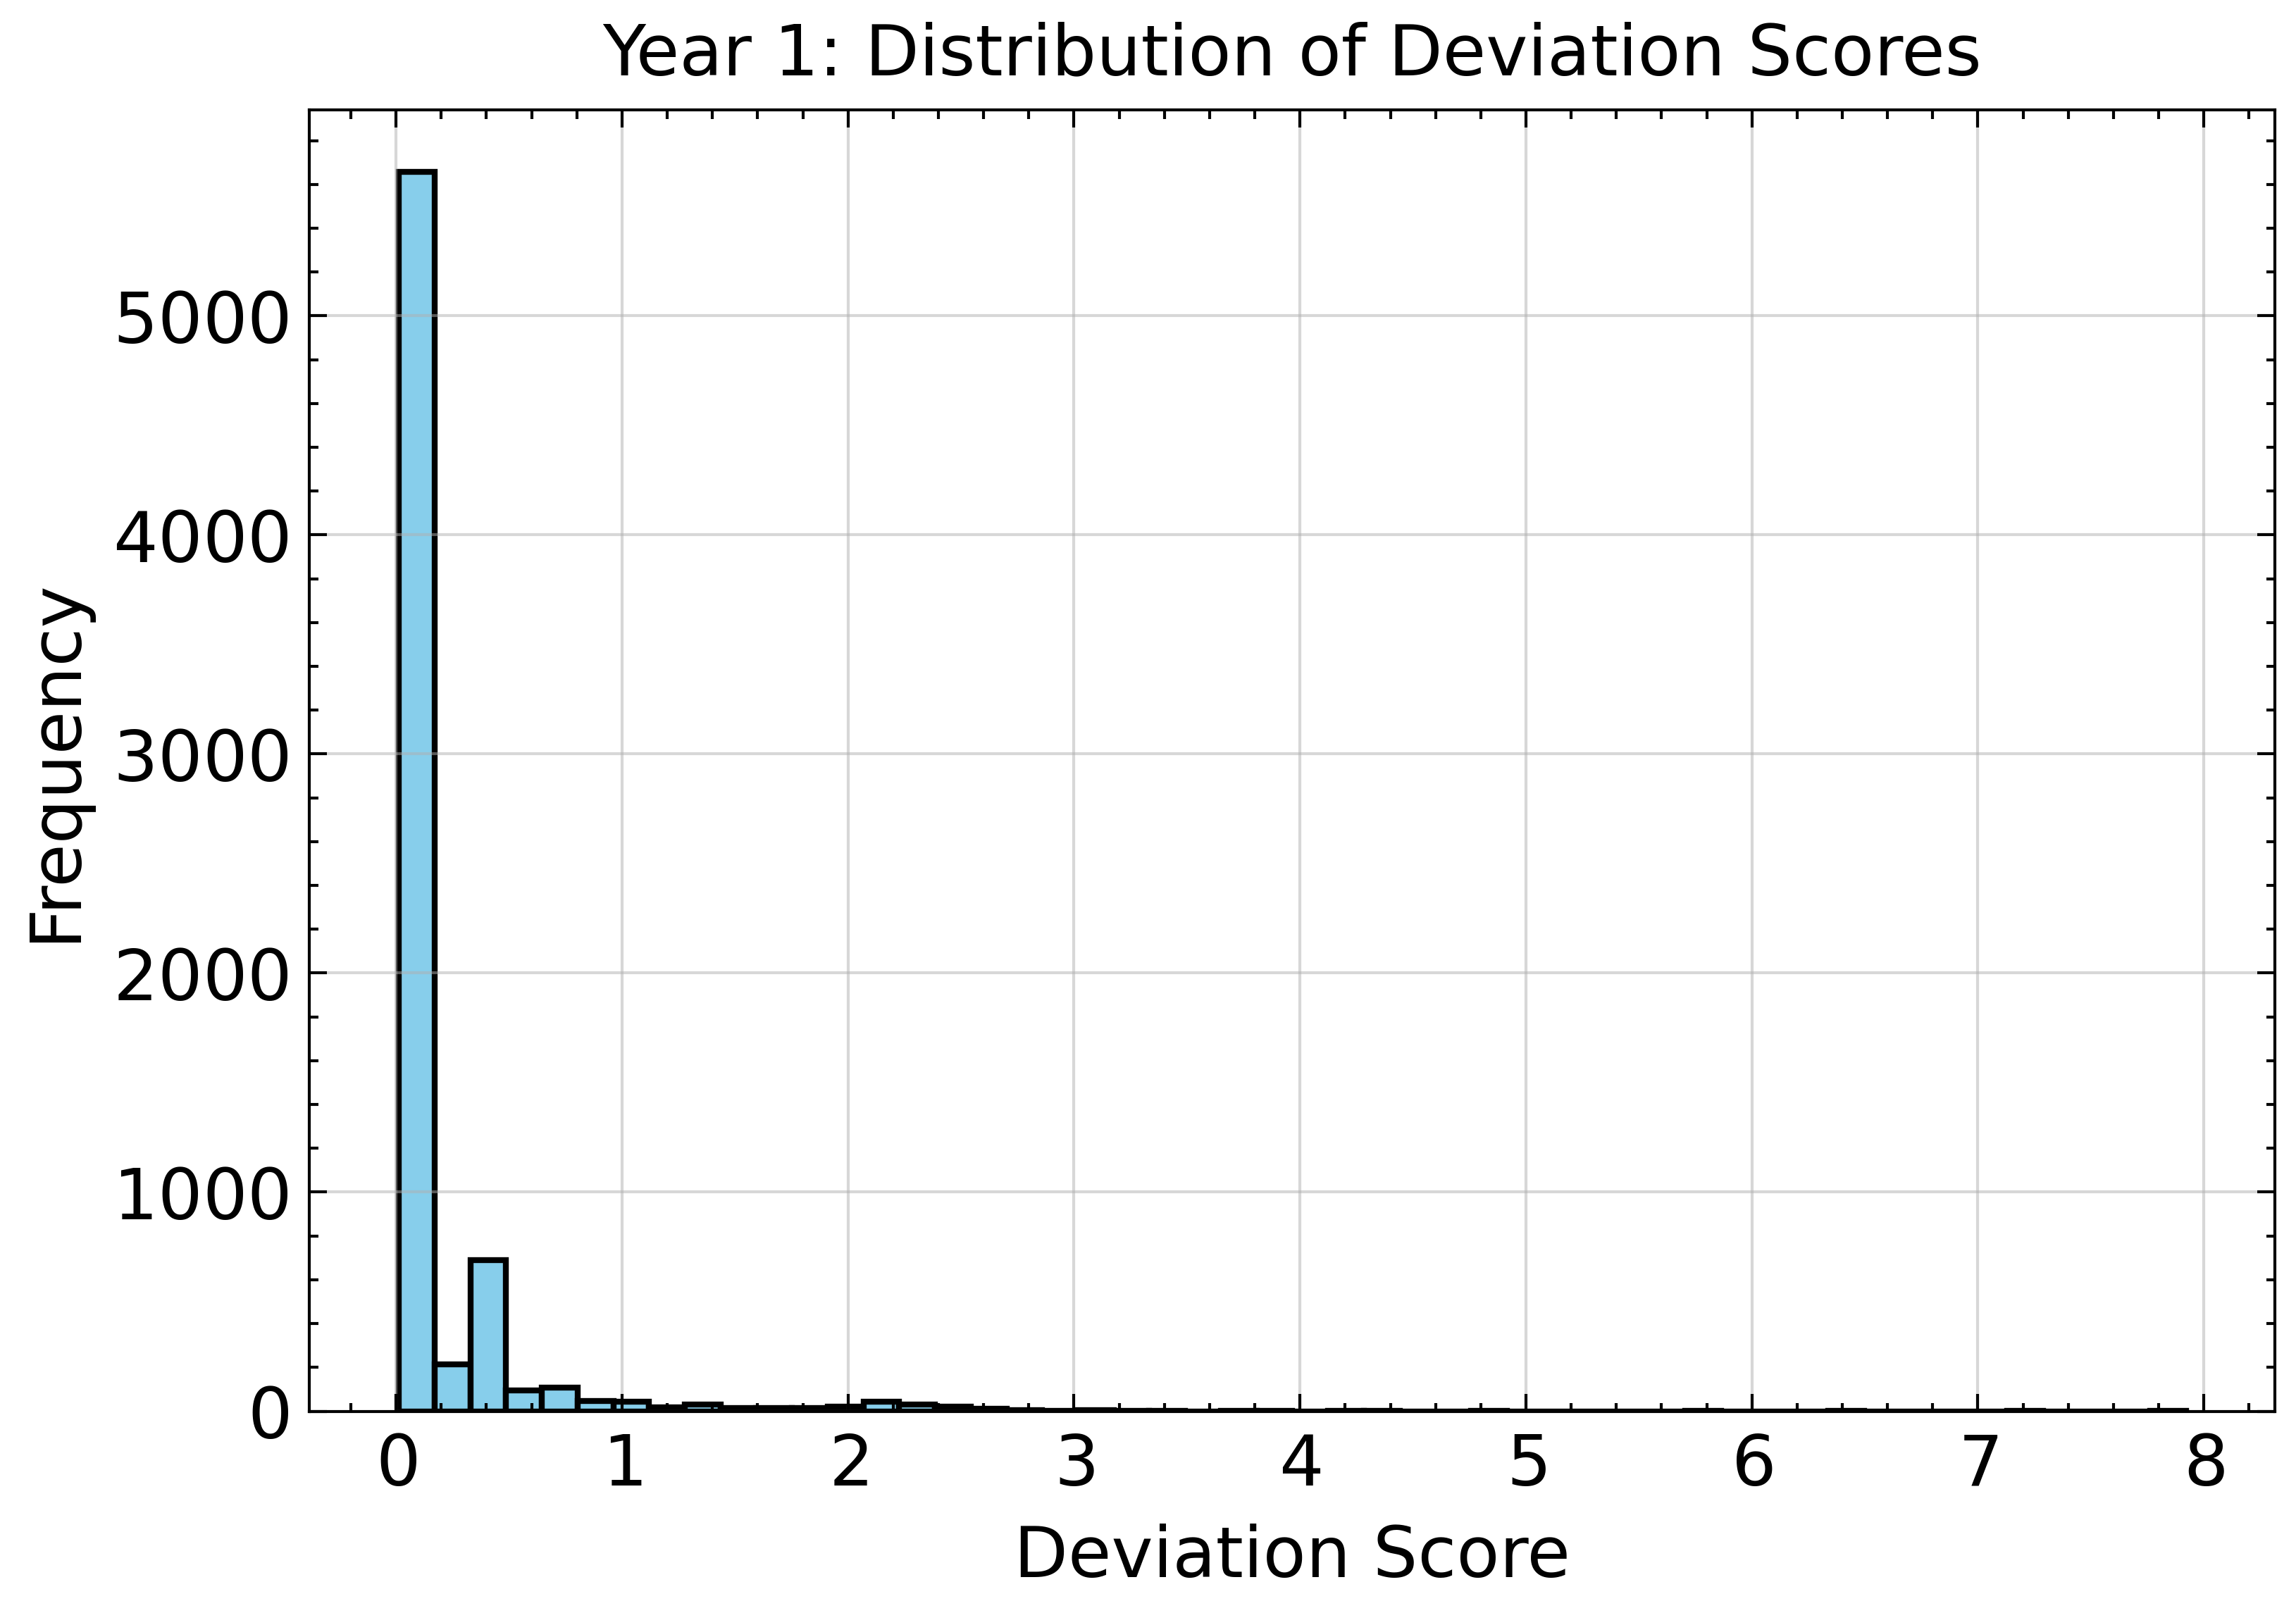

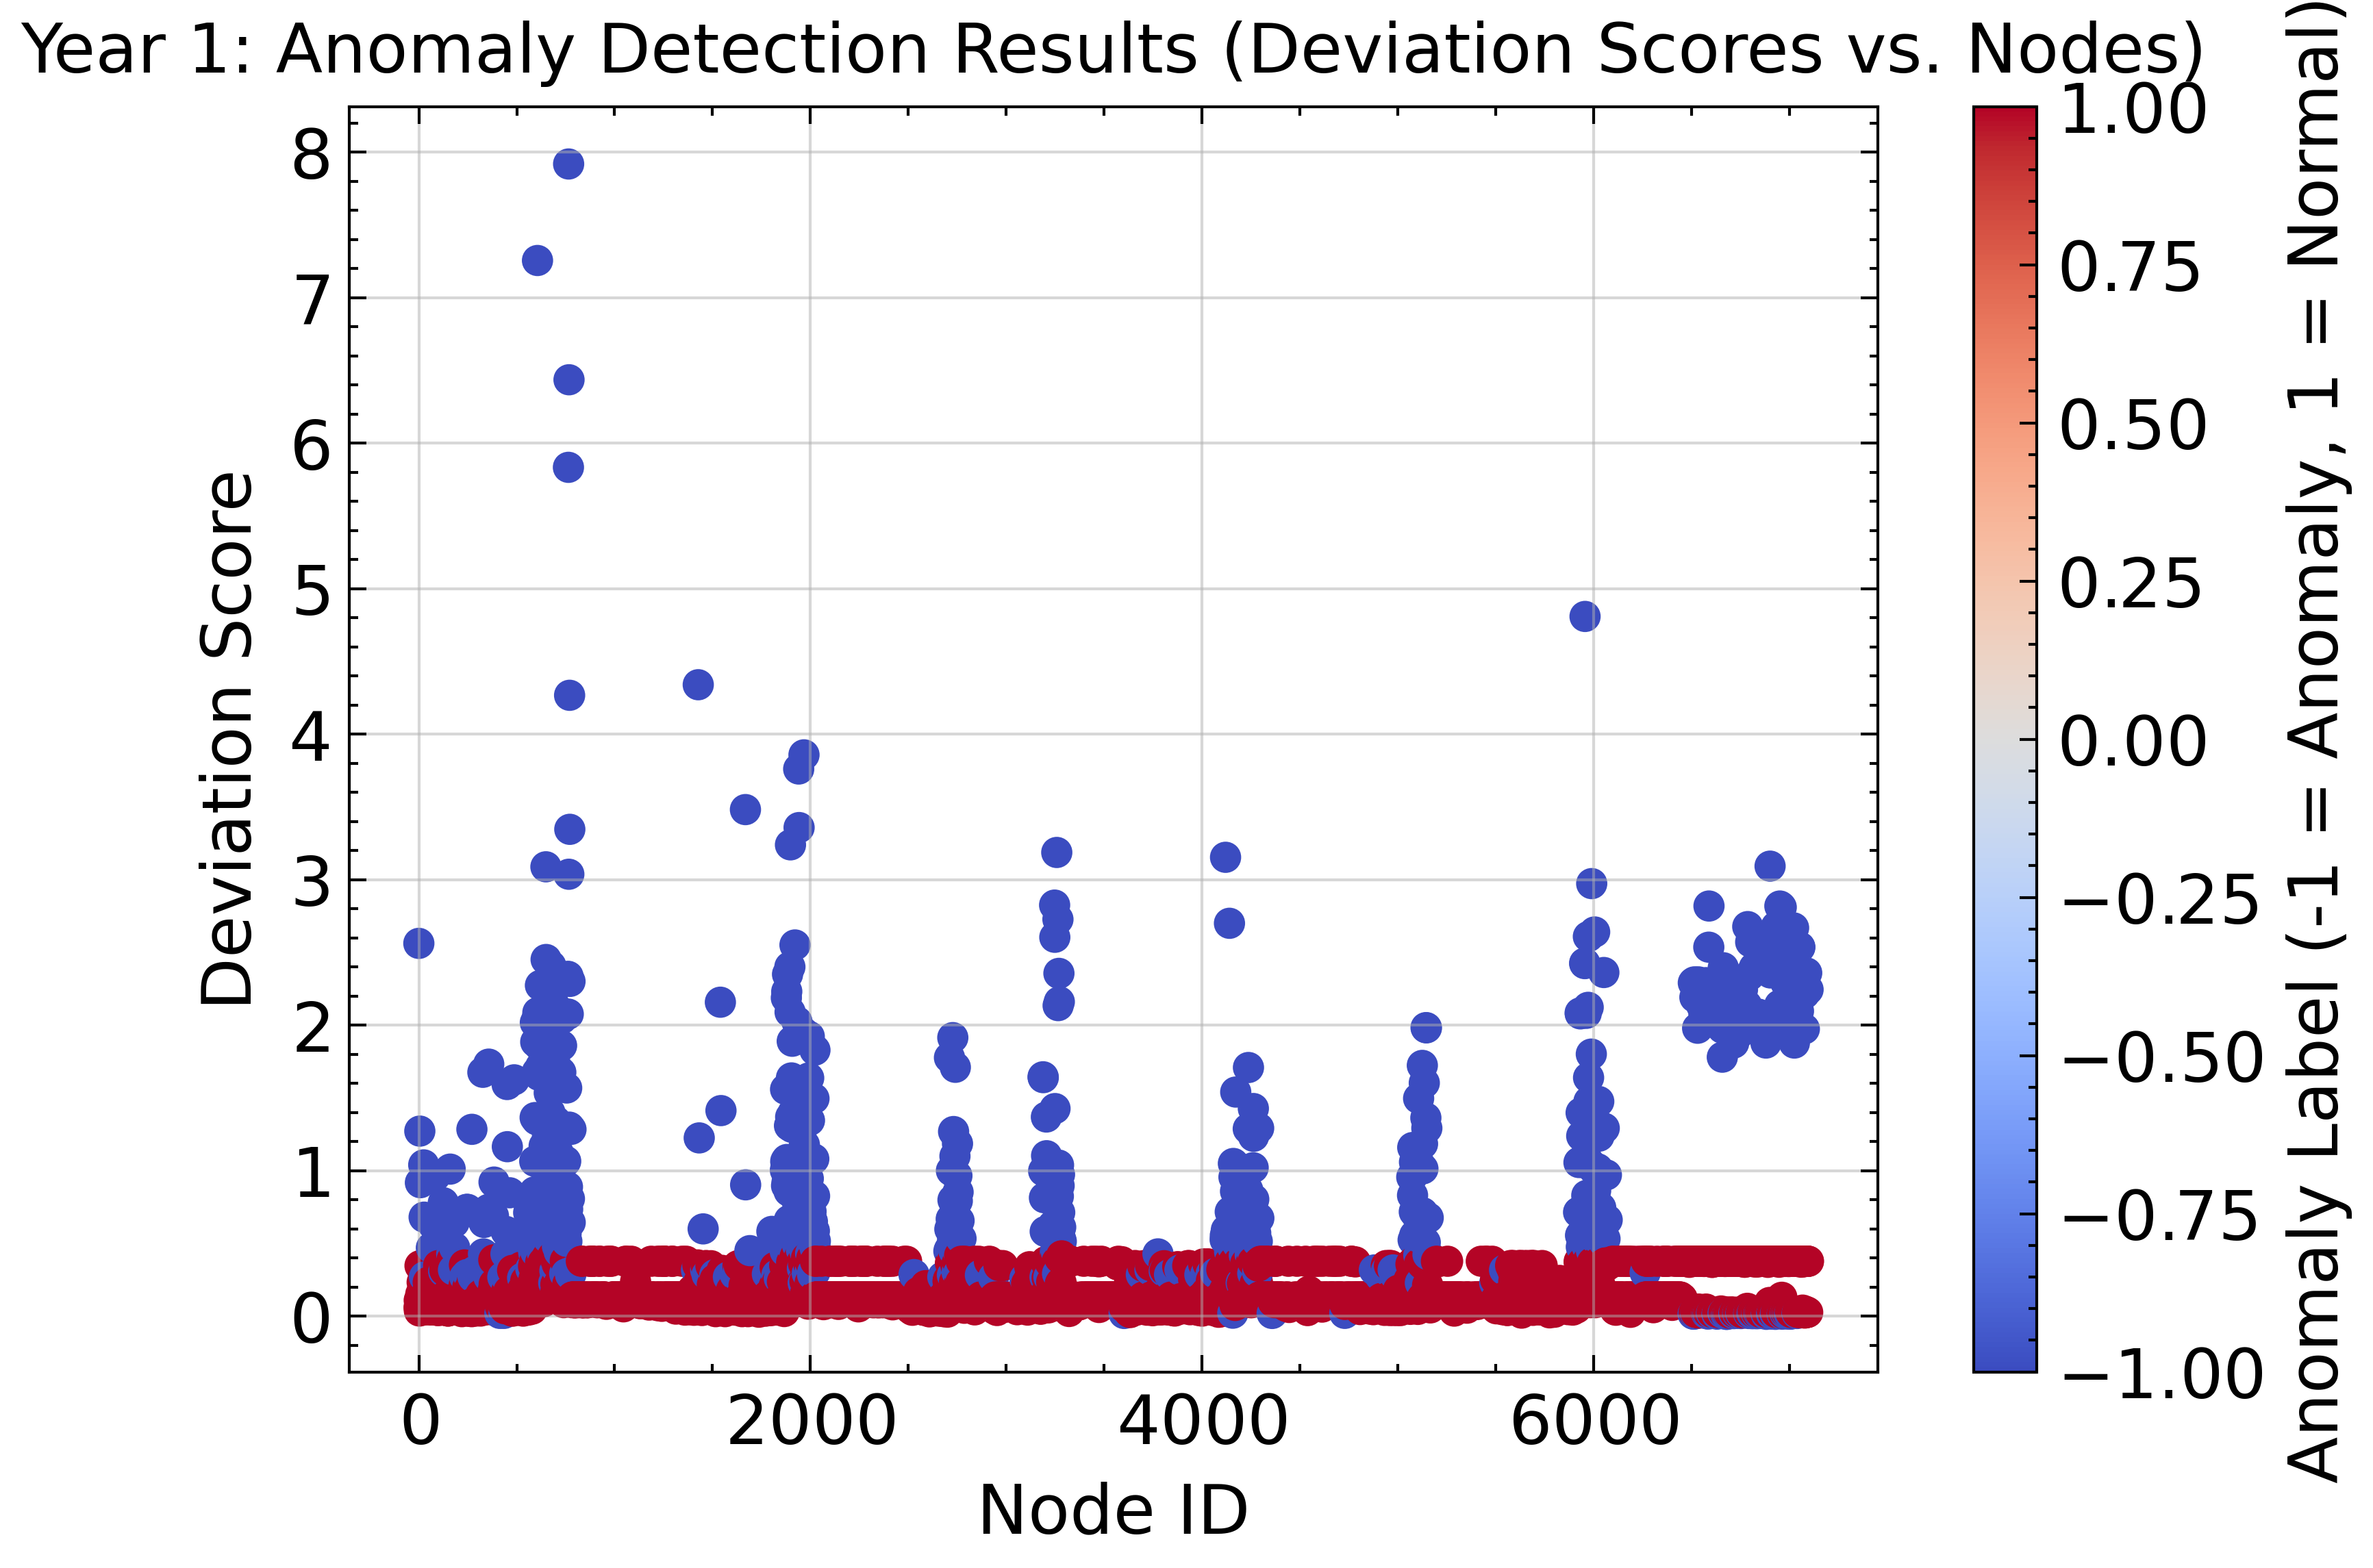

-> Plots generated for Year 1.


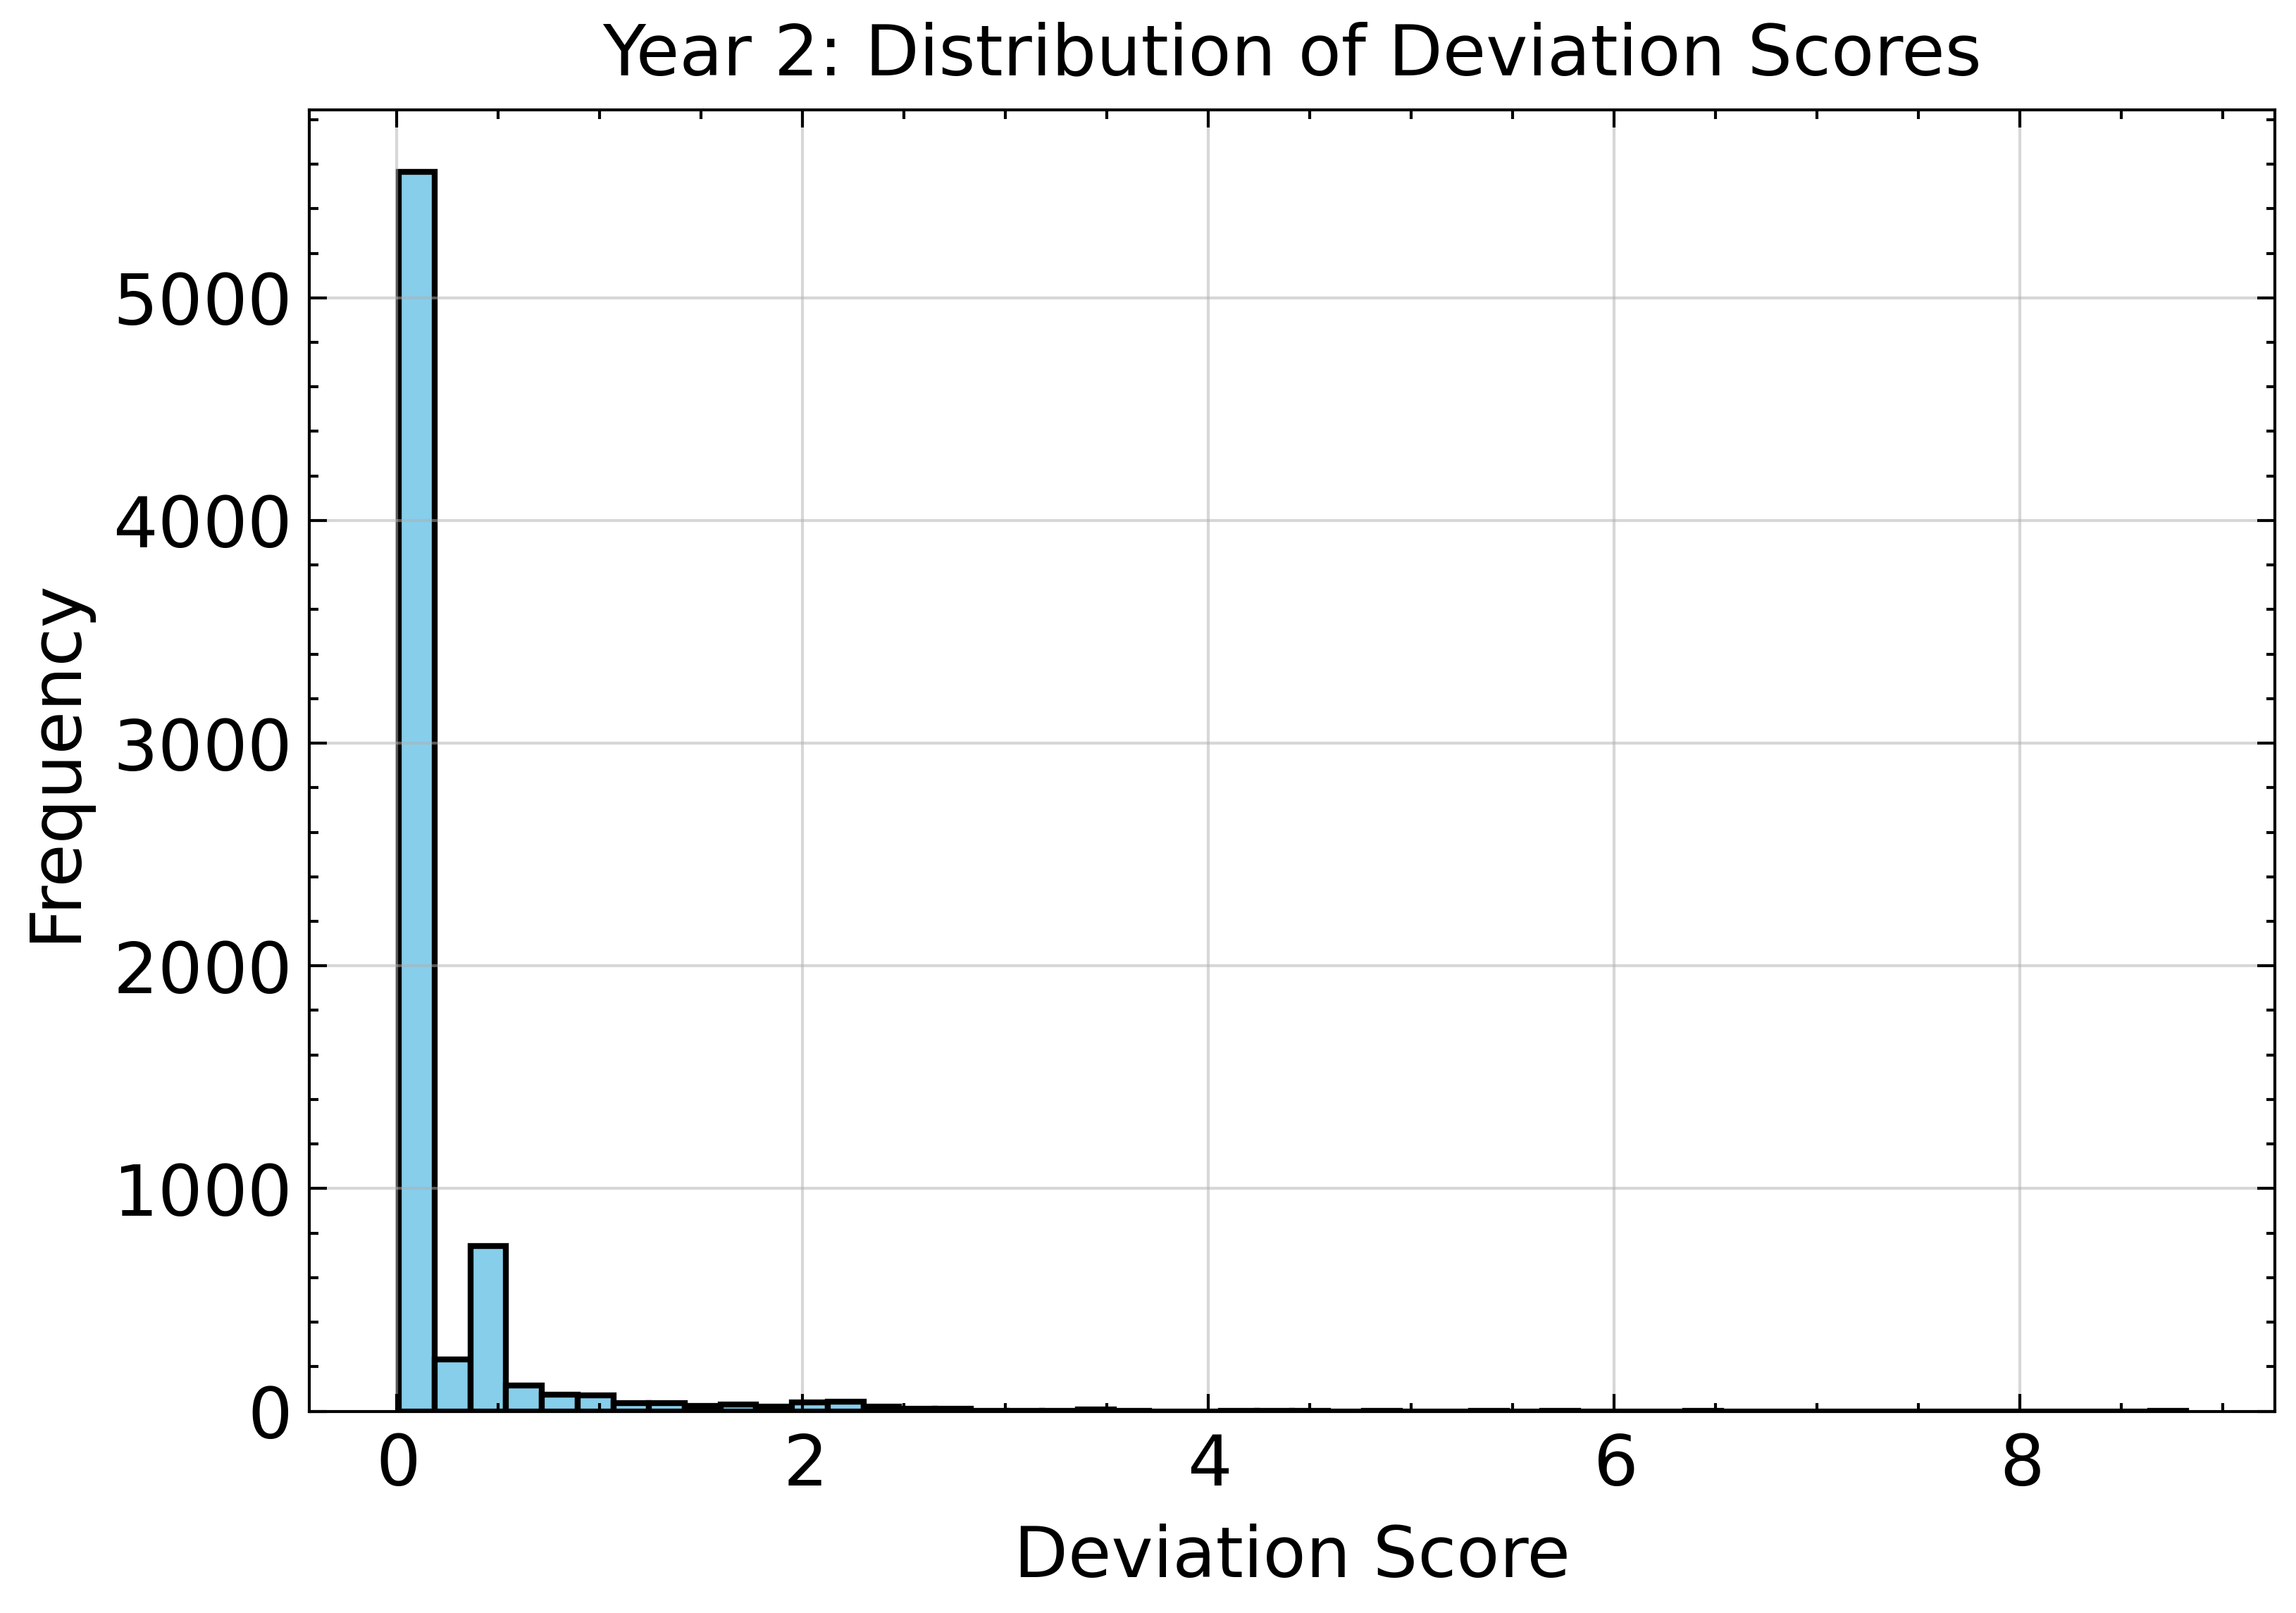

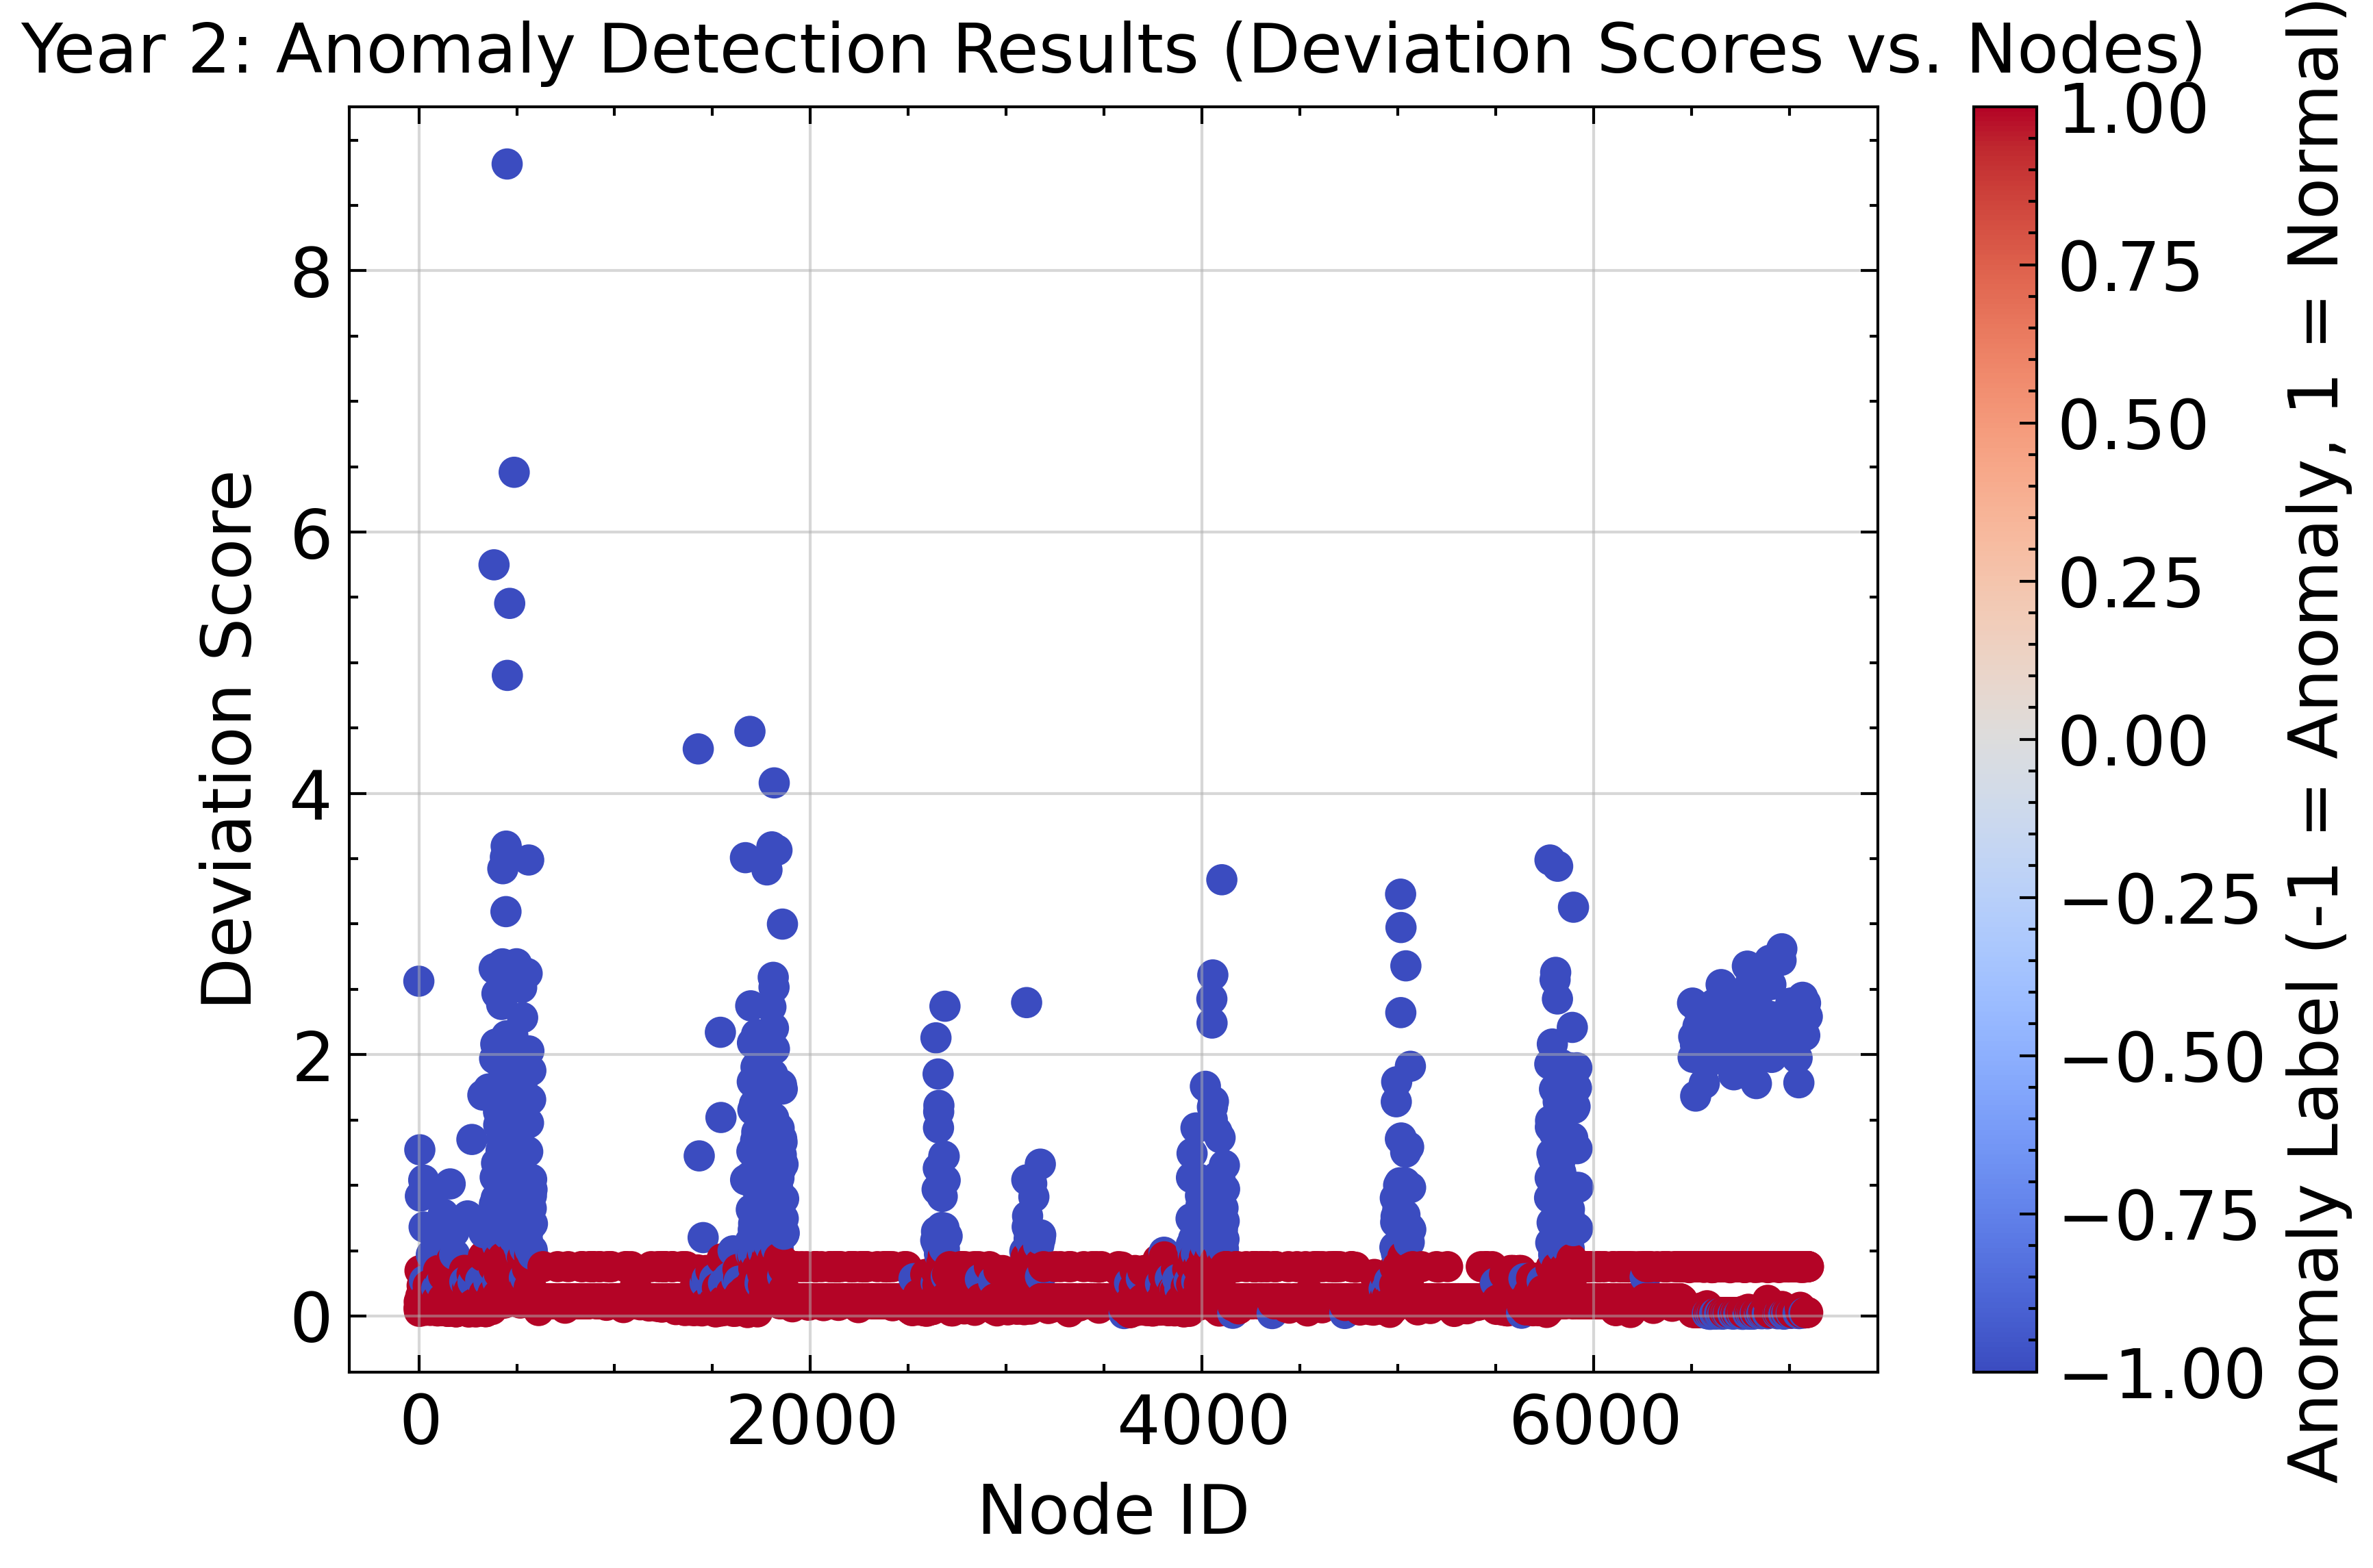

-> Plots generated for Year 2.


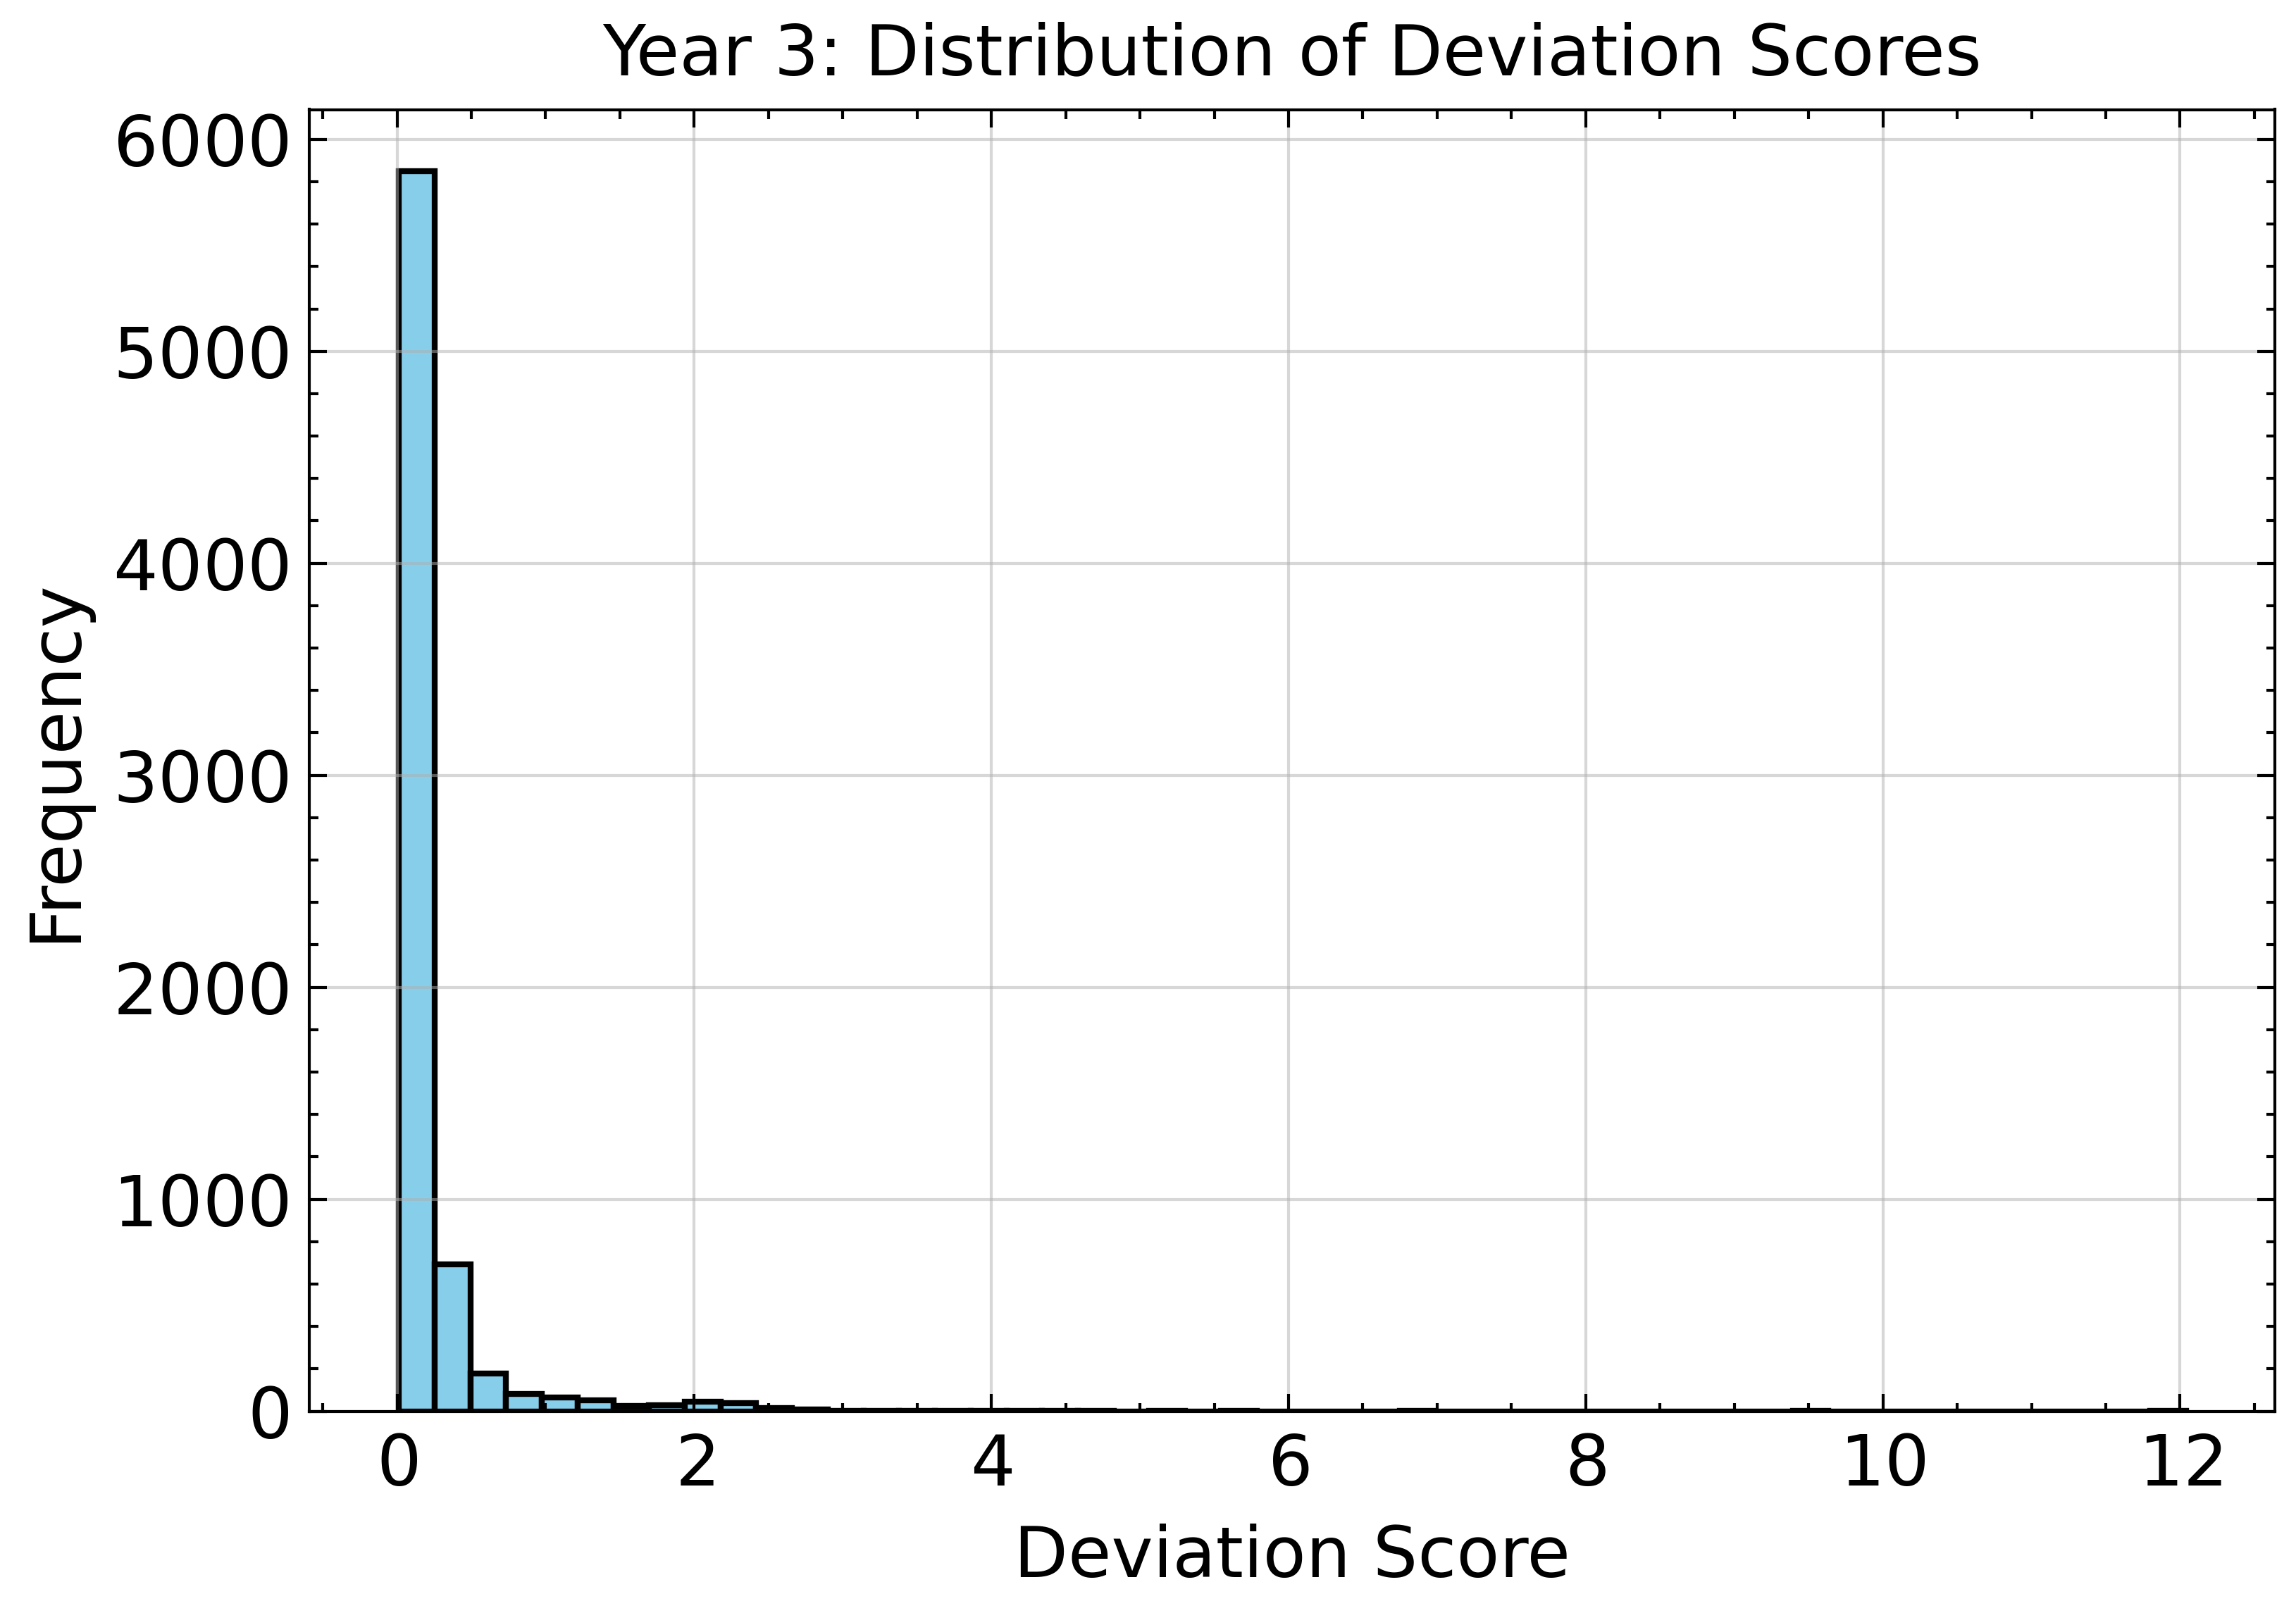

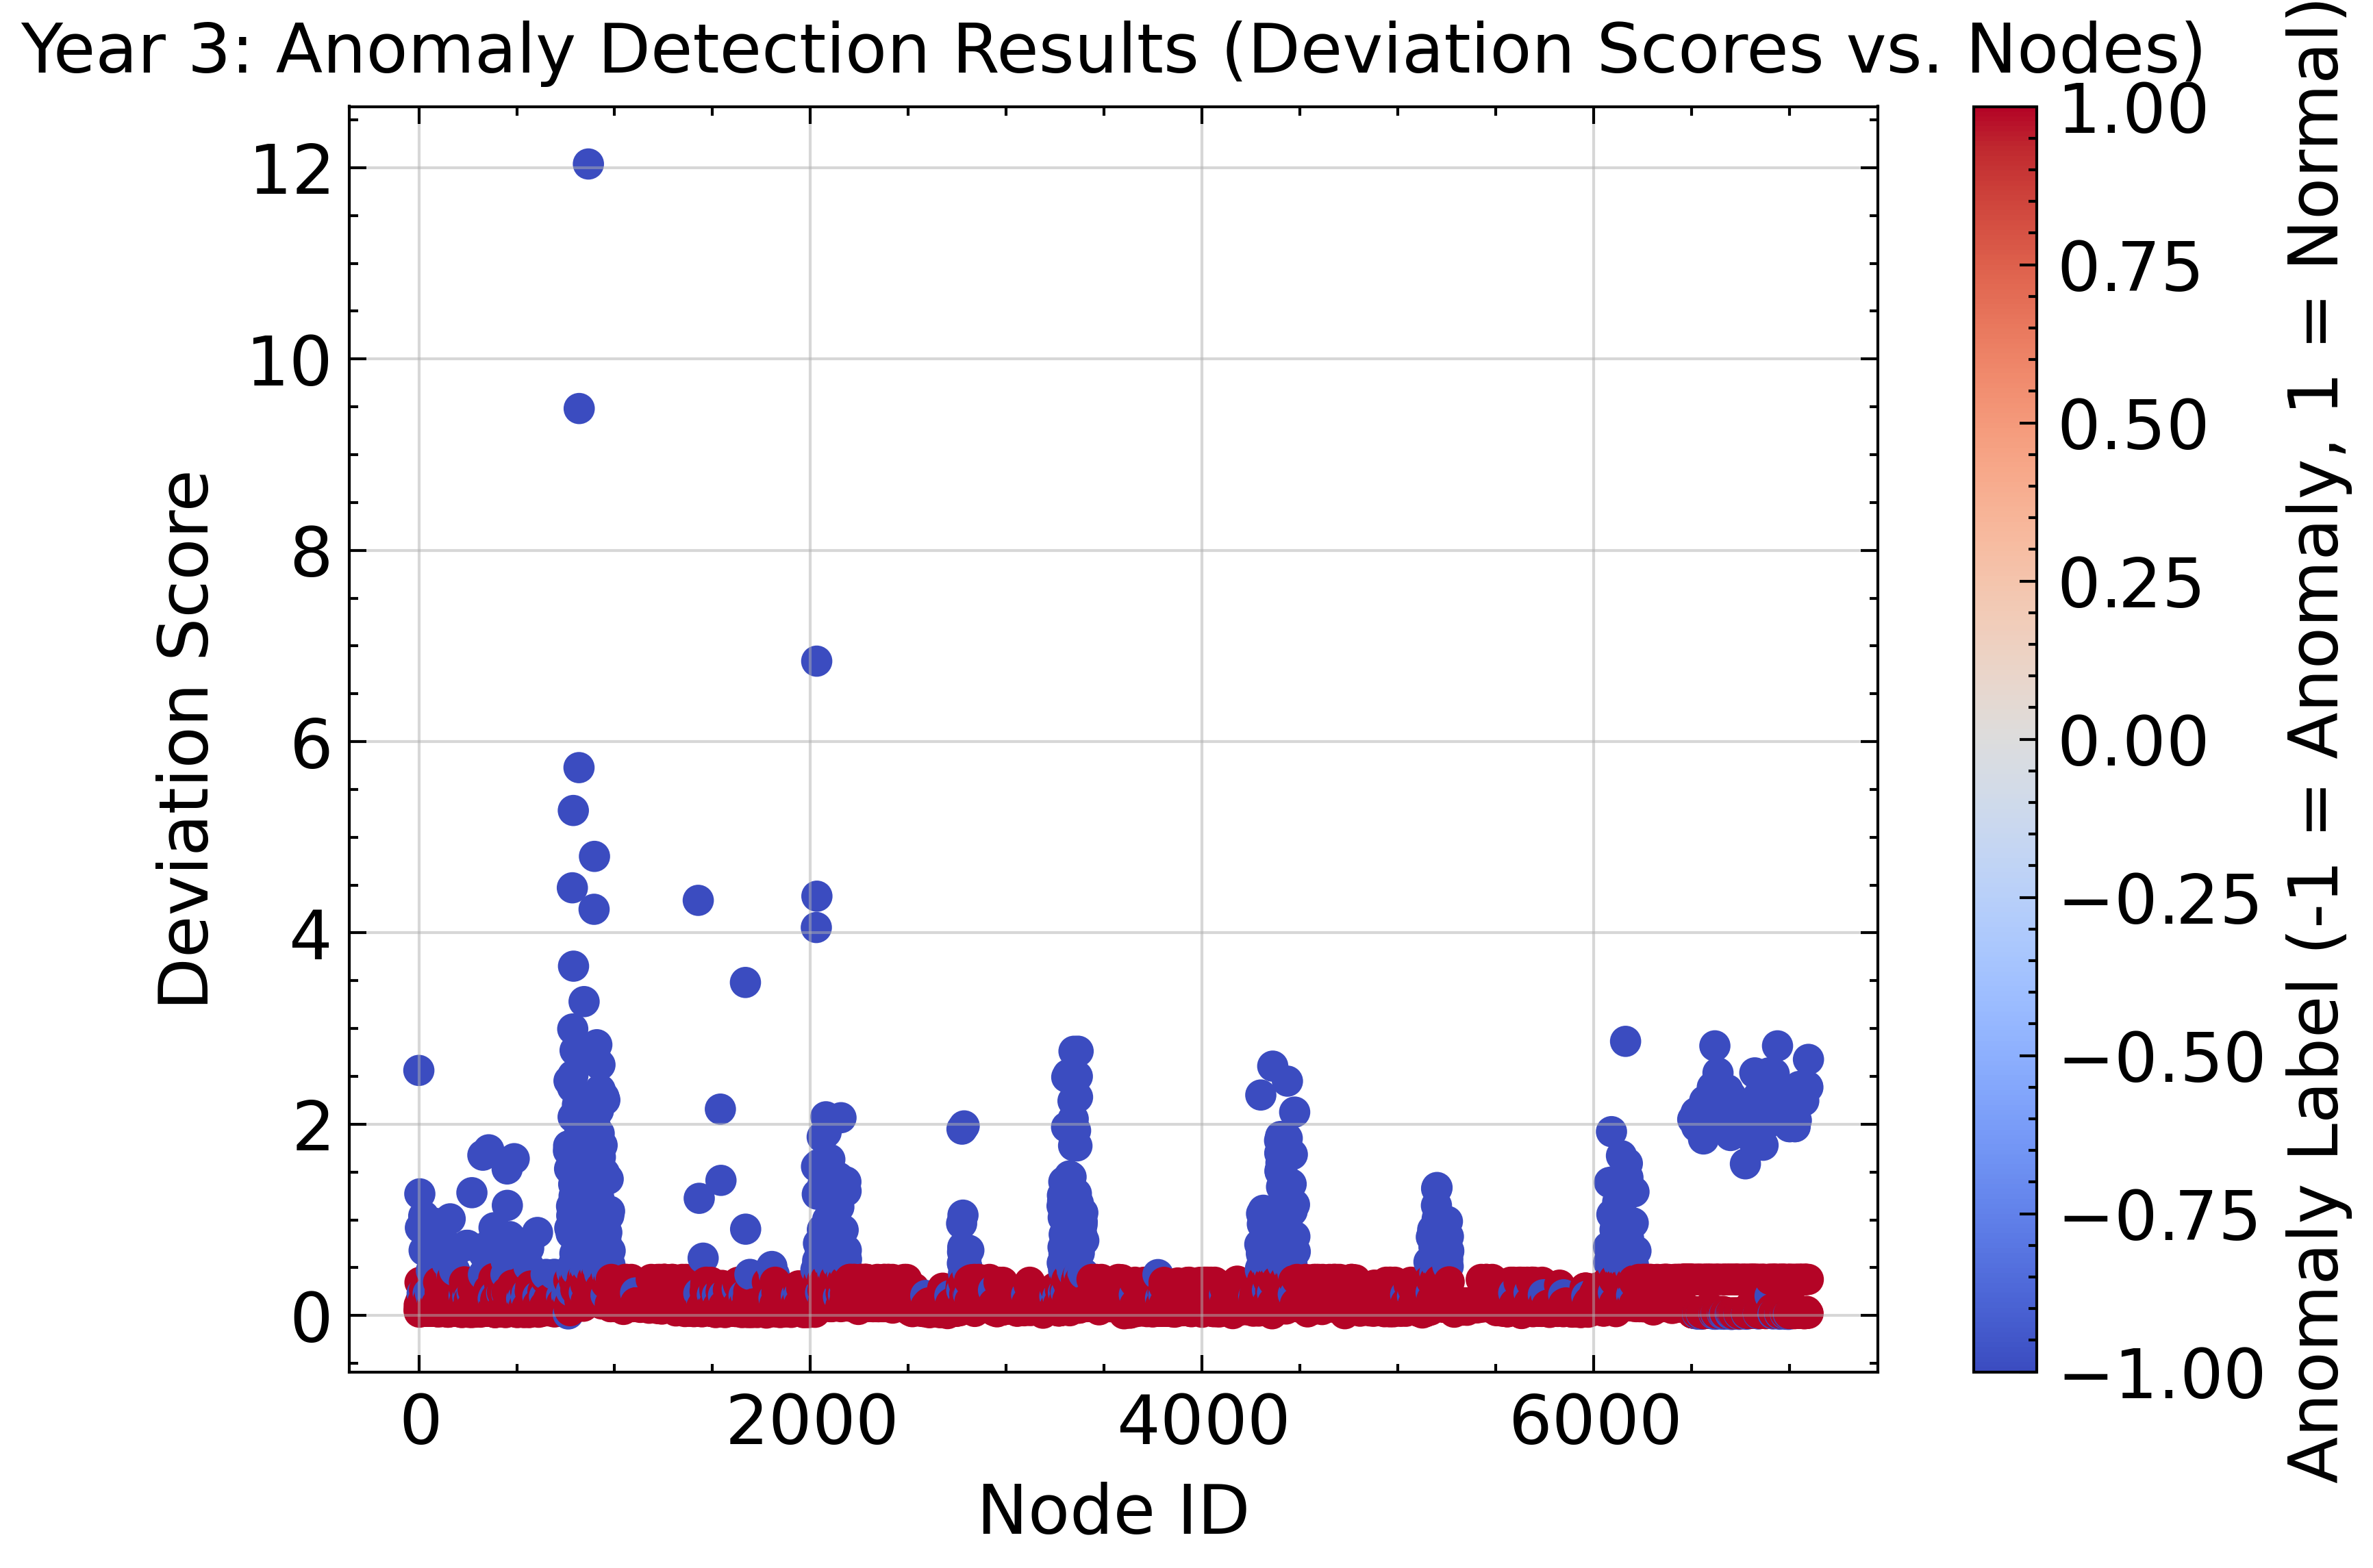

-> Plots generated for Year 3.


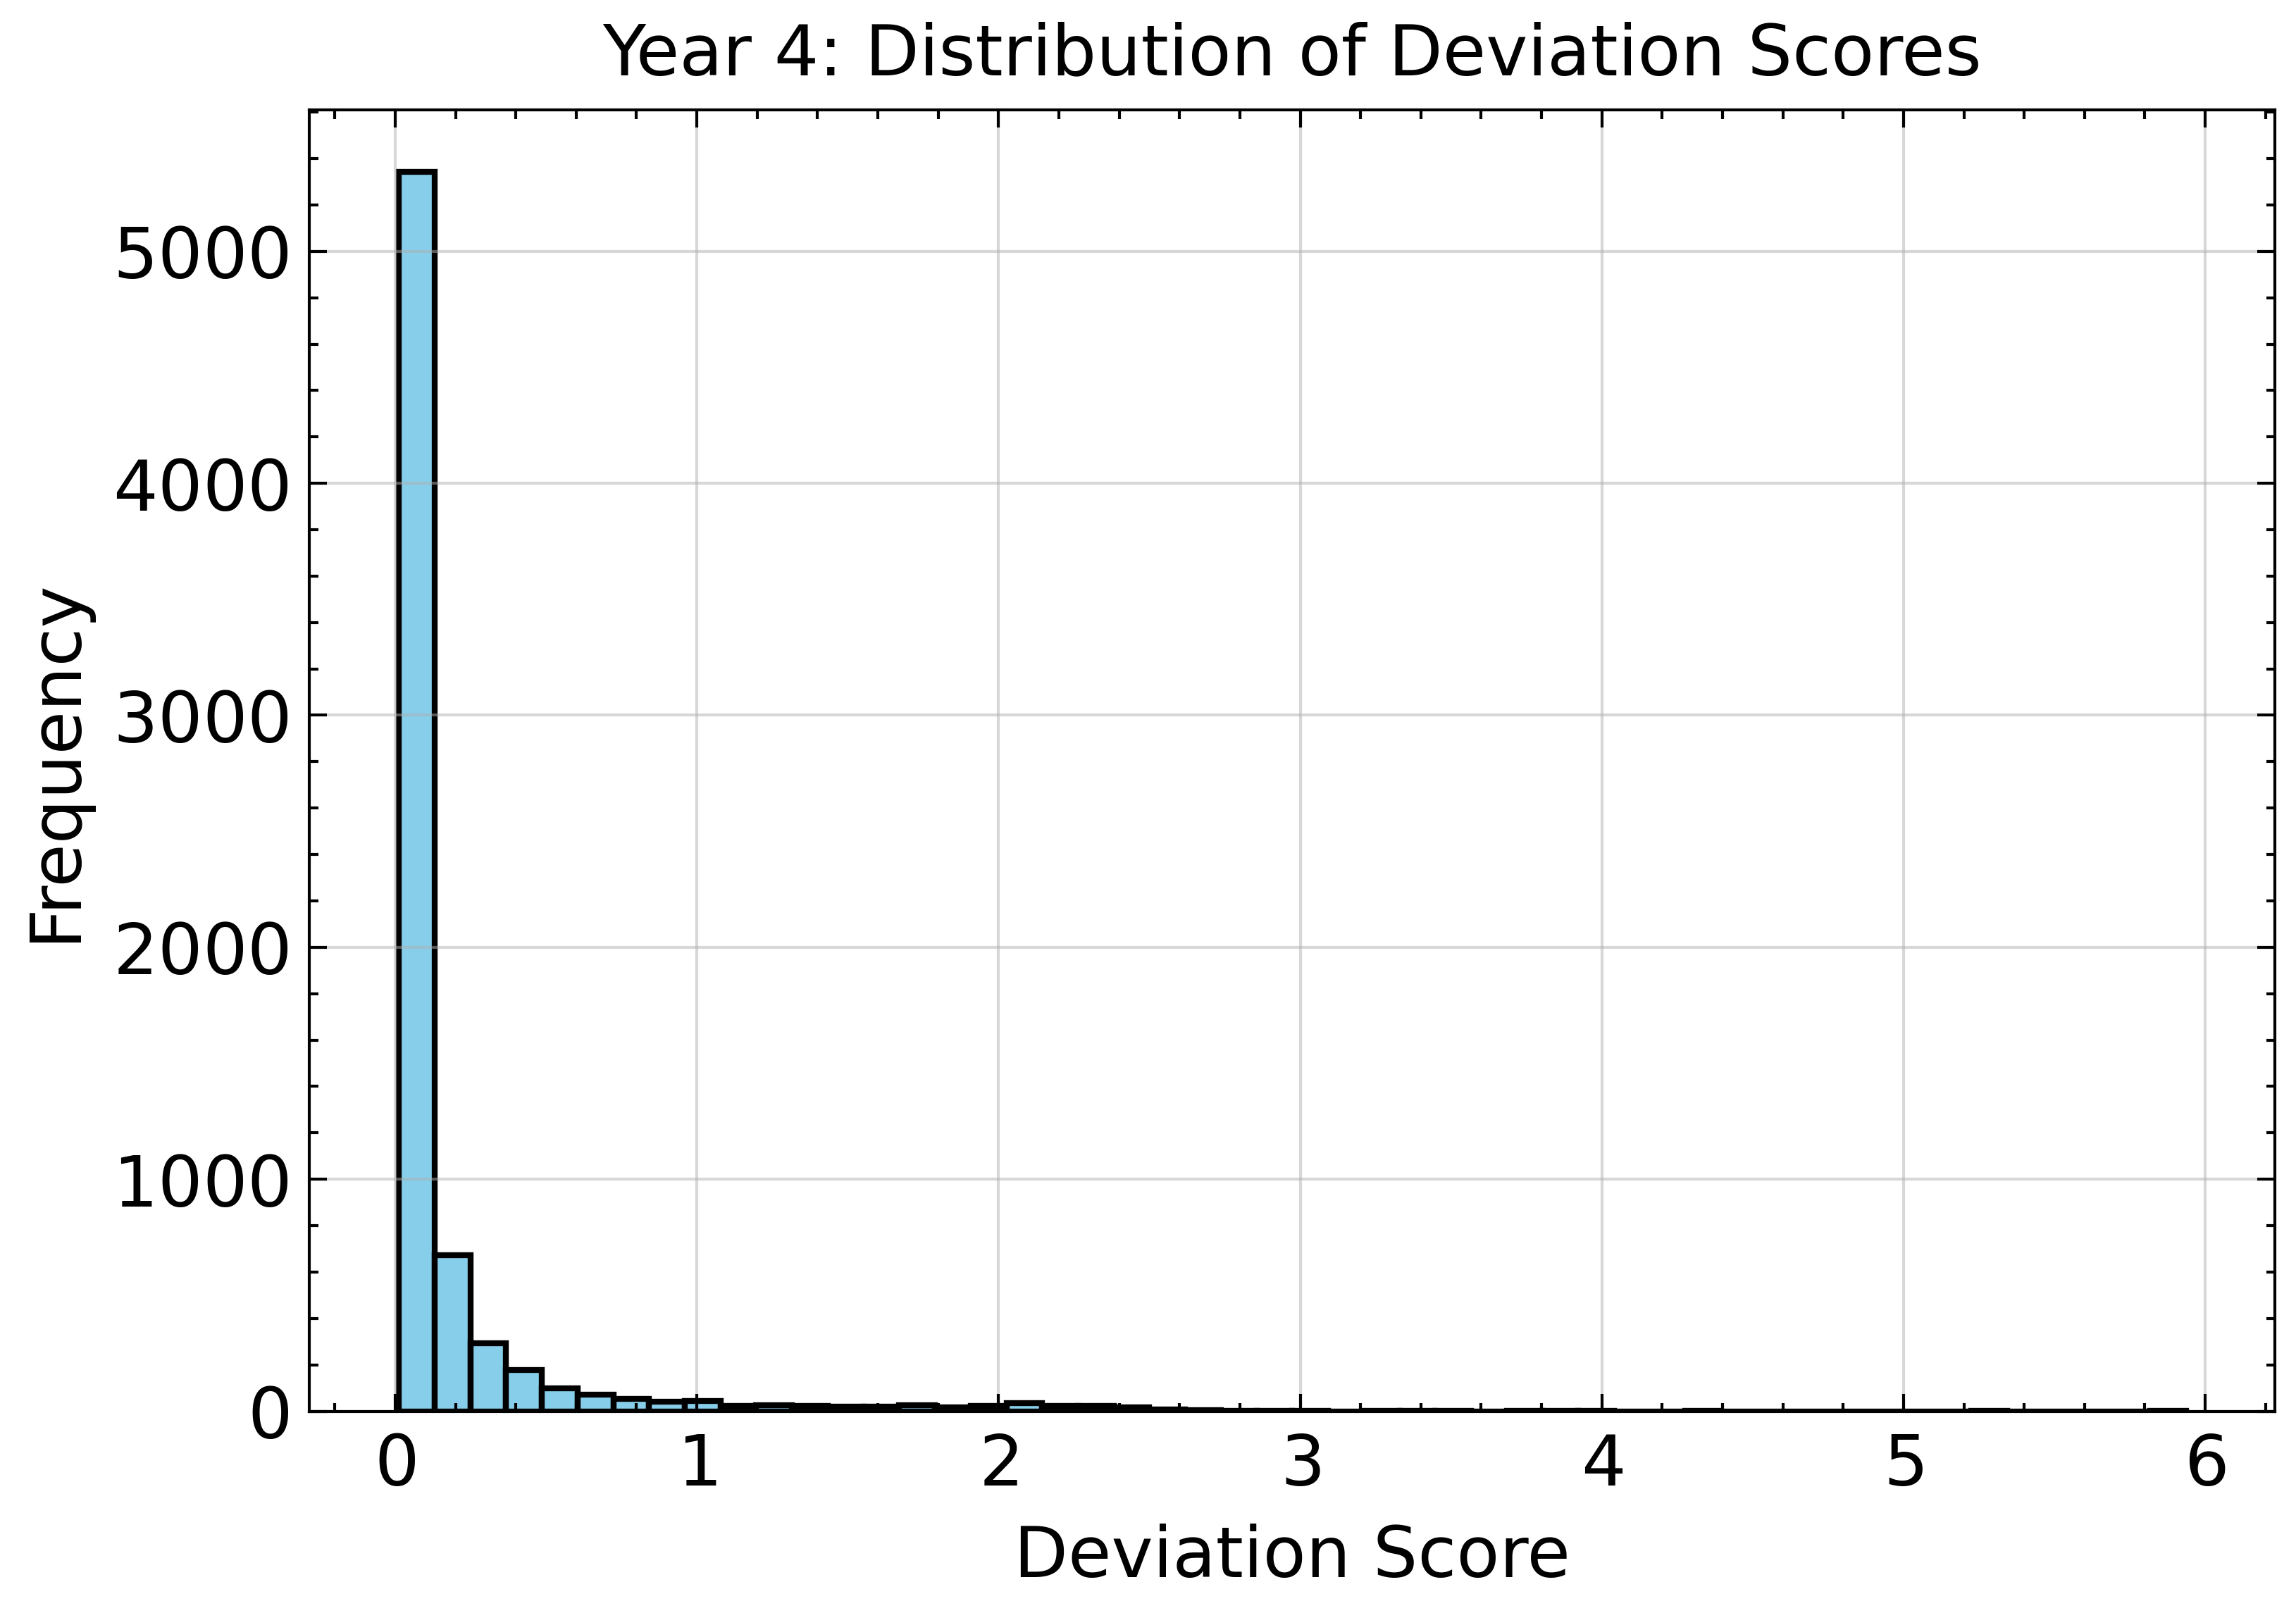

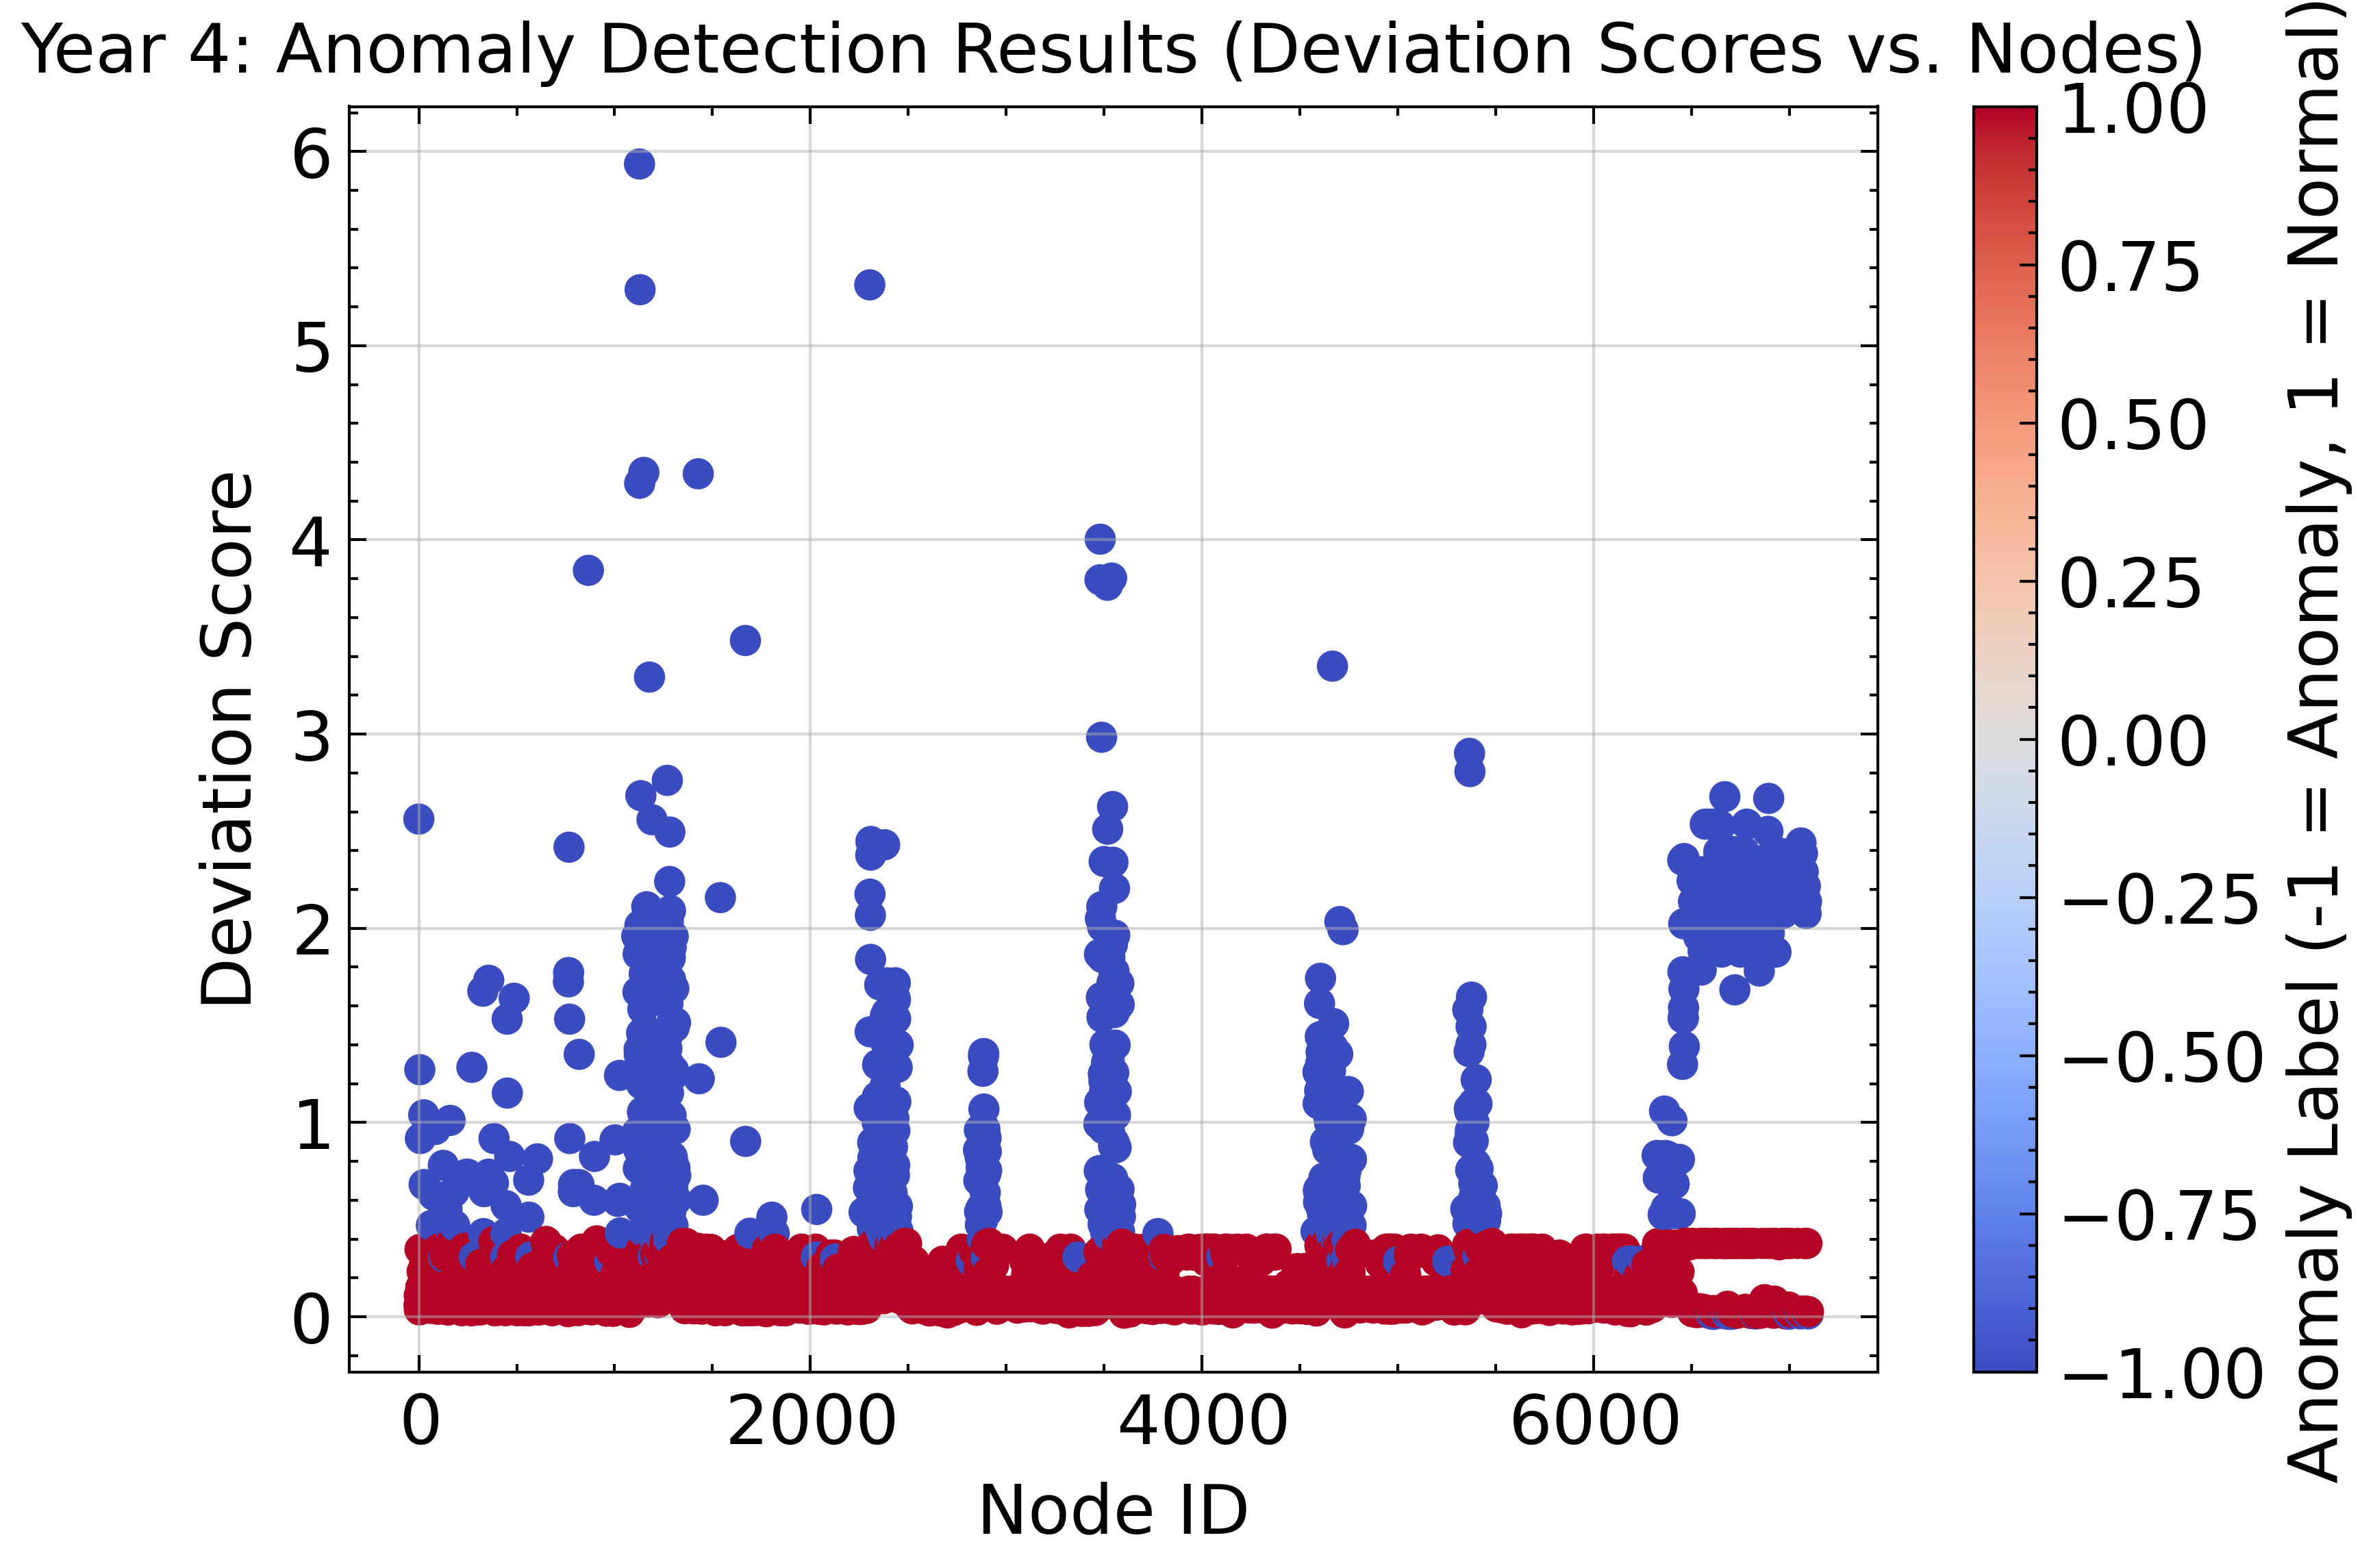

-> Plots generated for Year 4.

Generating final aggregate plots (Mean Deviation Score across all years)...


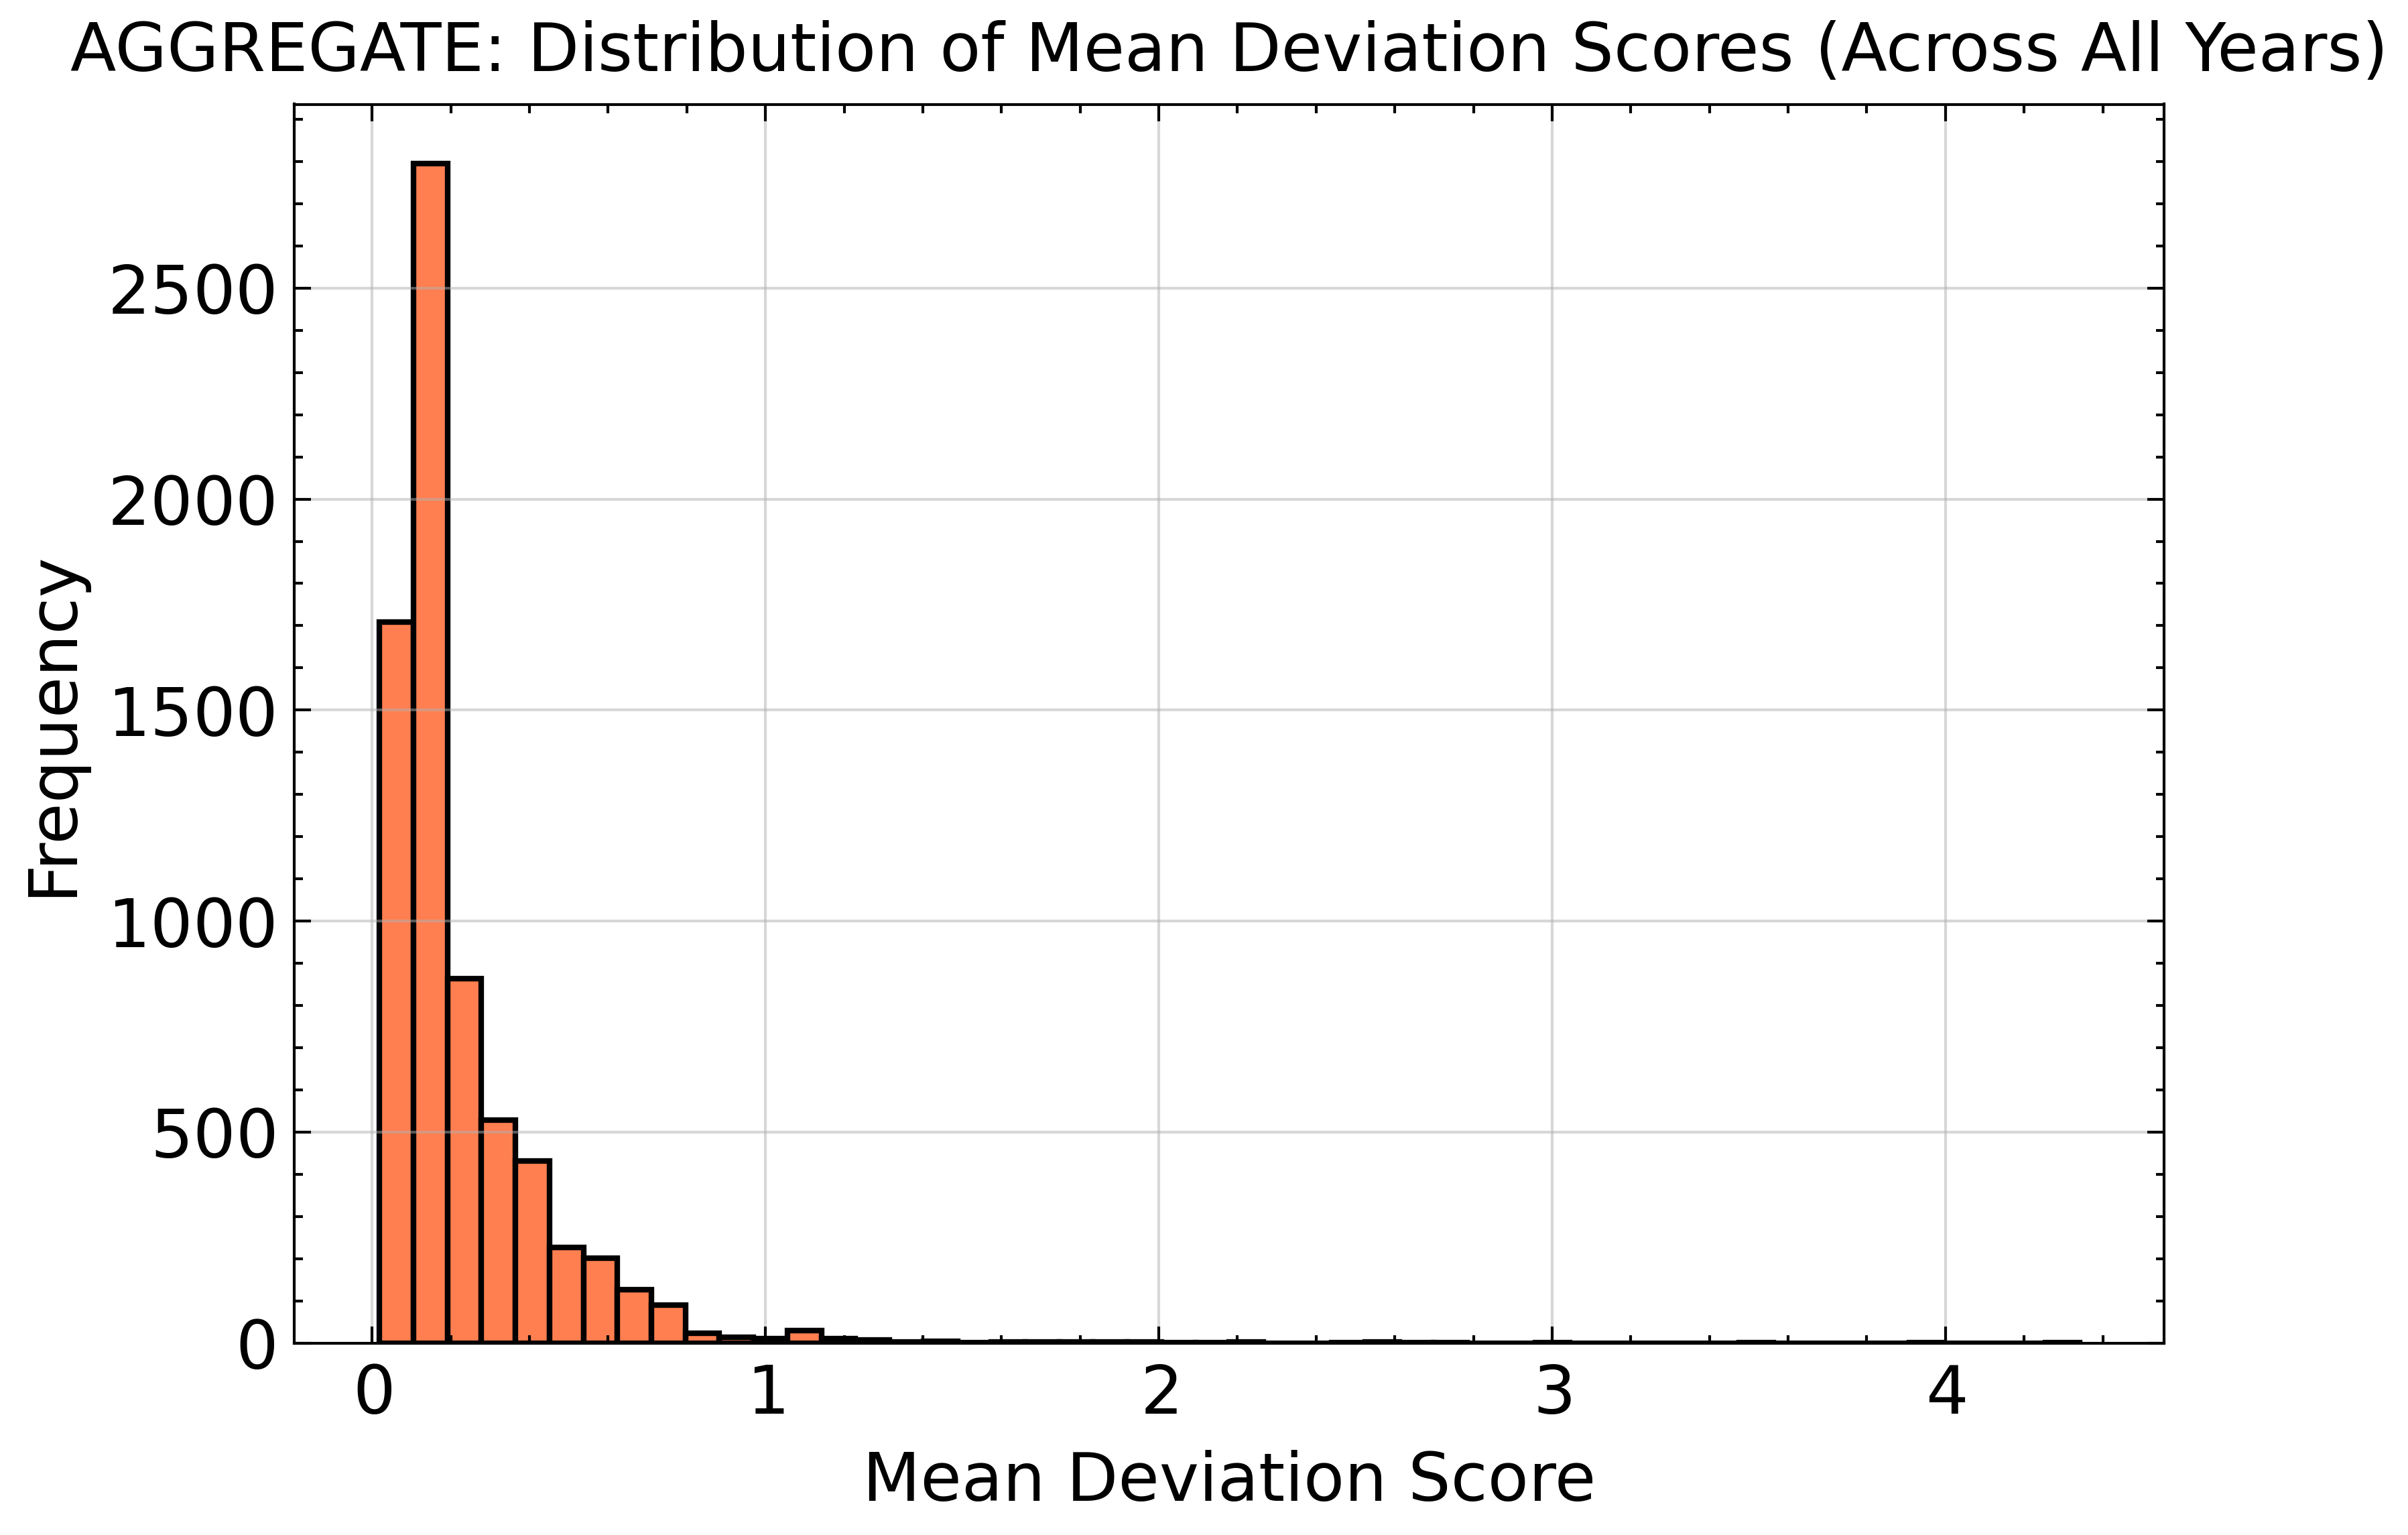

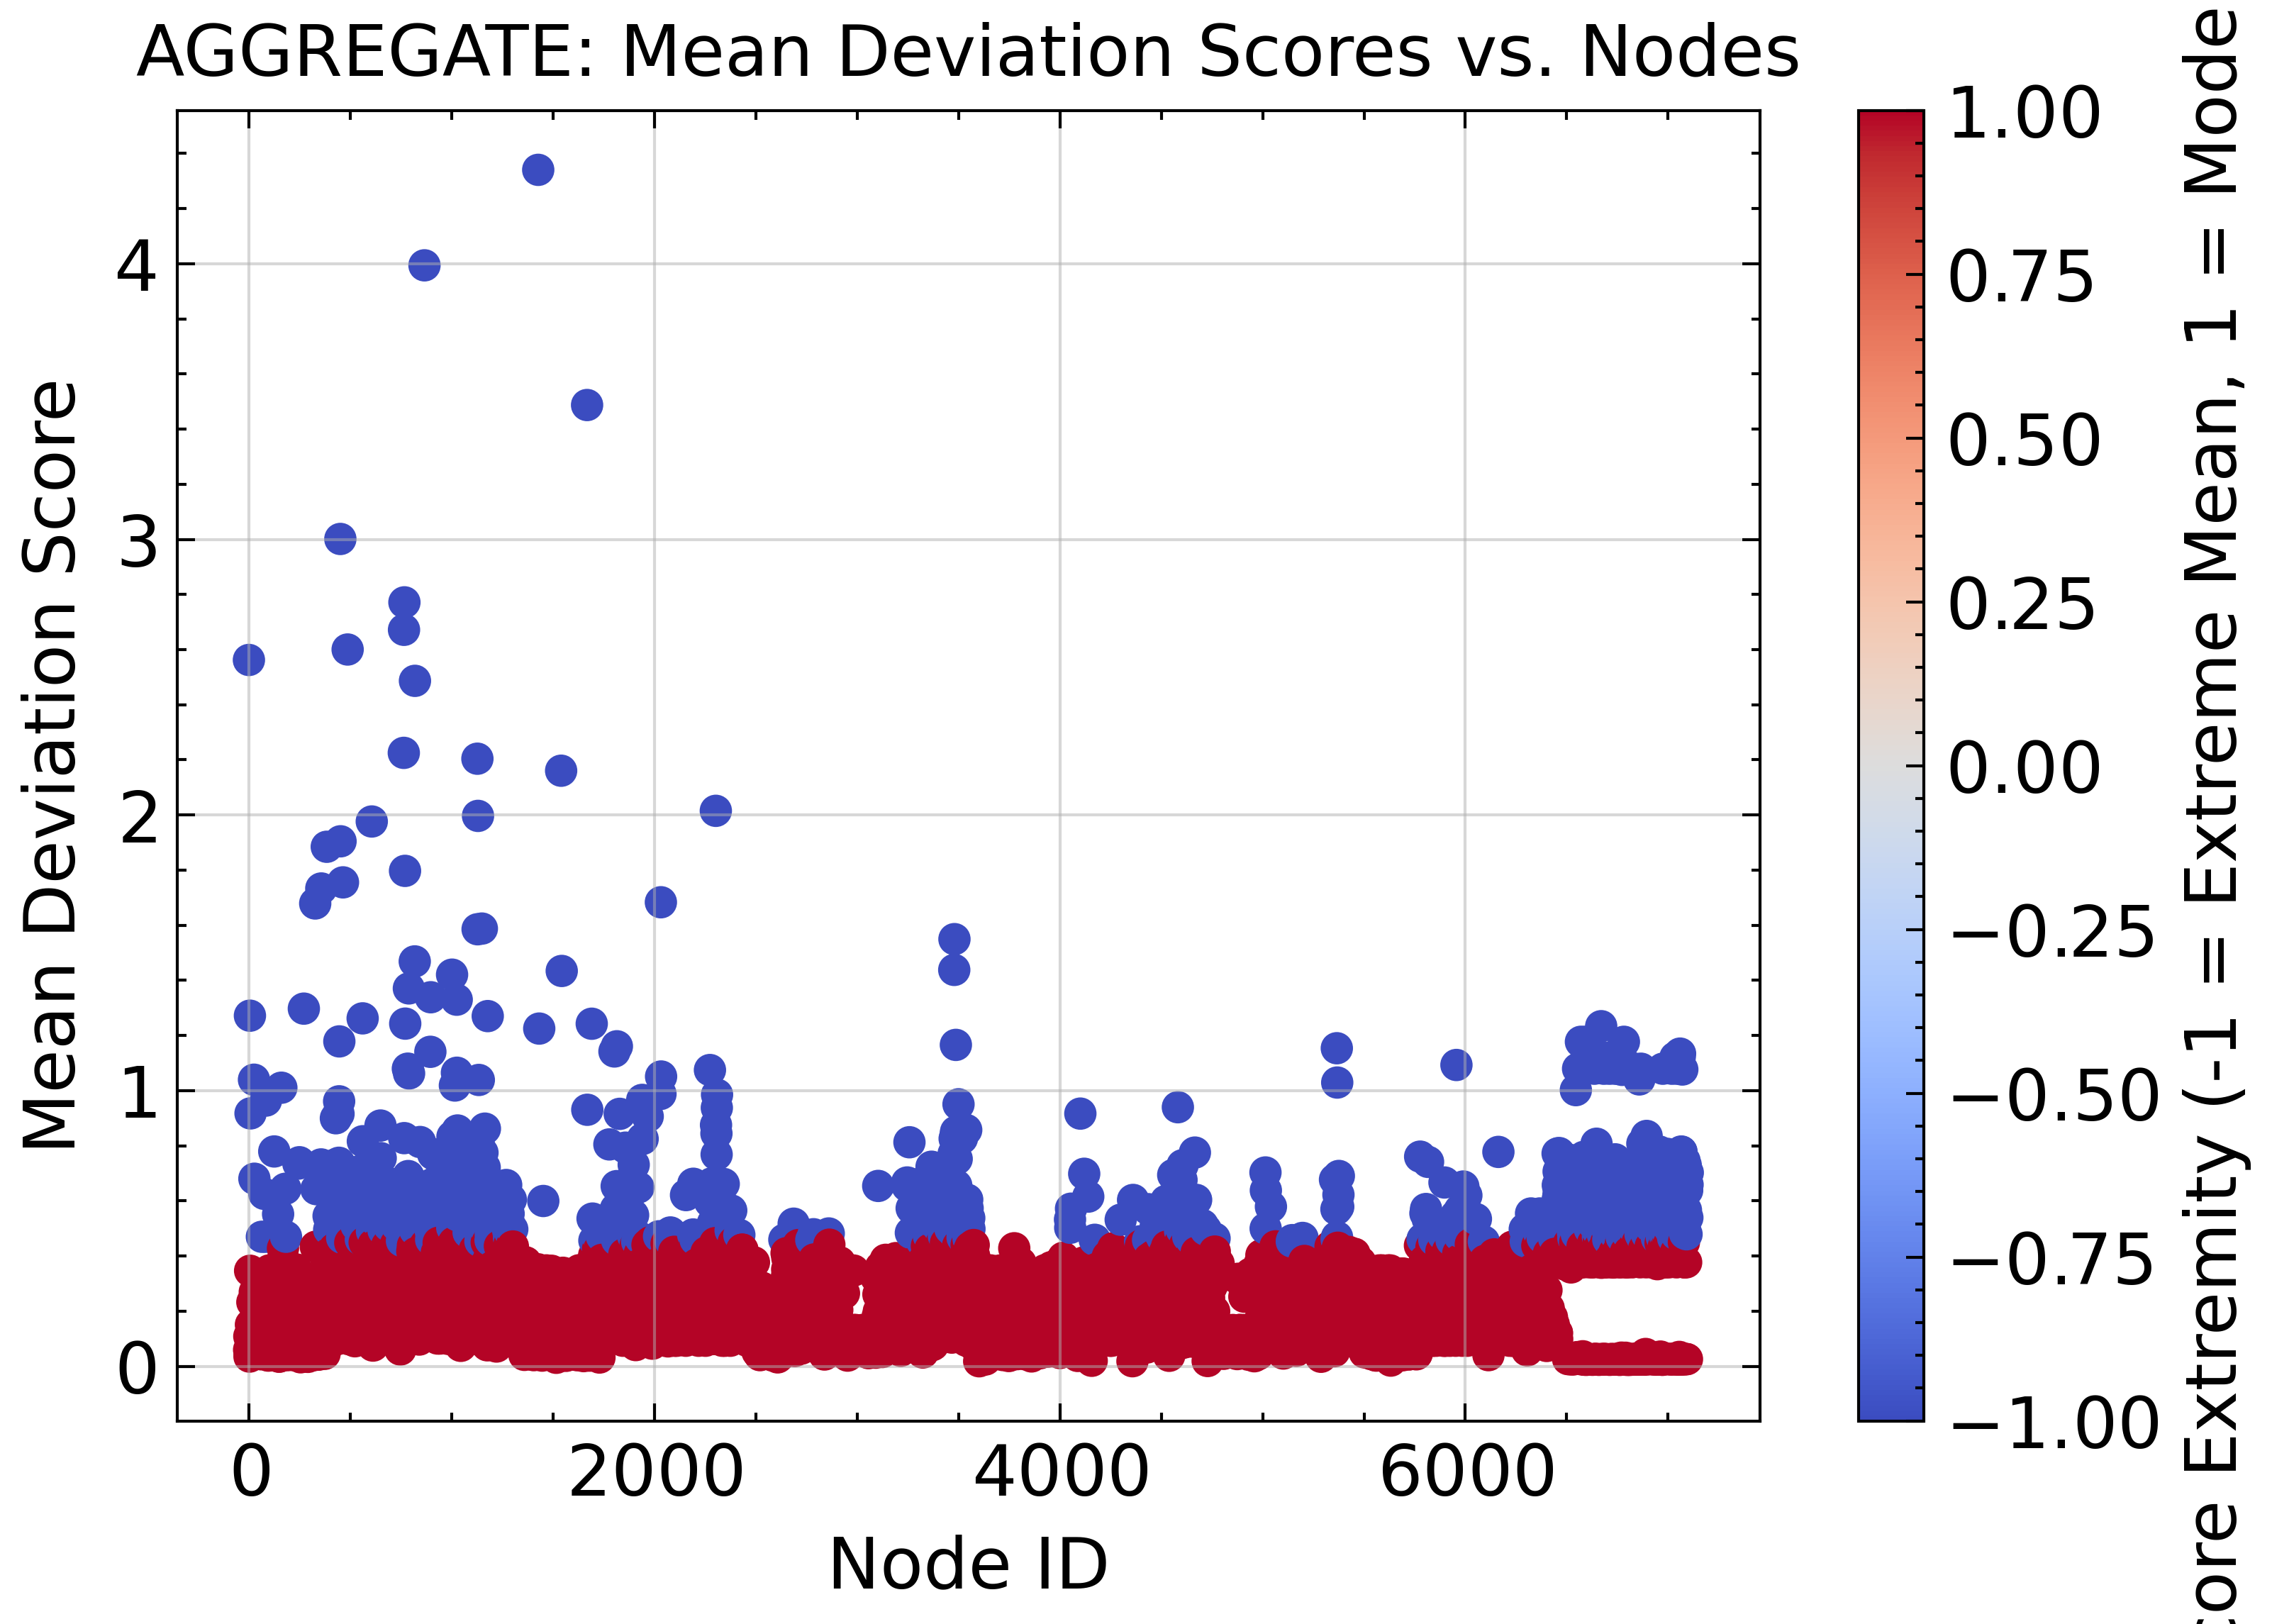


Top 10 Most EXTREME Nodes (by Mean Deviation Score Magnitude):
Node ID | Mean Deviation Score
-----------------------------------
   1427 |      4.340368
    866 |      3.993978
   1668 |      3.487214
    451 |      3.001365
    767 |      2.771424
    765 |      2.671763
    487 |      2.600348
      0 |      2.562423
    819 |      2.486671
    764 |      2.225417
STEP 8 COMPLETED! All per-year and aggregate plots generated.


In [ ]:
print("="*50)
print("STEP 8: Anomaly Detection Evaluation (Per-Year and Aggregate Visualization)")
print("="*50)

try:
    # Load the per-year report generated in the previous step
    df_report = pd.read_csv(report_csv_path)
except FileNotFoundError:
    print(f"Error: Could not find report file at {report_csv_path}")
    print("Please ensure STEP 6 (Per-Year Reporting) ran successfully.")
    exit()

# Identify relevant columns
score_columns = [col for col in df_report.columns if '(Deviation Score)' in col]
label_columns = [col for col in df_report.columns if '(Is Anomaly)' in col]
num_test_samples = len(score_columns)

if num_test_samples == 0:
    print("Error: No 'Deviation Score' columns found in the CSV. Visualization aborted.")
    exit()

# ======================================================================
# 1. PER-YEAR PLOTTING
# ======================================================================

print(f"\nGenerating plots for {num_test_samples} time windows (Years 0 to {num_test_samples - 1})...")

for i in range(num_test_samples):
    year_score_col = score_columns[i]
    year_label_col = label_columns[i]

    deviation_scores = df_report[year_score_col].values
    # Convert binary label (0, 1) to standard anomaly label (1, -1) for visualization
    # Where 1 (anomaly) -> -1, and 0 (normal) -> 1
    anomaly_labels = np.where(df_report[year_label_col].values == 1, -1, 1)

    # --- Plot 1: Histogram of Deviation Scores for the Year ---
    plt.figure(figsize=(6, 4))
    plt.hist(deviation_scores, bins=50, color='skyblue', edgecolor='black')
    plt.title(f"Year {i}: Distribution of Deviation Scores")
    plt.xlabel("Deviation Score")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.5)
    plt.show()

    # --- Plot 2: Scatter Plot of Deviation Scores vs. Nodes for the Year ---
    plt.figure(figsize=(6, 4))
    plt.scatter(
        df_report['Node ID'].values,
        deviation_scores,
        c=anomaly_labels,
        cmap='coolwarm',
        s=20
    )
    plt.title(f"Year {i}: Anomaly Detection Results (Deviation Scores vs. Nodes)")
    plt.xlabel("Node ID")
    plt.ylabel("Deviation Score")
    plt.colorbar(label='Anomaly Label (-1 = Anomaly, 1 = Normal)')
    plt.grid(True, alpha=0.5)
    plt.show()

    print(f"-> Plots generated for Year {i}.")


# ======================================================================
# 2. FINAL AGGREGATE PLOTTING (Using Mean Deviation Score)
# ======================================================================

print("\nGenerating final aggregate plots (Mean Deviation Score across all years)...")

# Use the pre-calculated 'Mean Deviation Score' from the DataFrame
aggregate_scores = df_report['Mean Deviation Score'].values

# Calculate a simple aggregate "label" for visualization purposes:
# 1 if mean score is positive, -1 if mean score is negative (e.g., strong positive/negative average deviation)
# Alternatively, we could use 'Anomaly Status Churn' for color, but absolute score magnitude is usually better for 'total' severity.
# Let's use the magnitude, classifying nodes with a high absolute mean score as "extreme mean deviation" (-1).
# We'll set a high threshold (e.g., 2 standard deviations of the mean scores) for visual emphasis.
mean_score_threshold = np.std(aggregate_scores) * 2
aggregate_labels = np.where(np.abs(aggregate_scores) >= mean_score_threshold, -1, 1)


# --- Plot 3: Histogram of Mean Deviation Scores ---
plt.figure(figsize=(6, 4))
plt.hist(aggregate_scores, bins=50, color='coral', edgecolor='black')
plt.title("AGGREGATE: Distribution of Mean Deviation Scores (Across All Years)")
plt.xlabel("Mean Deviation Score")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.5)
plt.show()

# --- Plot 4: Scatter Plot of Mean Deviation Scores vs. Nodes ---
plt.figure(figsize=(6, 4))
plt.scatter(
    df_report['Node ID'].values,
    aggregate_scores,
    c=aggregate_labels,
    cmap='coolwarm',
    s=20
)
plt.title("AGGREGATE: Mean Deviation Scores vs. Nodes")
plt.xlabel("Node ID")
plt.ylabel("Mean Deviation Score")
plt.colorbar(label='Mean Score Extremity (-1 = Extreme Mean, 1 = Moderate Mean)')
plt.grid(True, alpha=0.5)
plt.show()

# --- Optionally, print top anomalous nodes based on AGGREGATE mean score ---
# Find top 10 most extreme based on Mean Deviation Score magnitude
top_aggregate_indices = np.argsort(np.abs(aggregate_scores))[-10:][::-1]

print("\nTop 10 Most EXTREME Nodes (by Mean Deviation Score Magnitude):")
print("Node ID | Mean Deviation Score")
print("-" * 35)
for idx in top_aggregate_indices:
    print(f"{idx:7d} | {aggregate_scores[idx]:13.6f}")


print("="*50)
print("STEP 8 COMPLETED! All per-year and aggregate plots generated.")
print("="*50)

#analyze result

In [ ]:
gt = results['ground_truth']
pred = results['predict']

# Create index arrays for i, j, k
i_vals, j_vals, k_vals = np.indices(gt.shape[:3])

# Build big dataframe
df = pd.DataFrame({
    "i": i_vals.ravel(),
    "j": j_vals.ravel(),
    "k": k_vals.ravel(),
    "gt_0": gt[..., 0].ravel(),
    "gt_1": gt[..., 1].ravel(),
    "gt_2": gt[..., 2].ravel(),
    "gt_3": gt[..., 3].ravel(),
    "pred_0": pred[..., 0].ravel(),
    "pred_1": pred[..., 1].ravel(),
    "pred_2": pred[..., 2].ravel(),
    "pred_3": pred[..., 3].ravel(),
})

df

,i,j,k,gt_0,gt_1,gt_2,gt_3,pred_0,pred_1,pred_2,pred_3
0,0,0,0,-0.138064,13.276649,-0.116973,-0.111311,-0.276734,3.708876,-0.276325,-0.206208
1,0,0,1,-0.138064,2.004017,-0.116973,-0.111311,-0.196998,2.118405,-0.187113,-0.144179
2,0,0,2,-0.138064,-0.328252,-0.116973,-0.111311,0.009667,-0.284135,0.023383,-0.020615
3,0,0,3,-0.138064,0.837882,-0.116973,-0.111311,-0.142421,0.943815,-0.122428,-0.116620
4,0,0,4,-0.138064,1.420950,-0.116973,-0.111311,-0.188349,1.424258,-0.196047,-0.139159
...,...,...,...,...,...,...,...,...,...,...,...
106465,4,2,7093,-0.138064,1.615305,-0.116973,-0.111311,-0.171306,1.582961,-0.123065,-0.150101
106466,4,2,7094,-0.138064,1.615305,-0.116973,-0.111311,-0.171366,1.582931,-0.123078,-0.150166
106467,4,2,7095,-0.138064,1.615305,-0.116973,-0.111311,-0.171316,1.582957,-0.123067,-0.150111
106468,4,2,7096,-0.138064,1.615305,-0.116973,-0.111311,-0.146633,1.594018,-0.143347,-0.144864


In [ ]:
errors = {}

for idx in range(4):
    gt_col = f"gt_{idx}"
    pred_col = f"pred_{idx}"

    # total absolute error for this feature
    errors[f"feature_{idx}"] = np.abs(df[gt_col] - df[pred_col]).sum()

errors

{'feature_0': np.float64(27992.69748460385),
 'feature_1': np.float64(20885.449048683047),
 'feature_2': np.float64(23954.233693935792),
 'feature_3': np.float64(22892.054740802385)}

In [ ]:
pred_cols = ['pred_0','pred_1','pred_2','pred_3']
gt_cols   = ['gt_0','gt_1','gt_2','gt_3']

diff = df[pred_cols].to_numpy() - df[gt_cols].to_numpy()
abs_errors = pd.Series(np.abs(diff).sum(axis=0), index=pred_cols)
abs_errors



,0
pred_0,27992.697485
pred_1,20885.449049
pred_2,23954.233694
pred_3,22892.054741


In [ ]:
diff = df[pred_cols].to_numpy() - df[gt_cols].to_numpy()

# mean absolute error
mean_abs_errors = np.abs(diff).mean(axis=0)

# convert to Series for nicer labels
mean_abs_errors = pd.Series(mean_abs_errors, index=pred_cols)
mean_abs_errors

,0
pred_0,0.262916
pred_1,0.196163
pred_2,0.224986
pred_3,0.215009


#csv score for all

In [ ]:
# Assuming 'conf' is an object containing configuration details (like conf.log_dir, etc.)
# and 'deviation_scores' and 'anomaly_labels' are 1D NumPy arrays
# indexed by node ID (0 to N-1).

def create_anomaly_csv_report(conf: Any, deviation_scores: np.ndarray, anomaly_labels: np.ndarray):
    """
    Generates a comprehensive CSV report containing the anomaly score and label
    for every node in the network.

    Args:
        conf: Configuration object with path details (log_dir, dynamics, model).
        deviation_scores: NumPy array of deviation scores for all nodes.
        anomaly_labels: NumPy array of binary labels (1 for anomaly, 0 otherwise)
                        for all nodes. Assumed to have the same length as deviation_scores.
    """

    # 1. Define the report path
    # Ensure the directory structure exists
    log_dir = f'{conf.log_dir}/{conf.dynamics}/{conf.model}'
    os.makedirs(log_dir, exist_ok=True)
    report_path = os.path.join(log_dir, 'all_node_anomalies.csv')

    # Ensure arrays are the same length
    if len(deviation_scores) != len(anomaly_labels):
        print("Error: Deviation scores and anomaly labels must have the same length.")
        return

    # 2. Write the CSV content
    try:
        with open(report_path, 'w', newline='') as csvfile:
            # Use the standard library's csv writer for better handling
            csv_writer = csv.writer(csvfile)

            # Write the header row
            csv_writer.writerow(['Node ID', 'Deviation Score', 'Is Anomaly'])

            num_nodes = len(deviation_scores)

            # 3. Iterate over all nodes and write their data
            for node_id in range(num_nodes):
                score = deviation_scores[node_id]
                label = int(anomaly_labels[node_id]) # Ensure label is 0 or 1 integer

                # Write the row: [Node ID, Deviation Score, Is Anomaly]
                csv_writer.writerow([node_id, f"{score:.6f}", label])

        print(f"Comprehensive anomaly CSV report saved to: {report_path}")
        print(f"Total {num_nodes} nodes written.")

    except Exception as e:
        print(f"An error occurred while writing the CSV report: {e}")

In [ ]:
create_anomaly_csv_report(conf, deviation_scores, anomaly_labels)

Comprehensive anomaly CSV report saved to: logs/citation/l3_h3/CitationNetwork/DiskNet/all_node_anomalies.csv
Total 7098 nodes written.
